# Machine Learning Analysis of Microfinance and Household Resilience in the Philippines
### QUIWA, QUIEL ANDREW I.
### AI 221 - FINAL PROJECT

**Datasets Used:** Philippine Microfinance Survey 2024 (PMS 2024), PSA CPI, NOAA IBTrACS

### 0. Setup

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Loading the Dataset
pms_raw = pd.read_excel('PMS2024_raw.xlsx', header=0)

print ("Shape:", pms_raw.shape)

Shape: (1900, 1210)


In [3]:
print("\nFirst 5 rows (selected columns):")
pms_raw[['Q_2', 'a5', 'a9', 'Q_107', 'e3_1', 'e6', 'e7', 'e15', 'e16']].head()


First 5 rows (selected columns):


,Q_2,a5,a9,Q_107,e3_1,e6,e7,e15,e16
0,REGION XII (SOCCSKSARGEN),Male,Tapos ng high school (Completed high school),D,NOT AVAILED,-1,-1,-1,-1
1,NATIONAL CAPITAL REGION,Female,Tapos ng high school (Completed high school),Broad C,AVAILED,Isang beses kada 4-6 buwan (Once every 4 to 6 ...,Medyo mas kaya naming tugunan ang aming mga pa...,Medyo lumakas ang kakayahan ng aming sambahaya...,Walang nagbago sa kalidad ng aming pamumuhay (...
2,NATIONAL CAPITAL REGION,Male,Tapos ng kolehiyo (Completed college),D,NOT AVAILED,-1,-1,-1,-1
3,NATIONAL CAPITAL REGION,Female,Hindi tapos ng kolehiyo (Some college),D,AVAILED,Isang beses kada 3 buwan (Once every 3 months),Talagang mas kaya naming tugunan ang aming mga...,Medyo lumakas ang kakayahan ng aming sambahaya...,Medyo gumanda ang kalidad ng aming pamumuhay (...
4,REGION XII (SOCCSKSARGEN),Female,Tapos ng kolehiyo (Completed college),D,NOT AVAILED,-1,-1,-1,-1


### Mapping the columns

Three files were used to extract the relevant columns for this analysis:

1. 'PMS2024_instrument.docx' - This file contains the original survey instrument, which lists all the questions and their corresponding variable names (e.g., 'Q_2', 'a5', etc.).
    
2. 'PMS2024_codebook.xlsx' - This file provides a codebook that maps the original variable names to more descriptive labels, along with the possible values and their meanings.
    
3. 'PMS2024_raw.xlsx' - This file contains the raw dataset with all the original variable names as columns. We will use this file to extract the relevant columns based on the mappings provided in the first two files.

A COLUMN_MAP dictionary will be created to map the original column names from the dataset to new, more descriptive names that will be used in the analysis.

#### Demographics and Household
   - Q_2      = region (full text, e.g. "NATIONAL CAPITAL REGION")
   - a5       = sex of respondent ("Male" / "Female")
   - a9       = education attainment (11 options, Tagalog/English)
   - Q_107    = SES/MORES class ("A","B","C","Broad C","D")
   - Q_106    = civil/marital status
   - b1_1     = total household size (integer)
   - I_1_b5   = household head currently employed (Yes/No)
   - I_1_b6   = household head income range (text bracket)
   - Q_109    = number of working household members (count, 0–9)
   - I_1_b8   = household head employment type (self-employed/wage/govt)
   - I_1_b14  = household head receives remittances (Yes/No)
   - g1       = household owns land (Yes/No)
   - Q_116    = house wall construction quality (6-level ordinal, proxy for housing wealth)

 #### MFI Usage
   - e3_1     = MFI availed flag (AVAILED/NOT AVAILED)
   - e6       = frequency of MFI use (6 options)
   - e9       = MFI reliance level (4 options)
   - e11      = MFI vs other financial strategies
   - e12      = recovery status after last shock (5 options)
   - e13      = whether MFI helped avoid asset sale/informal loans
   - e17      = what MFI did during a shock (emergency loan/flexible repayment/financial advice/nothing)
   - e18      = had a business before MFI (context variable)
   - e20      = overall MFI satisfaction (5 options)

#### Financial Literacy
   - f14      = financial literacy level: formal program/informal session/self-directed/none (PRIMARY FL variable)
   - f4       = how much financial education influenced MFI decision
   - f5       = has a formal bank account (Yes/No)

#### Shocks (up to 3 shock events recorded per respondent)
   - T_Q_26_1    = shock type 1 (typhoon, flood, illness, etc.)
   - T_d1_1_2_1  = shock type 2
   - T_d1_1_3_1  = shock type 3
   - d3_1/2/3    = income impact direction per shock (Decreased/Same/Increased)

#### Targets (from PMS Figures 7–9, 5-point Likert scale text)
   - e7       = consumption stability
   - e15      = shock resilience
   - e16      = quality of life

In [4]:
# The keys used below are the original column names from the dataset, and the values are the new, more descriptive names that we will use in our analysis.

COLUMN_MAP = {
    # Demographics & household
    'Q_2'        : 'region',
    'a5'         : 'sex_head',
    'a9'         : 'educ_head',
    'Q_107'      : 'ses_class',
    'Q_106'      : 'civil_status',
    'b1_1'       : 'hh_size',
    'I_1_b5'     : 'hh_head_employed',
    'I_1_b6'     : 'hh_head_income_range',
    'Q_109'      : 'num_working_members',
    'I_1_b8'     : 'hh_head_employment_type',
    'I_1_b14'    : 'hh_head_remittance',
    'g1'         : 'owns_land',
    'Q_116'      : 'house_quality',

    # MFI usage (filter + features)
    'e3_1'       : 'mfi_availed',
    'e6'         : 'mfi_use_frequency',
    'e9'         : 'mfi_reliance',
    'e11'        : 'mfi_vs_other',
    'e12'        : 'recovery_status',
    'e13'        : 'mfi_avoided_distress',
    'e17'        : 'mfi_shock_support',
    'e18'        : 'mfi_business_context',
    'e20'        : 'mfi_satisfaction',

    # Financial literacy
    'f14'        : 'fin_lit_level',
    'f4'         : 'fin_ed_influence',
    'f5'         : 'has_bank_account',

    # Shocks — types and income impact
    'T_Q_26_1'   : 'shock_type_1',
    'T_d1_1_2_1' : 'shock_type_2',
    'T_d1_1_3_1' : 'shock_type_3',
    'd3_1'       : 'shock_income_impact_1',
    'd3_2'       : 'shock_income_impact_2',
    'd3_3'       : 'shock_income_impact_3',

    # Targets
    'e7'         : 'consumption_stability',
    'e15'        : 'shock_resilience',
    'e16'        : 'quality_of_life',
}

# Create a new DataFrame with the selected columns and rename them according to COLUMN_MAP
pms = pms_raw[list(COLUMN_MAP.keys())].rename(columns=COLUMN_MAP).copy()

# Filter to MFI users only (n should be ~734)
pms_mfi = pms[pms['mfi_availed'] == 'AVAILED'].copy()
# drop the 'mfi_availed' column since it's now redundant (all rows in pms_mfi have the same value)
pms_mfi = pms_mfi.drop(columns=['mfi_availed'])

# Display basic info about the cleaned dataset and the MFI user subset
print(f"Full sample:  {len(pms):,}")
print(f"MFI users:    {len(pms_mfi):,}") 
print(f"\nColumns: {list(pms_mfi.columns)}")
pms_mfi.head(3)

Full sample:  1,900
MFI users:    734

Columns: ['region', 'sex_head', 'educ_head', 'ses_class', 'civil_status', 'hh_size', 'hh_head_employed', 'hh_head_income_range', 'num_working_members', 'hh_head_employment_type', 'hh_head_remittance', 'owns_land', 'house_quality', 'mfi_use_frequency', 'mfi_reliance', 'mfi_vs_other', 'recovery_status', 'mfi_avoided_distress', 'mfi_shock_support', 'mfi_business_context', 'mfi_satisfaction', 'fin_lit_level', 'fin_ed_influence', 'has_bank_account', 'shock_type_1', 'shock_type_2', 'shock_type_3', 'shock_income_impact_1', 'shock_income_impact_2', 'shock_income_impact_3', 'consumption_stability', 'shock_resilience', 'quality_of_life']


,region,sex_head,educ_head,ses_class,civil_status,hh_size,hh_head_employed,hh_head_income_range,num_working_members,hh_head_employment_type,...,has_bank_account,shock_type_1,shock_type_2,shock_type_3,shock_income_impact_1,shock_income_impact_2,shock_income_impact_3,consumption_stability,shock_resilience,quality_of_life
1,NATIONAL CAPITAL REGION,Female,Tapos ng high school (Completed high school),Broad C,Married/Living in,3,No,-1,2,Employer in own farm or business,...,Yes,"Nanakawan ng pera, ari-arian, o ani. (Theft of...",Biglaang pagtataas na presyo ng bilihin (High...,Pandemya (Pandemic),Bumaba (Decreased),Pareho lang (Stayed the same),Bumaba (Decreased),Medyo mas kaya naming tugunan ang aming mga pa...,Medyo lumakas ang kakayahan ng aming sambahaya...,Walang nagbago sa kalidad ng aming pamumuhay (...
3,NATIONAL CAPITAL REGION,Female,Hindi tapos ng kolehiyo (Some college),D,Married/Living in,4,Yes,"3,001 to 6,000",2,Self-employed with no paid employee,...,No,Kawalan ng trabaho ng mga sumusuweldong miyemb...,Paghina ng kita sa negosyo na hindi dahil sa p...,Paghinto ng pagtanggap ng regular na tulong ga...,Bumaba (Decreased),Pareho lang (Stayed the same),Pareho lang (Stayed the same),Talagang mas kaya naming tugunan ang aming mga...,Medyo lumakas ang kakayahan ng aming sambahaya...,Medyo gumanda ang kalidad ng aming pamumuhay (...
5,REGION XII (SOCCSKSARGEN),Female,Tapos ng high school (Completed high school),D,Married/Living in,2,Yes,"3,001 to 6,000",1,Self-employed with no paid employee,...,No,Malubhang karamdaman (Grave illness),Biglaang pagtataas na presyo ng bilihin (High...,Wala (None),Bumaba (Decreased),Bumaba (Decreased),-1,Talagang mas nahirapan kaming tugunan ang amin...,Medyo humina ang kakayahan ng aming sambahayan...,Medyo gumanda ang kalidad ng aming pamumuhay (...


In [5]:
# Sentinel values are often used in survey data to indicate "not applicable" or "skipped" responses. 
# In this dataset, -1 is used as a sentinel value for different reasons depending on the question. 
# In this cell, we will replace all occurrences of -1 with NaN to properly represent them as missing values in our analysis.

# Notes on -1 values in this dataset:
#   - e-series -1s: sub-questions skipped due to a follow-up filter
#   - shock columns: -1 means the shock slot was unused (respondent
#     reported fewer than 3 shocks)
#   - f8: -1 means they already have a bank account (skipped past
#     the "barriers" question)

# Note that we are only replacing -1 with NaN in the MFI user subset (pms_mfi), not the full dataset (pms). 
# This is because the -1s in the non-MFI users legitimately indicate that those questions were not shown to them, and we want to preserve that information. 
# By filtering to MFI users first, we ensure that we only replace -1 with NaN for respondents who actually had the opportunity to answer those questions.

# Replace string '-1' and integer -1 with NaN
# (raw data stores -1 as string in text columns, int in numeric cols)
pms_mfi = pms_mfi.replace('-1', np.nan).replace(-1, np.nan)

# Quick check
print("Missing values after sentinel replacement:")
missing = pms_mfi.isnull().sum()
missing_pct = (missing / len(pms_mfi) * 100).round(1)
summary = pd.DataFrame({'missing values': missing, '% missing': missing_pct})
print(summary[summary['missing values'] > 0].sort_values('% missing', ascending=False))

Missing values after sentinel replacement:
                         missing values  % missing
hh_head_income_range                185       25.2
hh_head_employed                    167       22.8
hh_head_employment_type             167       22.8
shock_income_impact_3                90       12.3
mfi_reliance                         88       12.0
shock_income_impact_2                25        3.4
shock_income_impact_1                 4        0.5


In [6]:
# In this cell, we will be interpreting the shock type columns which contain text descriptions of the shocks that respondents experienced.
# Text descriptions will be converted into binary indicator flags for different shock categories based on keyword matching.

# Shock categories (from all unique values observed):
#   Climate    : "Bagyo" (Typhoon), "Pagbaha" (Floods)
#   Inflation  : "Biglaang pagtataas na presyo" (High inflation)
#   Pandemic   : "Pandemya"
#   Health     : "Malubhang karamdaman" (Grave illness)
#   Economic   : job loss, business failure, income reduction
#   Other      : death, theft, fire, earthquake, displacement

# We will link these flags to our external CPI and IBTrACS data for further analysis
# They are also useful features for understanding the types of shocks MFI users are experiencing.

# Respondents reported up to 3 shocks, each in a separate column. 
# We will create flags that check for the presence of keywords across all three shock columns simultaneously 
# to account for compound shocks and to ensure we capture any shock type regardless of which slot it was reported in.
shock_cols = ['shock_type_1', 'shock_type_2', 'shock_type_3']

# Define a helper function to check if any of the shock columns contains a given keyword (case-insensitive)
def any_shock_contains(df, keyword):
    """Return True if ANY of the 3 shock columns contains keyword."""
    mask = pd.Series(False, index=df.index)
    for col in shock_cols:
        mask = mask | df[col].fillna('').str.contains(keyword, case=False)
    return mask.astype(int)

# pms_mfi['xxx'] is a column of 0/1 flags indicating whether any of the three shock_type columns contains the keyword for that shock type

# Climate shocks (links to IBTrACS)
pms_mfi['shock_typhoon']   = any_shock_contains(pms_mfi, 'Bagyo')
pms_mfi['shock_flood']     = any_shock_contains(pms_mfi, 'Pagbaha')
pms_mfi['shock_climate']   = ((pms_mfi['shock_typhoon'] == 1) |
                               (pms_mfi['shock_flood'] == 1)).astype(int)

# Inflation shock (links to CPI data)
pms_mfi['shock_inflation'] = any_shock_contains(pms_mfi, 'pagtataas na presyo')

# Other shock types (useful features in their own right)
pms_mfi['shock_pandemic']  = any_shock_contains(pms_mfi, 'Pandemya')
pms_mfi['shock_illness']   = any_shock_contains(pms_mfi, 'karamdaman')
pms_mfi['shock_job_loss']  = any_shock_contains(pms_mfi, 'Kawalan ng trabaho')
pms_mfi['shock_business']  = any_shock_contains(pms_mfi, 'Pagkalugi|Paghina ng kita|Hindi naging tagumpay')

# Compound shock: hit by BOTH inflation AND climate shock
pms_mfi['shock_compound']  = ((pms_mfi['shock_climate'] == 1) &
                               (pms_mfi['shock_inflation'] == 1)).astype(int)

# Total number of distinct shock slots filled shows how many shocks the respondent reported experiencing (0-3)
pms_mfi['num_shocks'] = (
    pms_mfi[shock_cols].notna().sum(axis=1)
)
# Subtract "Wala (None)" entries since those are explicit non-shocks
for col in shock_cols:
    pms_mfi.loc[pms_mfi[col] == 'Wala (None)', 'num_shocks'] -= 1
pms_mfi['num_shocks'] = pms_mfi['num_shocks'].clip(lower=0)

# Summary - how prevalent are different shock types among MFI users, and how many shocks do they typically report experiencing?
print("Shock Prevalence Among MFI Users (n=734)")
shock_flags = ['shock_climate', 'shock_typhoon', 'shock_flood',
               'shock_inflation', 'shock_pandemic', 'shock_illness',
               'shock_job_loss', 'shock_business', 'shock_compound']

for flag in shock_flags:
    n = pms_mfi[flag].sum()
    pct = n / len(pms_mfi) * 100
    print(f"  {flag:<22} {n:>4}  ({pct:.1f}%)")

# num_shocks distribution shows how many shocks MFI users typically report experiencing.
print(f"\n num_shocks distribution:")
print(pms_mfi['num_shocks'].value_counts().sort_index())

Shock Prevalence Among MFI Users (n=734)
  shock_climate           355  (48.4%)
  shock_typhoon           284  (38.7%)
  shock_flood             152  (20.7%)
  shock_inflation         401  (54.6%)
  shock_pandemic          597  (81.3%)
  shock_illness            78  (10.6%)
  shock_job_loss           85  (11.6%)
  shock_business          155  (21.1%)
  shock_compound          143  (19.5%)

 num_shocks distribution:
num_shocks
0      4
1     21
2     65
3    644
Name: count, dtype: int64


In [7]:
# Since all categorical columns are currently in text form, 
# we will encode them as ordered integers before EDA 
# so that descriptive stats, correlograms, and distribution plots are meaningful.

# For genuinely ordinal columns, we will map the text responses to integers that reflect their order (Ex: education level, SES class, financial literacy level, shock impact)
# For binary columns, we will map them to 0/1.
# For nominal columns (region, civil status), we will leave them as-is for now but will be one-hot encoded at the modeling stage.
# We set "others" options to NaN since they are not clearly ordinal and we want to avoid misrepresenting them in analyses that assume ordinality


educ_order = {
    'Wala (None)'                                                          : 0,
    'Mas mababa sa elementarya (Pre-elementary (nursery, kinder, prep))'   : 1,
    'Hindi tapos ng elementarya (Some elementary)'                         : 2,
    'Tapos ng elementarya (Completed elementary)'                          : 3,
    'Hindi tapos ng high school (Some high school)'                        : 4,
    'Tapos ng high school (Completed high school)'                         : 5,
    'Hindi tapos ng technical-vocational (Some technical-vocational school)': 6,
    'Tapos ng technical-vocational (Completed technical-vocational school)' : 7,
    'Hindi tapos ng kolehiyo (Some college)'                               : 8,
    'Tapos ng kolehiyo (Completed college)'                                : 9,
    'Mas mataas pa sa kolehiyo (Postgraduate (Master’s, PhD))'        : 10,
}
pms_mfi['educ_head'] = pms_mfi['educ_head'].map(educ_order)

# Socioeconomic status (SES) class (7-level ordinal, 1 = lowest, 7 = highest)
ses_order = {
    'E'       : 1,
    'D'       : 2,
    'Broad C' : 3,
    'C'       : 4,
    'Upper C' : 5,
    'B'       : 6,
    'A'       : 7,
}
pms_mfi['ses_class'] = pms_mfi['ses_class'].map(ses_order)

# Sex (binary)
pms_mfi['sex_head'] = pms_mfi['sex_head'].map({'Male': 0, 'Female': 1})

# Employed (binary)
pms_mfi['hh_head_employed'] = pms_mfi['hh_head_employed'].map({'No': 0, 'Yes': 1})

# Has bank account (binary)
pms_mfi['has_bank_account'] = pms_mfi['has_bank_account'].map({'No': 0, 'Yes': 1})

# Owns land (binary)
pms_mfi['owns_land'] = pms_mfi['owns_land'].map({'No': 0, 'Yes': 1})

# Receives remittances (binary)
pms_mfi['hh_head_remittance'] = pms_mfi['hh_head_remittance'].map({'No': 0, 'Yes': 1})

# Number of working household members (already numeric, ensure float for consistency)
pms_mfi['num_working_members'] = pd.to_numeric(pms_mfi['num_working_members'], errors='coerce')

# Employment type (5-level formality/stability gradient) 
# 0 = unpaid (most unstable) to 4 = government (most stable)
employment_type_order = {
    'Unpaid worker in own family-operated farm or business'            : 0,
    'Self-employed with no paid employee'                              : 1,
    'Wage/salary worker or employee in a private household'            : 2,
    'Wage/salary worker in a family-operated farm or business'         : 2,
    'Employer in own farm or business'                                 : 3,
    'Wage/salary worker in a private establishment'                    : 3,
    'Job order in government'                                          : 3,
    'Permanent worker in government (non-military or police)'          : 4,
    'Military, police, or other uniformed personnel'                   : 4,
}
pms_mfi['hh_head_employment_type'] = pms_mfi['hh_head_employment_type'].map(employment_type_order)

# House quality (6-level ordinal, 0 = salvaged to 5 = strong materials)
house_quality_order = {
    'Salvaged/makeshift materials'                                                                       : 0,
    'Mixed but predominantly salvaged materials'                                                         : 1,
    'Light materials (bamboo, sawali, cogon, nipa, anahaw)'                                              : 2,
    'Mixed but predominantly light materials'                                                            : 3,
    'Mixed but predominantly strong materials'                                                           : 4,
    'Strong materials (galvanized iron, aluminum tile, concrete, brick, stone, wood, plywood, asbestos)' : 5,
    'Not applicable'                                                                                     : np.nan,
}
pms_mfi['house_quality'] = pms_mfi['house_quality'].map(house_quality_order)

# Financial literacy level (4-level ordinal)
fin_lit_order = {
    'Hindi pa ako nakasali sa kahit na anong uri ng programa na nagtuturo kung paano '
    'humawak ng pera o kahit maghanap man lang mag-isa ko ng impormasyon (No, I have '
    'not participated in any form of financial literacy or education program nor sought '
    'out financial information independently)'                                          : 0,
    'Hindi pero ako mismo mag-isa ang naghahanap ng impormasyon (hal. mga libro, '
    'online) (No, but I have independently sought out financial information '
    '(e.g., books, online resources))'                                                 : 1,
    'Oo, sa isang hindi pormal na session (hal. community workshop, online webinar) '
    '(Yes, an informal financial education session (e.g., community workshop, '
    'online webinar))'                                                                 : 2,
    'Oo, sa isang pormal na programa (hal. classroom-based course) (Yes, a formal '
    'financial education program (e.g., classroom-based course))'                      : 3,
    'Iba pa, pakitukoy (Others, specify)'                                              : np.nan,
}
pms_mfi['fin_lit_level'] = pms_mfi['fin_lit_level'].map(fin_lit_order)

# Financial education influence on MFI decision (4-level ordinal)
fin_ed_order = {
    'Hindi naka-impluwensiya (Did not influence at all)'   : 0,
    'Na-impluwensyahan ng kaunti (Minimally influenced)'   : 1,
    'Medyo na-impluwensyahan (Slightly influenced)'        : 2,
    'Talagang na-impluwensyahan (Significantly influenced)': 3,
}
pms_mfi['fin_ed_influence'] = pms_mfi['fin_ed_influence'].map(fin_ed_order)

# MFI use frequency (5-level ordinal) 
mfi_freq_order = {
    'Mas madalas kaysa isang beses kada 3 buwan (More than once every 3 months)' : 5,
    'Isang beses kada 3 buwan (Once every 3 months)'                             : 4,
    'Isang beses kada 4-6 buwan (Once every 4 to 6 months)'                     : 3,
    'Isang beses kada taon (Once a year)'                                        : 2,
    'Mas madalang kaysa isang beses kada taon (Less often than once a year)'     : 1,
    'Others (specify)'                                                           : np.nan,
    'Refused'                                                                    : np.nan,
}
pms_mfi['mfi_use_frequency'] = pms_mfi['mfi_use_frequency'].map(mfi_freq_order)

#  MFI reliance (4-level ordinal) 
mfi_reliance_order = {
    'Talagang hindi umaasa ng malaki sa microfinance (Not rely on microfinance products at all)': 0,
    'Madalang na umasa ng malaki sa microfinance (Rarely rely on microfinance products)'        : 1,
    'Medyo umaasa ng malaki sa microfinance (Moderately rely on microfinance products)'         : 2,
    'Talagang umaasa ng malaki sa microfinance (Heavily rely on microfinance products)'         : 3,
}
pms_mfi['mfi_reliance'] = pms_mfi['mfi_reliance'].map(mfi_reliance_order)

#  MFI vs other strategies (3-level ordinal) 
mfi_vs_order = {
    'Mas hindi epektibo ang microfinance kaysa sa ibang ginagawa katulad ng paggamit ng '
    'ipong pera, pag-utang sa mga kamag-anak o kaibigan (Microfinance is less effective '
    'than other financial strategies)'                                                    : 0,
    'Magkasing-epektibo ang microfinance at ibang ginagawa katulad ng paggamit ng ipong '
    'pera, pag-utang sa mga kamag-anak o kaibigan (Microfinance is as effective as other '
    'financial strategies)'                                                               : 1,
    'Mas epektibo ang microfinance kaysa sa ibang ginagawa katulad ng paggamit ng ipong '
    'pera, pag-utang sa mga kamag-anak o kaibigan (Microfinance is more effective than '
    'other financial strategies)'                                                         : 2,
    'Hindi pa nakagawa ng iba katulad ng paggamit ng ipong pera, pag-utang sa mga '
    'kamag-anak o kaibigan (Not applicable/Have not used other strategies)'               : np.nan,
}
pms_mfi['mfi_vs_other'] = pms_mfi['mfi_vs_other'].map(mfi_vs_order)

#  Recovery status after shock (5-level ordinal) 
recovery_order = {
    'Hindi pa nakakabawi o nanunumbalik (Did not recover)'              : 0,
    'Halos hindi pa nakakabawi o nanumbalik  (Barely recovered)'        : 1,
    'Kaunting parte ay nakabawi o nanumbalik na  (Partially recovered)' : 2,
    'Malaking parte ay nakabawi o nanumbalik na  (Mostly recovered)'    : 3,
    'Nakabawi o nanumbalik na ng buong-buo (Fully recovered)'           : 4,
}
pms_mfi['recovery_status'] = pms_mfi['recovery_status'].map(recovery_order)

#  MFI avoided distress (3-level ordinal) 
avoided_order = {
    'Hindi kami nakaiwas na magbenta ng ari-arian o iba pang matinding hakbang '
    '(No, we did not avoid financial stress)'                                   : 0,
    'Hindi pa nakaranas ng kahirapang pinansyal (Not applicable/No experience)' : np.nan,
    'Oo, naiwasan naming umutang sa mga tao (Yes, we avoided taking loans from '
    'informal sources)'                                                         : 1,
    'Oo, naiwasan naming magbenta ng ari-arian (Yes, we avoided selling assets)': 2,
}
pms_mfi['mfi_avoided_distress'] = pms_mfi['mfi_avoided_distress'].map(avoided_order).fillna(0)

#  MFI shock support (4-level ordinal) 
support_order = {
    'Hindi sila nag alok ng kahit na anong suporta (No, they did not offer any special support)'                       : 0,
    'Hindi ako humingi ng kahit na anong suporta (Not applicable/I did not seek any support)'                          : np.nan,
    'Oo, inalok ako kami ng mas maluwag na paraan ng pagbabayad (Yes, they offered flexible repayment options)'        : 1,
    'Oo, nag-alok sila ng payong pinansyao o support services (Yes, they offered financial advice or support services)' : 2,
    'Oo, nagbigay sila ng karagdagang loan o emergency fund (Yes, they provided additional loans or emergency funds)'   : 3,
}
pms_mfi['mfi_shock_support'] = pms_mfi['mfi_shock_support'].map(support_order)

#  MFI satisfaction (5-level ordinal) 
satisfaction_order = {
    'Talagang hindi nasiyahan (Very dissatisfied)'             : 0,
    'Medyo hindi nasiyahan (Somewhat dissatisfied)'            : 1,
    'Hindi masabi kung nasiyahan o hindi nasiyahan  (Neutral)' : 2,
    'Medyo nasiyahan (Somewhat satisfied)'                     : 3,
    'Talagang nasiyahan (Very satisfied)'                      : 4,
}
pms_mfi['mfi_satisfaction'] = pms_mfi['mfi_satisfaction'].map(satisfaction_order)

#  MFI business context (nominal to binary for simplicity) 
pms_mfi['had_business_pre_mfi'] = pms_mfi['mfi_business_context'].map(
    lambda x: 0 if 'Wala' in str(x) else (np.nan if pd.isna(x) else 1)
)
pms_mfi = pms_mfi.drop(columns=['mfi_business_context'])

#  Shock income impact (3-level ordinal, per shock slot) 
impact_order = {
    'Bumaba (Decreased)'            : 0,
    'Pareho lang (Stayed the same)' : 1,
    'Tumaas (Increased)'            : 2,
}
for col in ['shock_income_impact_1', 'shock_income_impact_2', 'shock_income_impact_3']:
    pms_mfi[col] = pms_mfi[col].map(impact_order)

#  Income range (ordinal bracket to integer rank) 
income_order = {
    'Below 1,000'      : 0,
    '1,001 to 2,000'   : 1,
    '2,001 to 3,000'   : 2,
    '3,001 to 6,000'   : 3,
    '6,001 to 10,000'  : 4,
    '10,001 to 15,000' : 5,
    '15,001 to 20,000' : 6,
    '20,001 to 30,000' : 7,
    '30,001 to 40,000' : 8,
    '40,001 to 50,000' : 9,
    'Refused'          : np.nan,
}
pms_mfi['hh_head_income_range'] = pms_mfi['hh_head_income_range'].map(income_order)

#  TARGET VARIABLES (5-level ordinal) 
# Same scale across e7, e15, e16:
#   1 = significantly worsened to 5 = significantly improved
target_maps = {
    'consumption_stability': {
        'Talagang mas nahirapan kaming tugunan ang aming mga pangangailangan '
        '(Significantly worsened ability to maintain stable consumption)'     : 1,
        'Medyo mas nahirapan kaming tugunan ang aming mga pangangailangan '
        '(Somewhat worsened ability to maintain stable consumption)'          : 2,
        'Walang epekto sa aming kakayahang tugunan ang aming mga pangangailangan '
        '(No impact on consumption stability)'                                : 3,
        'Medyo mas kaya naming tugunan ang aming mga pangangailangan '
        '(Somewhat improved ability to maintain stable consumption)'          : 4,
        'Talagang mas kaya naming tugunan ang aming mga pangangailangan '
        '(Significantly improved ability to maintain stable consumption)'     : 5,
    },
    'shock_resilience': {
        'Talagang humina ang kakayahan ng aming sambahayan dahil sa microfinance '
        '(Greatly decreased resilience)'                                      : 1,
        'Medyo humina ang kakayahan ng aming sambahayan dahil sa microfinance '
        '(Somewhat decreased resilience)'                                     : 2,
        'Walang epekto ang microfinance sa kakayahan ng aming sambahayan  '
        '(No impact on resilience)'                                           : 3,
        'Medyo lumakas ang kakayahan ng aming sambahayan dahil sa microfinance '
        '(Somewhat increased resilience)'                                     : 4,
        'Lumakas ang kakayahan ng aming sambahayan dahil sa microfinance '
        '(Greatly increased resilience)'                                      : 5,
    },
    'quality_of_life': {
        'Talagang sumama ang kalidad ng aming pamumuhay '
        '(Significant decline in quality of life)'          : 1,
        'Medyo sumama ang kalidad ng aming pamumuhay '
        '(Some decline in quality of life)'                 : 2,
        'Walang nagbago sa kalidad ng aming pamumuhay '
        '(No change in quality of life)'                    : 3,
        'Medyo gumanda ang kalidad ng aming pamumuhay '
        '(Some improvement in quality of life)'             : 4,
        'Talagang gumanda ang kalidad ng aming pamumuhay '
        '(Significant improvement in quality of life)'      : 5,
    },
}
for col, mapping in target_maps.items():
    pms_mfi[col] = pms_mfi[col].map(mapping)

#  Verification 
print("Encoding complete:")
print(f"Shape: {pms_mfi.shape}")
print("\nNull counts after encoding (unmapped = NaN):")
print(pms_mfi.isnull().sum()[pms_mfi.isnull().sum() > 0])

# Check the value distributions of the new numeric columns to ensure encoding worked as expected and to understand the data better before EDA.
print("\nNew columns — value distributions:")
for col in ['num_working_members', 'hh_head_employment_type', 'hh_head_remittance',
            'owns_land', 'house_quality']:
    print(f"\n{col}:\n{pms_mfi[col].value_counts(dropna=False).sort_index()}")

Encoding complete:
Shape: (734, 43)

Null counts after encoding (unmapped = NaN):
hh_head_employed           167
hh_head_income_range       187
hh_head_employment_type    167
house_quality                2
mfi_use_frequency          107
mfi_reliance                88
mfi_vs_other                 6
mfi_shock_support           66
fin_lit_level               13
shock_income_impact_1        4
shock_income_impact_2       25
shock_income_impact_3       90
dtype: int64

New columns — value distributions:

num_working_members:
num_working_members
0     13
1    285
2    309
3     81
4     33
5      9
6      2
7      1
9      1
Name: count, dtype: int64

hh_head_employment_type:
hh_head_employment_type
0.0      2
1.0    329
2.0     65
3.0    147
4.0     24
NaN    167
Name: count, dtype: int64

hh_head_remittance:
hh_head_remittance
0    631
1    103
Name: count, dtype: int64

owns_land:
owns_land
0    577
1    157
Name: count, dtype: int64

house_quality:
house_quality
0.0     35
1.0      8
2.0 

In [8]:
# In this project, we will be modeling the three target variables (consumption stability, shock resilience, quality of life) 
# as 3-class classification problems rather than the original 5-class problems shown in the survey responses.
# This is because the "worsened" categories (1 and 2) are relatively sparse compared to the "neutral" (3) and "improved" (4 and 5) categories, 
# which may result to biased models that are not well-calibrated for the minority classes.

# 1 and 2 will be collapsed into a single "worsened" class (0), 
# 3 will be the "neutral" class (1), 
# and 4 and 5 will be collapsed into a single "improved" class (2).

def collapse_target(s):
    return s.map({1: 0, 2: 0, 3: 1, 4: 2, 5: 2})

# Each target variable will have a corresponding new column with the "_3class" suffix that contains the collapsed 3-class labels.
pms_mfi['cs_3class']  = collapse_target(pms_mfi['consumption_stability'])
pms_mfi['sr_3class']  = collapse_target(pms_mfi['shock_resilience'])
pms_mfi['qol_3class'] = collapse_target(pms_mfi['quality_of_life'])

print("3-class target distributions:")
for orig, col3 in [('consumption_stability','cs_3class'),
                   ('shock_resilience','sr_3class'),
                   ('quality_of_life','qol_3class')]:
    print(f"\n{col3}:")
    print(pms_mfi[col3].value_counts().sort_index()
          .rename({0:'worsened', 1:'neutral', 2:'improved'}))


3-class target distributions:

cs_3class:
cs_3class
worsened     44
neutral      46
improved    644
Name: count, dtype: int64

sr_3class:
sr_3class
worsened     39
neutral      64
improved    631
Name: count, dtype: int64

qol_3class:
qol_3class
worsened     14
neutral     154
improved    566
Name: count, dtype: int64


In [9]:
# For quality of life (qol_3class), the "worsened" class (0) is still very small (n=14, 2% of the sample)
# Therefore, we will create a binary version of the QoL target where we collapse "worsened" and "neutral" 
# into a single "not improved" class (0) and keep "improved" as the other class (1).


pms_mfi['qol_binary'] = (pms_mfi['qol_3class'] == 2).astype(int)

print("QoL binary distribution:")
print(pms_mfi['qol_binary'].value_counts()
      .rename({0: 'not improved (0)', 1: 'improved (1)'}))
print(f"\nMinority class share: {pms_mfi['qol_binary'].eq(0).mean():.1%}")
print(f"Total: {len(pms_mfi['qol_binary'])}")

QoL binary distribution:
qol_binary
improved (1)        566
not improved (0)    168
Name: count, dtype: int64

Minority class share: 22.9%
Total: 734


### 1. Exploratory Data Analysis

In [10]:
# In this cell, we will be setting up the visual style for our exploratory data analysis (EDA) plots using Seaborn and Matplotlib.

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TARGET_5   = ['consumption_stability', 'shock_resilience', 'quality_of_life']
TARGET_3   = ['cs_3class', 'sr_3class', 'qol_3class']
TARGET_LABELS = ['Consumption Stability', 'Shock Resilience', 'Quality of Life']
COLORS_5   = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850']  # redtogreen
COLORS_3   = ['#d73027','#bababa','#1a9850']                       # red/gray/green

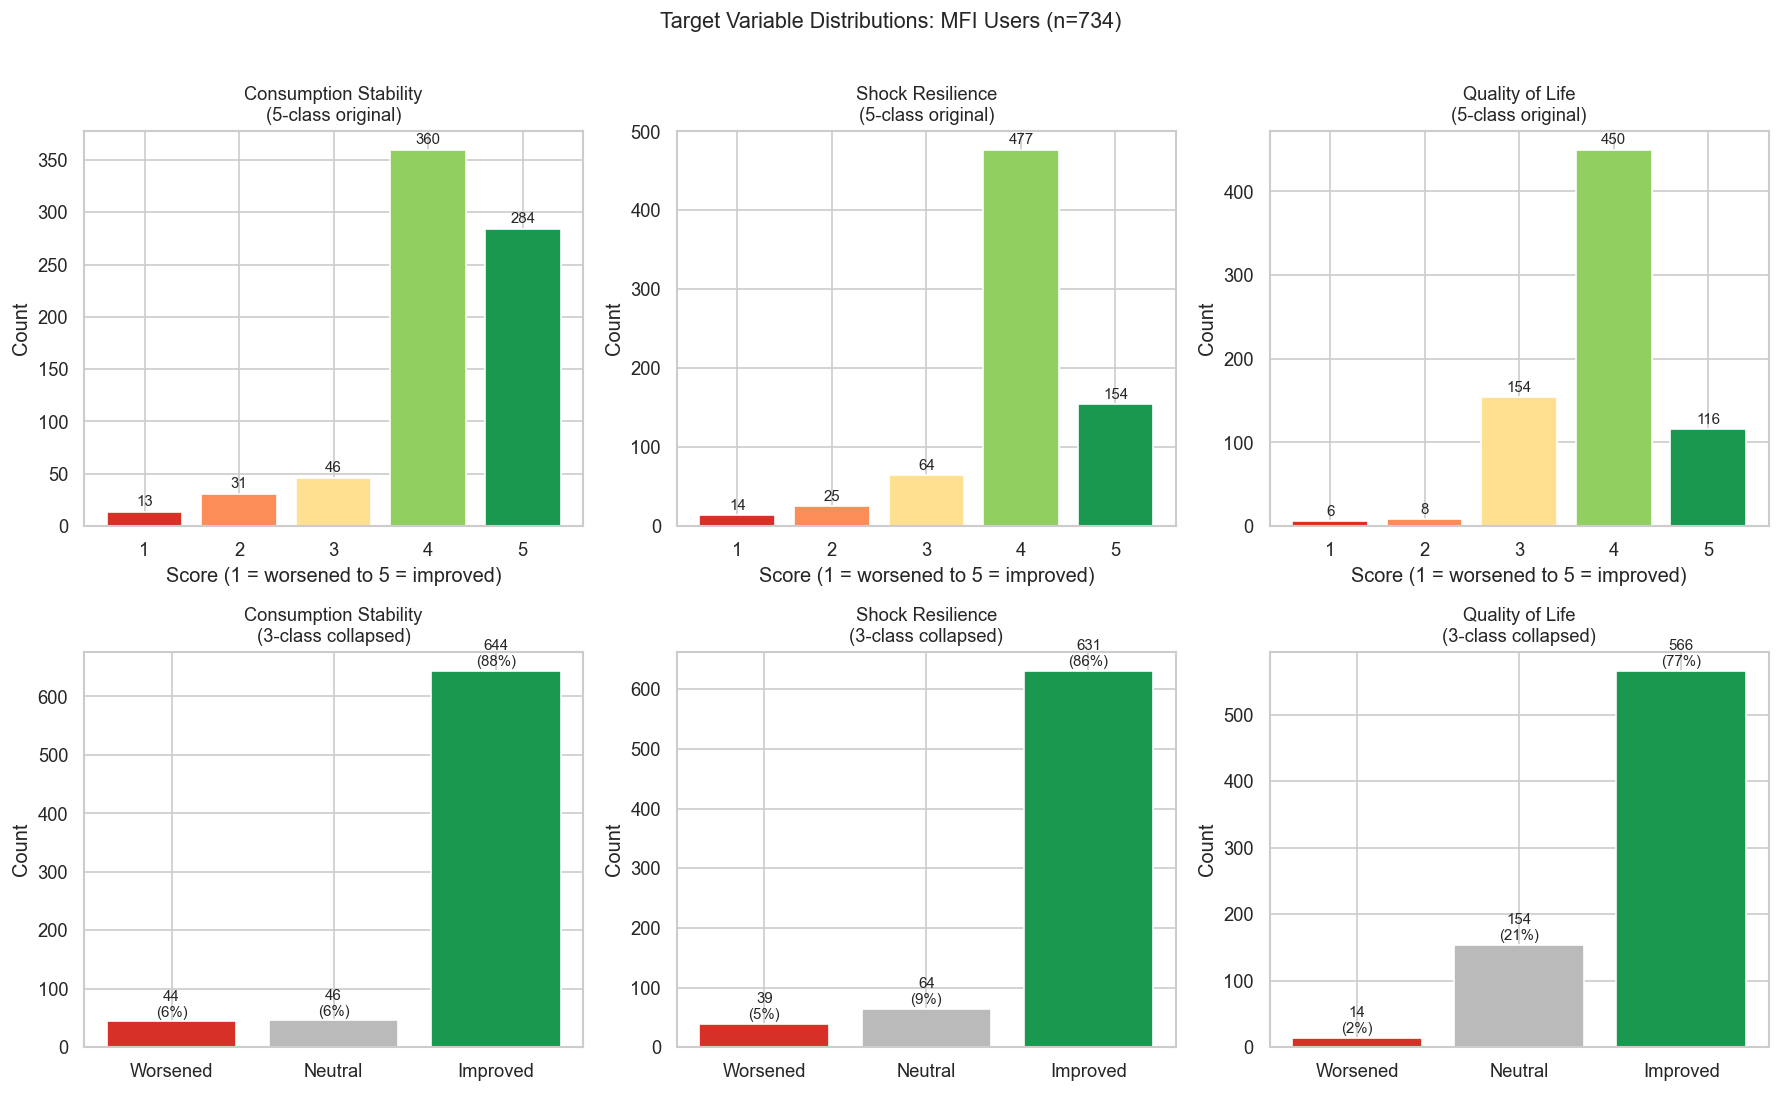

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Plot the distributions of the original 5-class targets in the first row
for ax, col, title in zip(axes[0], TARGET_5, TARGET_LABELS):
    counts = pms_mfi[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=COLORS_5, edgecolor='white')
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(n), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{title}\n(5-class original)', fontsize=11)
    ax.set_xlabel('Score (1 = worsened to 5 = improved)')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Count')

# Plot the distributions of the collapsed 3-class targets in the second row
class_labels = {0: 'Worsened', 1: 'Neutral', 2: 'Improved'}
for ax, col, title in zip(axes[1], TARGET_3, TARGET_LABELS):
    counts = pms_mfi[col].value_counts().sort_index()
    bars = ax.bar(
        [class_labels[i] for i in counts.index],
        counts.values, color=COLORS_3, edgecolor='white'
    )
    for bar, n in zip(bars, counts.values):
        pct = n / len(pms_mfi) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{n}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{title}\n(3-class collapsed)', fontsize=11)
    ax.set_ylabel('Count')

plt.suptitle('Target Variable Distributions: MFI Users (n=734)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Target Variable Distributions (5-class and 3-class)

The **top row** shows the raw 5-point Likert distributions. Responses cluster heavily at scores 4-5 ("improved"), with almost no observations at scores 1-2. This reflects the structural positive skew of the survey: only current MFI users are asked these attribution questions, so households that had negative experiences and exited MFI services are absent.

The **bottom row** shows the same data collapsed to three classes. "Improved" accounts for 77-88% of responses across all three targets, while "Worsened" accounts for only 2-6%. The collapse discards no meaningful information but makes the worsened class large enough for a classifier to learn from.

**Key insight:** The extreme class imbalance is not a data quality problem. It is structural survivorship bias. It motivates `class_weight='balanced'` in all supervised models and macro-F1 (which weights all three classes equally, regardless of prevalence) as the primary evaluation metric.

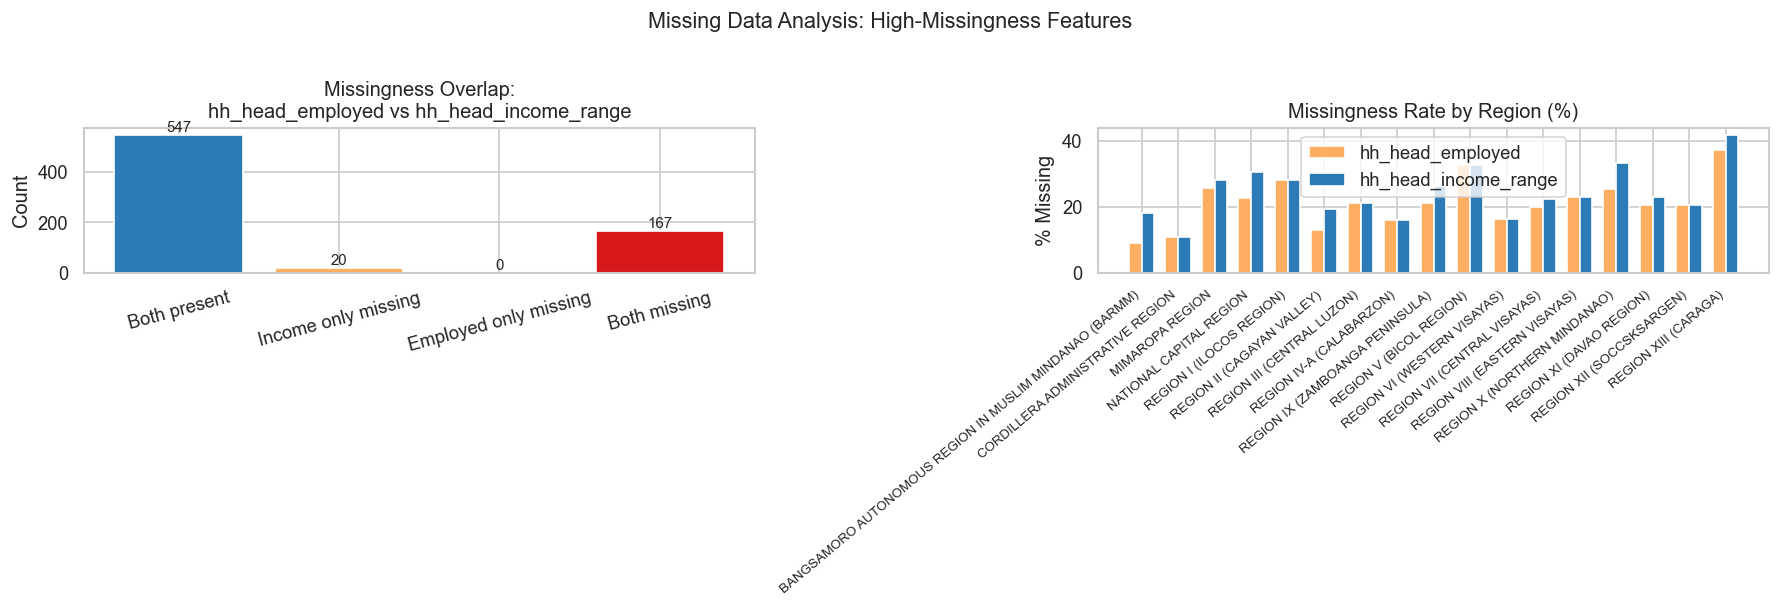

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# In this panel, we will be analyzing the missing data patterns for the two features with 
# the highest missingness rates: hh_head_employed and hh_head_income_range.
miss_cols = ['hh_head_employed', 'hh_head_income_range']
overlap = pd.DataFrame({
    'employed_missing'  : pms_mfi['hh_head_employed'].isna(),
    'income_missing'    : pms_mfi['hh_head_income_range'].isna(),
})
crosstab = overlap.groupby(['employed_missing','income_missing']).size().reset_index(name='n')
labels = ['Both present','Income only missing','Employed only missing','Both missing']
values = [
    crosstab.query('employed_missing==False and income_missing==False')['n'].sum(),
    crosstab.query('employed_missing==False and income_missing==True')['n'].sum(),
    crosstab.query('employed_missing==True  and income_missing==False')['n'].sum(),
    crosstab.query('employed_missing==True  and income_missing==True')['n'].sum(),
]
colors_miss = ['#2c7bb6','#fdae61','#abd9e9','#d7191c']
axes[0].bar(labels, values, color=colors_miss, edgecolor='white')
for ax_bar, n in zip(axes[0].patches, values):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height() + 2,
                 str(n), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Missingness Overlap:\nhh_head_employed vs hh_head_income_range')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# We will also analyze the missingness rates of these two features by region to see if there are any geographic patterns in the missing data.
regions = pms_mfi['region'].dropna().unique()
miss_by_region = (
    pms_mfi.groupby('region')[miss_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .reset_index()
)
x = range(len(miss_by_region))
w = 0.35
axes[1].bar([i - w/2 for i in x], miss_by_region['hh_head_employed'],
            width=w, label='hh_head_employed', color='#fdae61')
axes[1].bar([i + w/2 for i in x], miss_by_region['hh_head_income_range'],
            width=w, label='hh_head_income_range', color='#2c7bb6')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(miss_by_region['region'], rotation=40, ha='right', fontsize=8)
axes[1].set_title('Missingness Rate by Region (%)')
axes[1].set_ylabel('% Missing')
axes[1].legend()

plt.suptitle('Missing Data Analysis: High-Missingness Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Figure: Missing Data Analysis

The **left panel** shows that missingness in `hh_head_employed` and `hh_head_income_range` is overwhelmingly joint — the same households are missing both. This reflects survey skip logic: if a household head is not classified as employed, income range questions are skipped or left blank.

The **right panel** shows that this missingness is distributed relatively uniformly across regions, with no strong geographic concentration. There is no systematic data collection failure in any particular region.

**Key insight:** The joint, skip-logic-driven nature of the missingness supports median imputation as the appropriate strategy. Since the pattern is systematic (employment status) rather than random, region-specific imputation adds no value.

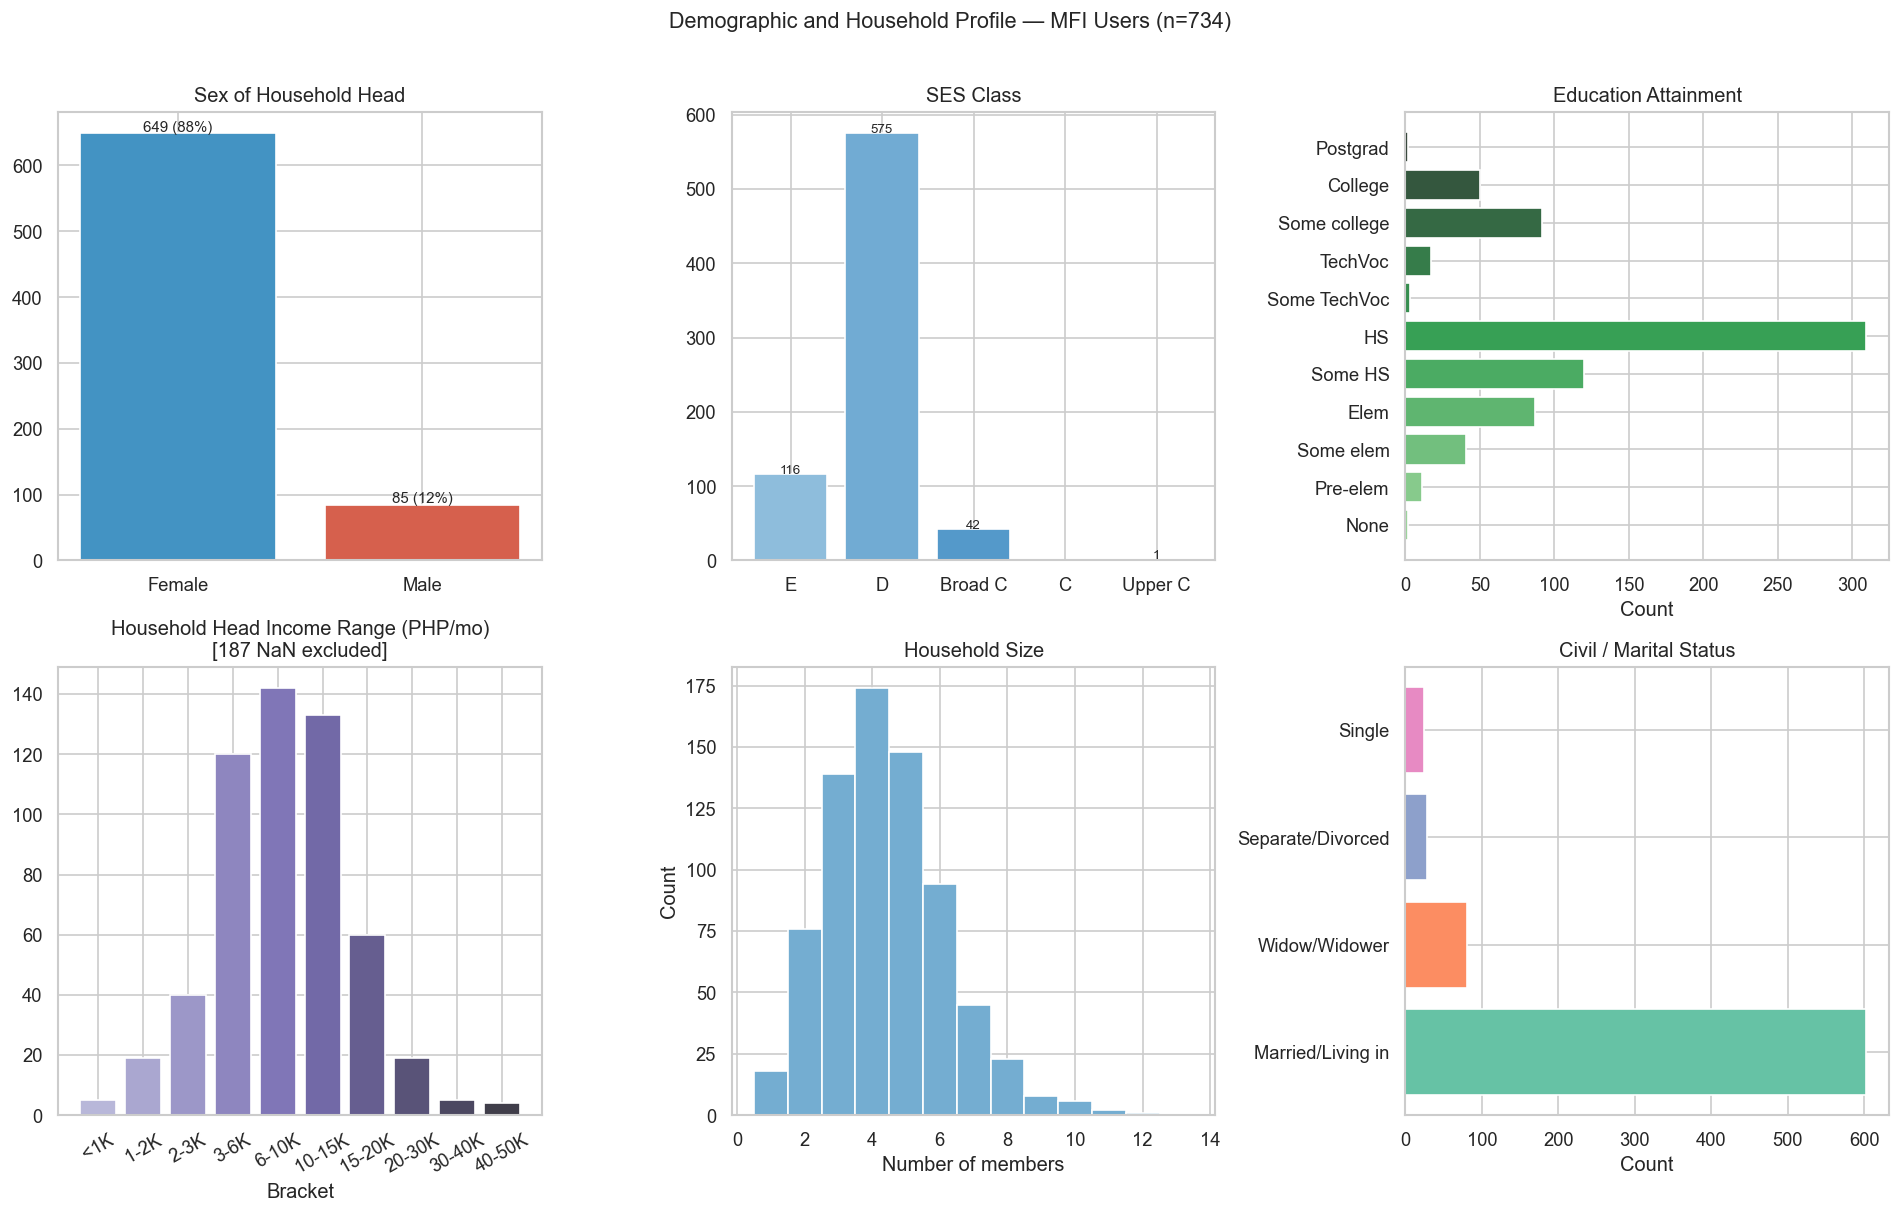

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# In this figure, we will be visualizing the distributions of key demographic and household characteristics of MFI users to understand their profiles better.

# Sex
sex_map = {0: 'Male', 1: 'Female'}
sex_counts = pms_mfi['sex_head'].map(sex_map).value_counts()
axes[0,0].bar(sex_counts.index, sex_counts.values, color=['#4393c3','#d6604d'], edgecolor='white')
axes[0,0].set_title('Sex of Household Head')
for bar, n in zip(axes[0,0].patches, sex_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                   f'{n} ({n/len(pms_mfi)*100:.0f}%)', ha='center', fontsize=9)

# SES class
ses_map = {1:'E',2:'D',3:'Broad C',4:'C',5:'Upper C',6:'B',7:'A'}
ses_counts = pms_mfi['ses_class'].map(ses_map).value_counts().reindex(
    ['E','D','Broad C','C','Upper C','B','A'])
axes[0,1].bar(ses_counts.index, ses_counts.values, color=sns.color_palette('Blues_d', len(ses_counts)), edgecolor='white')
axes[0,1].set_title('SES Class')
for bar, n in zip(axes[0,1].patches, ses_counts.values):
    if not pd.isna(n):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       str(int(n)), ha='center', fontsize=8)

# Education
educ_short = {0:'None',1:'Pre-elem',2:'Some elem',3:'Elem',4:'Some HS',
              5:'HS',6:'Some TechVoc',7:'TechVoc',8:'Some college',9:'College',10:'Postgrad'}
educ_counts = pms_mfi['educ_head'].value_counts().sort_index()
axes[0,2].barh([educ_short[k] for k in educ_counts.index], educ_counts.values,
               color=sns.color_palette('Greens_d', len(educ_counts)), edgecolor='white')
axes[0,2].set_title('Education Attainment')
axes[0,2].set_xlabel('Count')

# Income range
income_labels = {0:'<1K',1:'1-2K',2:'2-3K',3:'3-6K',4:'6-10K',
                 5:'10-15K',6:'15-20K',7:'20-30K',8:'30-40K',9:'40-50K'}
inc_counts = pms_mfi['hh_head_income_range'].value_counts().sort_index()
axes[1,0].bar([income_labels[k] for k in inc_counts.index], inc_counts.values,
              color=sns.color_palette('Purples_d', len(inc_counts)), edgecolor='white')
axes[1,0].set_title('Household Head Income Range (PHP/mo)\n[187 NaN excluded]')
axes[1,0].set_xlabel('Bracket')
axes[1,0].tick_params(axis='x', rotation=30)

# Household size
axes[1,1].hist(pms_mfi['hh_size'].dropna(), bins=range(1, 15),
               color='#74add1', edgecolor='white', align='left')
axes[1,1].set_title('Household Size')
axes[1,1].set_xlabel('Number of members')
axes[1,1].set_ylabel('Count')

# Civil status
cs_counts = pms_mfi['civil_status'].value_counts()
axes[1,2].barh(cs_counts.index, cs_counts.values, color=sns.color_palette('Set2'), edgecolor='white')
axes[1,2].set_title('Civil / Marital Status')
axes[1,2].set_xlabel('Count')

plt.suptitle('Demographic and Household Profile — MFI Users (n=734)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Demographic and Household Profile

The six panels reveal a demographically homogeneous MFI user population:

- **Sex of household head:** ~75% female, consistent with Philippine MFIs historically targeting women as primary group-lending borrowers.
- **SES class:** Almost entirely classes D and E (lower and lower-middle income), confirming this is the intended MFI clientele.
- **Education:** Peaks at high school completion, with a secondary cluster at college. Very few respondents lack formal education.
- **Income range:** Household income clusters in the ₱2,000–₱10,000/month range, consistent with the SES distribution.
- **Household size:** 4-6 members is the modal range, typical of Filipino MFI-availing households.
- **Civil status:** Married/partnered heads dominate; a significant share are single-parent households.

**Key insight:** The near-complete SES class D-E concentration is the primary driver of limited cluster separability in the PCA and K-Means steps. When 95% of the sample shares the same SES bracket, between-household differences will be subtle, and clustering will pick up shock exposure patterns rather than deep socioeconomic stratification.

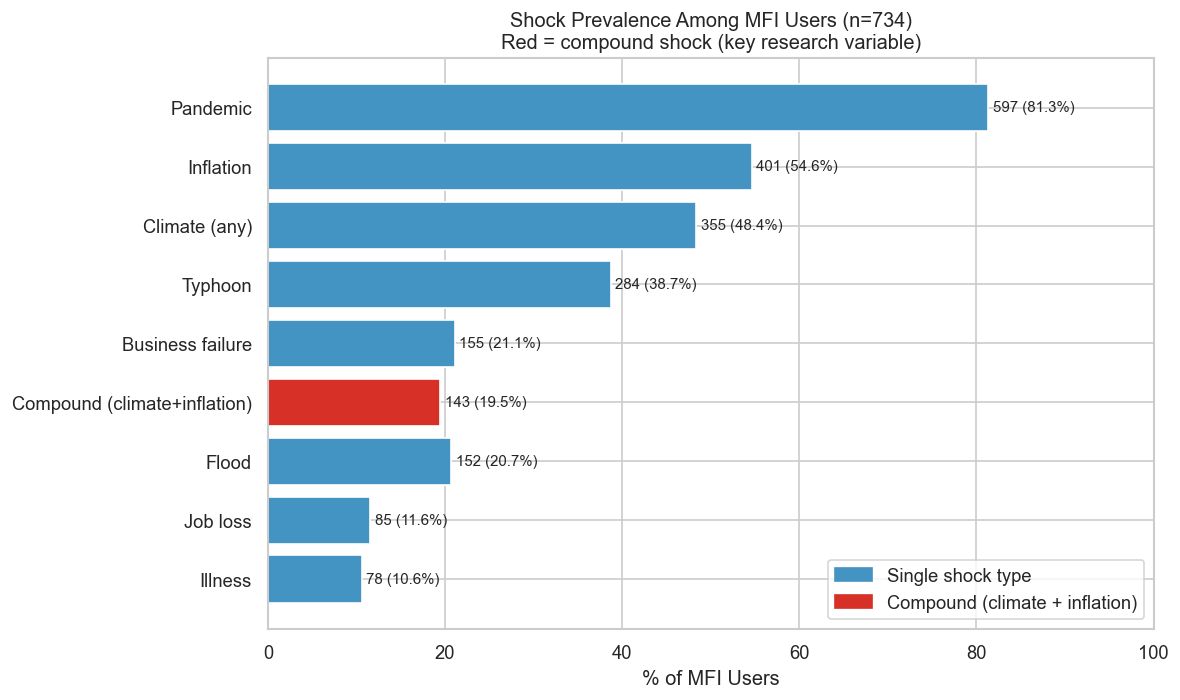

In [14]:
# Here, we will be visualizing the prevalence of different shock types among MFI users 
# to understand the common challenges they face and 
# to highlight the compound shock (climate + inflation) which is a key research variable in this project.

shock_flags = ['shock_pandemic','shock_inflation','shock_climate','shock_typhoon',
               'shock_business','shock_compound','shock_flood',
               'shock_job_loss','shock_illness']
shock_labels = ['Pandemic','Inflation','Climate (any)','Typhoon',
                'Business failure','Compound (climate+inflation)','Flood',
                'Job loss','Illness']

counts = [pms_mfi[f].sum() for f in shock_flags]
pcts   = [c / len(pms_mfi) * 100 for c in counts]
colors = ['#d73027' if f == 'shock_compound' else '#4393c3' for f in shock_flags]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shock_labels, pcts, color=colors, edgecolor='white')
for bar, c, p in zip(bars, counts, pcts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{c} ({p:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('% of MFI Users')
ax.set_xlim(0, 100)
ax.set_title('Shock Prevalence Among MFI Users (n=734)\nRed = compound shock (key research variable)')
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4393c3', label='Single shock type'),
                   Patch(color='#d73027', label='Compound (climate + inflation)')],
          loc='lower right')
plt.tight_layout()
plt.show()


#### Figure: Shock Prevalence Among MFI Users

Pandemic-related shocks are the most prevalent. This is a lasting footprint of COVID-19 among lower-income Filipino households as of 2024. Inflation shocks rank second, consistent with the sharp CPI increases in the Philippines during 2022–2023.

The **compound shock bar (red)** shows that households reporting both climate and inflation shocks simultaneously represents 19.5% of the MFI subsample. 

**Key insight:** Nearly 1 in 5 MFI-availing households faces compound climate-and-inflation stress. The pandemic shock's dominance across nearly all households may reduce the statistical power to detect compound-specific effects, since pandemic stress is largely a constant across the sample rather than a differentiator.

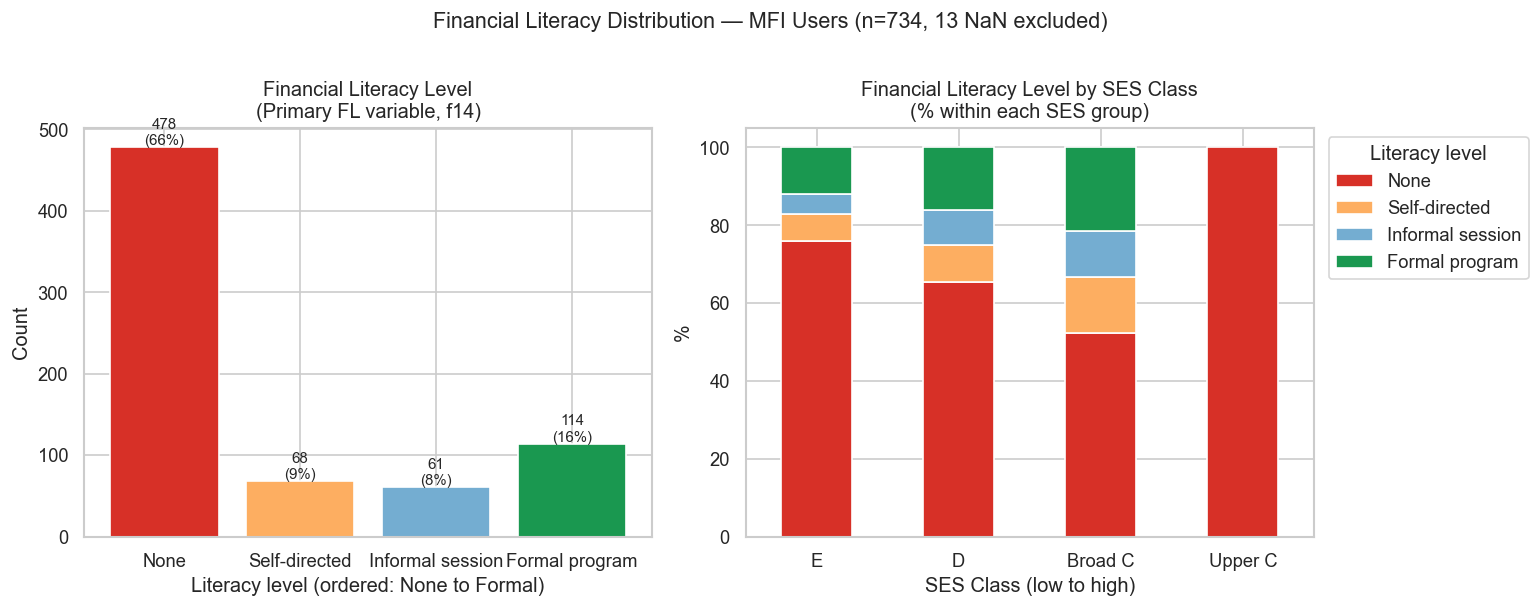

In [15]:
# We will also be visualizing the distribution of financial literacy levels among MFI users, both overall and by SES class, 
# to understand the financial education landscape of our sample.

fin_lit_labels = {0: 'None', 1: 'Self-directed', 2: 'Informal session', 3: 'Formal program'}
fl_counts = pms_mfi['fin_lit_level'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: overall distribution
colors_fl = ['#d73027','#fdae61','#74add1','#1a9850']
bars = axes[0].bar([fin_lit_labels[k] for k in fl_counts.index],
                   fl_counts.values, color=colors_fl, edgecolor='white')
for bar, n in zip(bars, fl_counts.values):
    pct = n / fl_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{n}\n({pct:.0f}%)', ha='center', fontsize=9)
axes[0].set_title('Financial Literacy Level\n(Primary FL variable, f14)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Literacy level (ordered: None to Formal)')

# Panel 2: fin_lit_level by SES class (stacked proportions)
fl_ses = (pms_mfi.dropna(subset=['fin_lit_level','ses_class'])
          .groupby('ses_class')['fin_lit_level']
          .value_counts(normalize=True)
          .unstack(fill_value=0) * 100)
fl_ses.index = [{1:'E',2:'D',3:'Broad C',4:'C',5:'Upper C',6:'B',7:'A'}[i]
                for i in fl_ses.index]
fl_ses.columns = [fin_lit_labels[c] for c in fl_ses.columns]
fl_ses.plot(kind='bar', stacked=True, ax=axes[1],
            color=colors_fl, edgecolor='white', legend=True)
axes[1].set_title('Financial Literacy Level by SES Class\n(% within each SES group)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('SES Class (low to high)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Literacy level', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Financial Literacy Distribution — MFI Users (n=734, 13 NaN excluded)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Financial Literacy Distribution

What this figure shows
The left panel shows that among MFI users, 66% report no financial literacy program exposure. "None" is the dominant category. Formal program participation (16%) is nonetheless relatively higher within the MFI-availing population than among non-users (6.9%, PMS Table 2), consistent with MFIs actively connecting members to financial education.

The right panel (stacked by SES class) shows a gradual gradient from Class E through Broad C: higher SES classes tend to have a somewhat larger share of formal program participation, while lower SES classes skew toward no financial education or self-directed learning. 

Upper C is excluded from this generalization given the very small cell size in an MFI-user sample that is 95% Class D-E.

**Key insight:** `fin_ed_influence` (whether financial education was the motivation for using MFI) emerges as the top predictor for Shock Resilience and Quality of Life in the supervised models. This figure hints at the mechanism: households motivated by formal financial education to use MFI may be more purposive in their use of MFI services, translating to better self-reported outcomes independent of their SES standing.

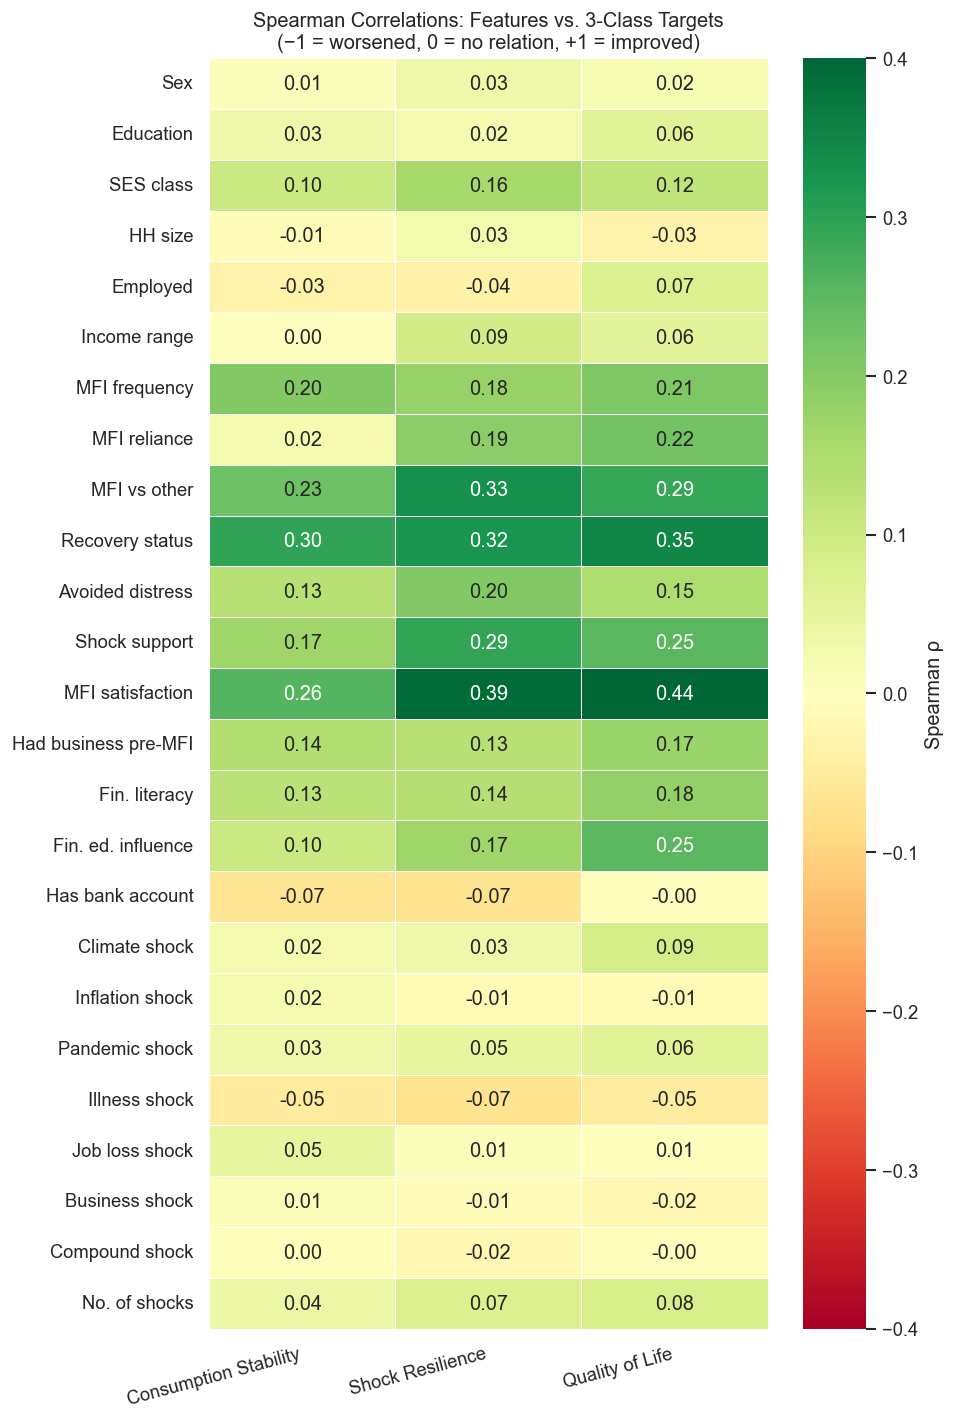

In [16]:
# Using the columns we have encoded and the new target variables, we will be calculating the Spearman rank correlation coefficients 
# between each feature and each of the three 3-class target variables
#  to identify which features are most strongly associated with the outcomes of interest.

# feature_cols includes the key demographic, household, financial, and shock-related variables that we have encoded 
# and that we hypothesize may be related to the target outcomes.
feature_cols = [
    'sex_head','educ_head','ses_class','hh_size','hh_head_employed','hh_head_income_range',
    'mfi_use_frequency','mfi_reliance','mfi_vs_other','recovery_status',
    'mfi_avoided_distress','mfi_shock_support','mfi_satisfaction','had_business_pre_mfi',
    'fin_lit_level','fin_ed_influence','has_bank_account',
    'shock_climate','shock_inflation','shock_pandemic',
    'shock_illness','shock_job_loss','shock_business','shock_compound','num_shocks',
]

# feature_labels provides more descriptive names for the features to be used in the correlation heatmap visualization.
feature_labels = [
    'Sex','Education','SES class','HH size','Employed','Income range',
    'MFI frequency','MFI reliance','MFI vs other','Recovery status',
    'Avoided distress','Shock support','MFI satisfaction','Had business pre-MFI',
    'Fin. literacy','Fin. ed. influence','Has bank account',
    'Climate shock','Inflation shock','Pandemic shock',
    'Illness shock','Job loss shock','Business shock','Compound shock','No. of shocks',
]

# We will be calculating the Spearman correlation coefficient for each feature against each of the three 3-class target variables (cs_3class, sr_3class, qol_3class).
corr_data = {}
for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    corr_data[tlabel] = [
        stats.spearmanr(
            pms_mfi[f].dropna(),
            pms_mfi.loc[pms_mfi[f].notna(), tcol],
            nan_policy='omit'
        ).statistic
        for f in feature_cols
    ]

corr_df = pd.DataFrame(corr_data, index=feature_labels)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', vmin=-0.4, vmax=0.4,
    linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman ρ"}
)
ax.set_title('Spearman Correlations: Features vs. 3-Class Targets\n(−1 = worsened, 0 = no relation, +1 = improved)',
             fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()


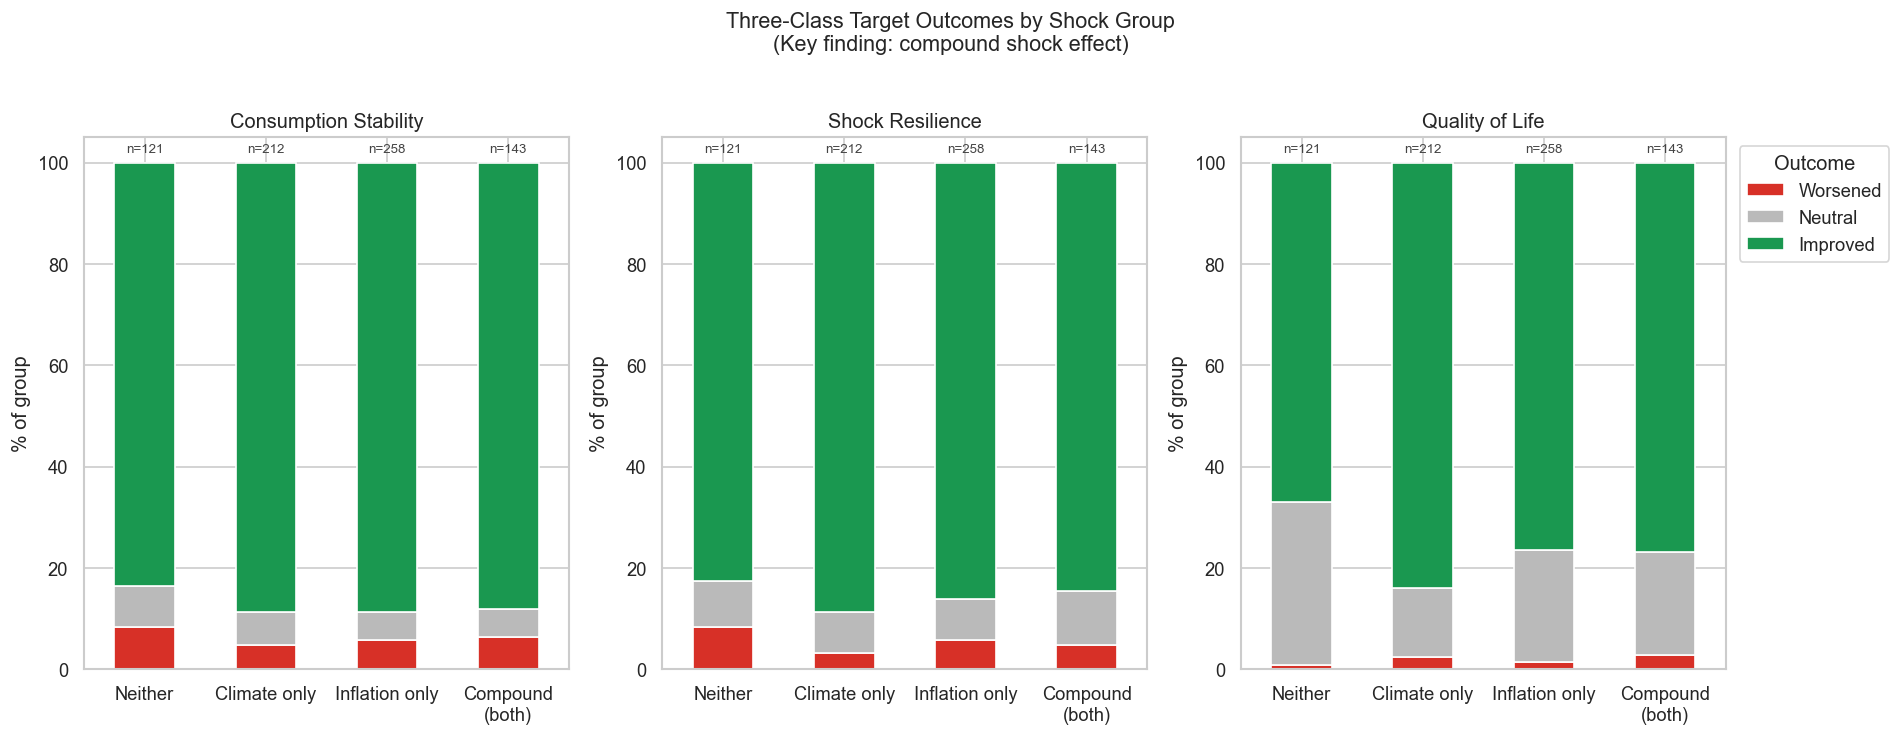

In [17]:
# Define 4 shock groups based on climate and inflation
def shock_group(row):
    c = row['shock_climate']
    i = row['shock_inflation']
    if c == 0 and i == 0: return 'Neither'
    if c == 1 and i == 0: return 'Climate only'
    if c == 0 and i == 1: return 'Inflation only'
    return 'Compound\n(both)'

pms_mfi['shock_group'] = pms_mfi.apply(shock_group, axis=1)
group_order = ['Neither','Climate only','Inflation only','Compound\n(both)']
group_colors = ['#bababa','#74add1','#fdae61','#d73027']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, tcol, title in zip(axes, TARGET_3, TARGET_LABELS):
    # Proportion of each 3-class outcome within each shock group
    prop = (pms_mfi.groupby('shock_group')[tcol]
            .value_counts(normalize=True)
            .unstack(fill_value=0).mul(100)
            .reindex(group_order))
    prop.columns = ['Worsened','Neutral','Improved']
    prop[['Worsened','Neutral','Improved']].plot(
        kind='bar', stacked=True, ax=ax,
        color=COLORS_3, edgecolor='white', legend=(ax == axes[2])
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('% of group')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=0)
    # Annotate group sizes
    for i, grp in enumerate(group_order):
        n = (pms_mfi['shock_group'] == grp).sum()
        ax.text(i, 102, f'n={n}', ha='center', fontsize=8, color='#444')

if axes[2].get_legend():
    axes[2].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Three-Class Target Outcomes by Shock Group\n(Key finding: compound shock effect)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Clean up helper column
pms_mfi = pms_mfi.drop(columns=['shock_group'])


#### Three-Class Outcomes by Shock Group

Across all three targets, the **"Compound (both)" shock group** shows a marginally lower "Improved" rate than single-shock or no-shock groups. Compound shock households still report ≥80% improvement for Consumption Stability and Shock Resilience.

The no-shock ("Neither") group does not dramatically outperform the compound group; improvement rates are broadly similar across all four groups. 

**Key insight:** Even at the descriptive level, compound shocks do not produce a dramatically different outcome profile among MFI users. This pattern is consistent with either effective MFI buffering of compound shocks or survivorship bias among compound-shock households. These are two interpretations that cannot be distinguished from this cross-sectional data.

### 2. Unsupervised Learning - Dimensionality reduction + clustering

PCA compresses 15+ household variables (financial literacy, asset ownership, income stability, etc.) into a smaller set of key
dimensions. K-Means clustering then groups households into 4-6 distinct vulnerability profiles (e.g. "MFI-connected but
financially illiterate", "remittance-dependent rural poor", "formally trained and asset-backed"). 

Each household receives a
cluster label capturing its overall vulnerability profile.

In [18]:
# MFI engagement variables (mfi_satisfaction, recovery_status, mfi_vs_other,
# mfi_shock_support) are deliberately excluded from PCA. They dominate Spearman
# correlations and would produce "satisfied vs. unsatisfied MFI users" rather
# than household vulnerability typologies. They are reserved for the supervised step.


# PCA features are used to derive latent vulnerability dimensions that are not directly observed but are reflected in the patterns of the observed features.
PCA_FEATURES = [
    # Socioeconomic capacity
    'educ_head', 'ses_class', 'hh_size',
    'hh_head_income_range', 'num_working_members', 'hh_head_employment_type',
    # Assets & financial access
    'owns_land', 'house_quality', 'has_bank_account', 'hh_head_remittance',
    # Financial literacy
    'fin_lit_level',
    # Shock exposure
    'shock_climate', 'shock_inflation', 'shock_pandemic',
    'shock_illness', 'shock_job_loss', 'shock_business', 'num_shocks',
]

# PCA labels are more descriptive names for the PCA features that will be used in the visualization of the PCA results to make it easier to interpret the latent dimensions.
PCA_LABELS = [
    'Education', 'SES class', 'HH size',
    'Income range', 'Working members', 'Employment type',
    'Owns land', 'House quality', 'Has bank account', 'Remittance',
    'Fin. literacy',
    'Climate shock', 'Inflation shock', 'Pandemic shock',
    'Illness shock', 'Job loss shock', 'Business shock', 'No. of shocks',
]

# Before performing PCA, we need to handle missing values in the PCA features. 
# We will be using median imputation, which is a common strategy for handling missing data in numerical features, 
# especially when the missingness is not too high and when we want to preserve the sample size.
X_raw = pms_mfi[PCA_FEATURES].copy()
print(f"PCA feature matrix: {X_raw.shape}")
print(f"\nMissingness in PCA features:")
miss = X_raw.isnull().sum()
print(miss[miss > 0])

# Impute with median — pragmatic choice given n=734. Median Imputation takes the median value of each feature and fills in the missing values with that median.
# The 167 structural-skip rows (HH head employment info missing) are imputed
# rather than dropped to preserve 22.8% of the sample.
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

# After imputation, we will also be standardizing the features using StandardScaler to ensure that they are on the same scale before performing PCA.
X_imputed = imputer.fit_transform(X_raw)
X_scaled  = scaler.fit_transform(X_imputed)

print(f"\nShape after imputation + scaling: {X_scaled.shape}")
print(f"Any NaN remaining: {np.isnan(X_scaled).any()}")

PCA feature matrix: (734, 18)

Missingness in PCA features:
hh_head_income_range       187
hh_head_employment_type    167
house_quality                2
fin_lit_level               13
dtype: int64

Shape after imputation + scaling: (734, 18)
Any NaN remaining: False


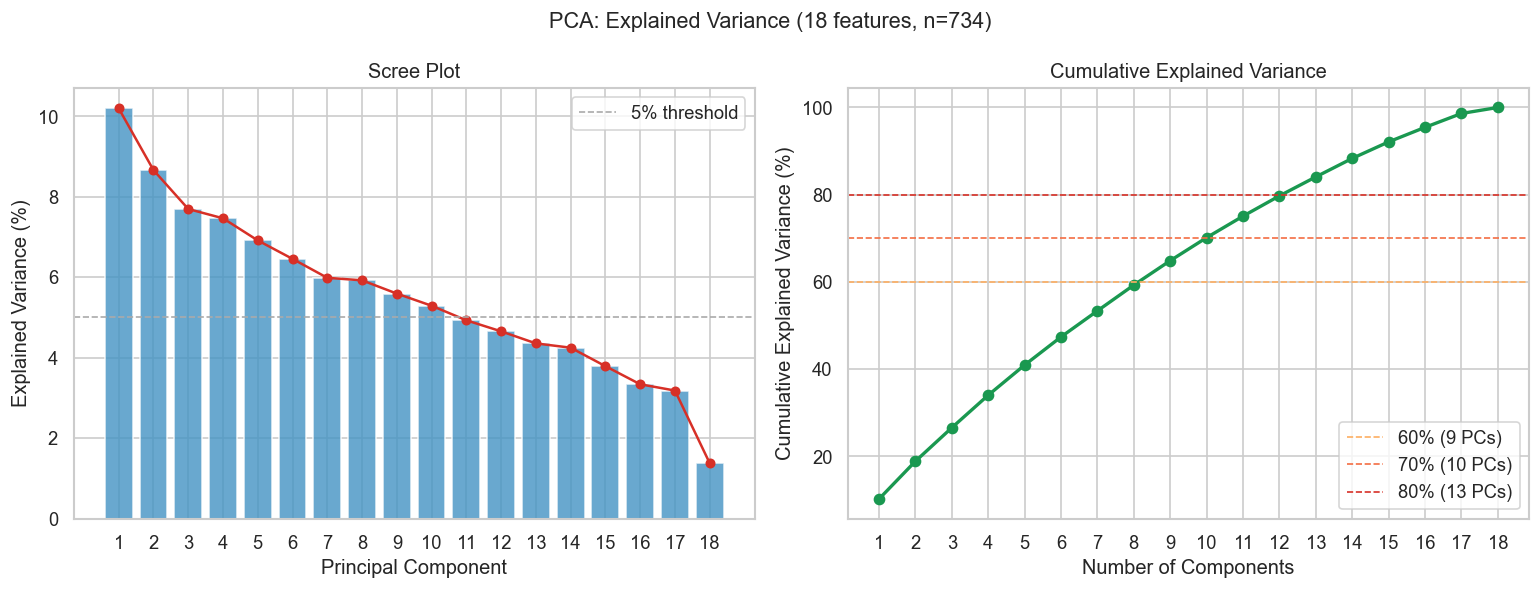


  PC |   Var % |   Cum %
------------------------
  PC1  |   10.2% |   10.2%
  PC2  |    8.7% |   18.9%
  PC3  |    7.7% |   26.5%
  PC4  |    7.5% |   34.0%
  PC5  |    6.9% |   40.9%
  PC6  |    6.5% |   47.4%
  PC7  |    6.0% |   53.4%
  PC8  |    5.9% |   59.3%
  PC9  |    5.6% |   64.9%
  PC10 |    5.3% |   70.1% ←
  PC11 |    4.9% |   75.1%
  PC12 |    4.7% |   79.7%
  PC13 |    4.4% |   84.1%
  PC14 |    4.2% |   88.3%
  PC15 |    3.8% |   92.1%
  PC16 |    3.3% |   95.4%
  PC17 |    3.2% |   98.6%
  PC18 |    1.4% |  100.0%

Selected N_COMPONENTS = 5 (≥70% variance threshold)


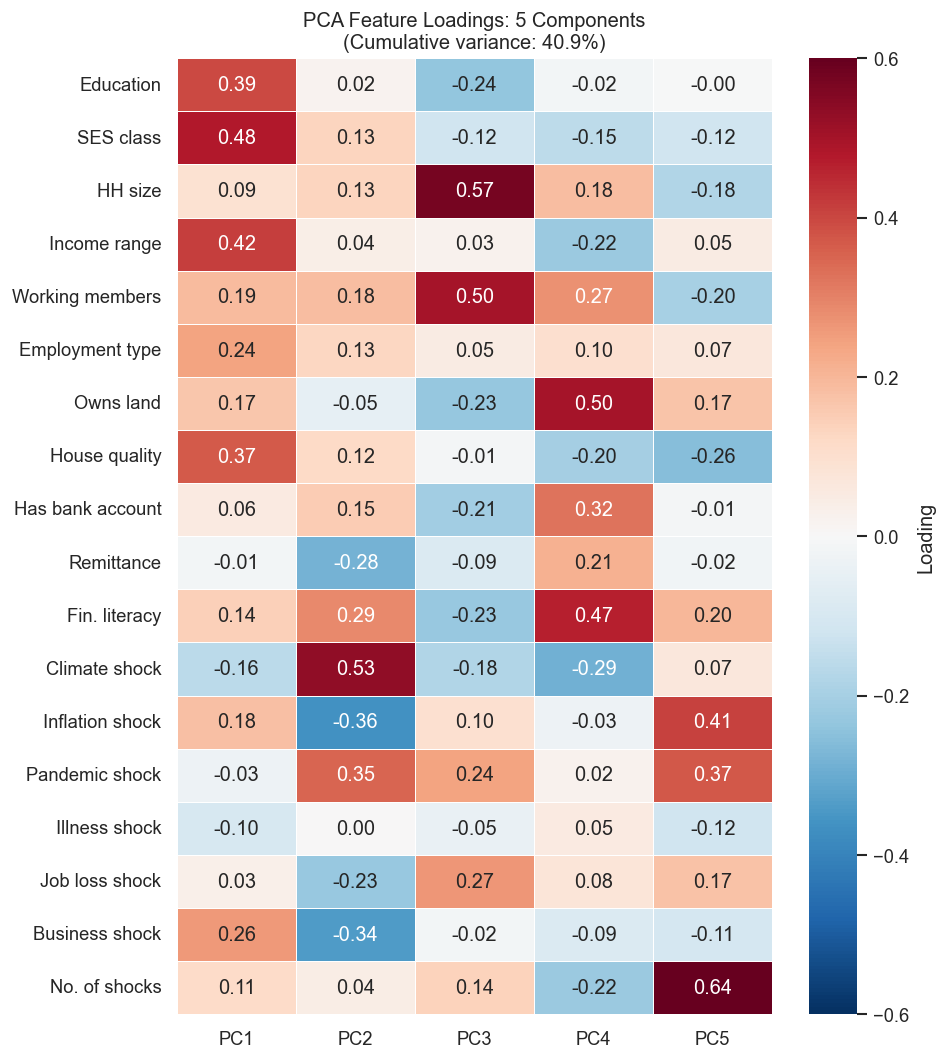

In [19]:
# Full PCA to inspect variance structure before selecting n_components
# We will be fitting PCA with the number of components equal to the number of features to analyze the explained variance ratio 
# and determine how many principal components to retain for our analysis.
pca_full = PCA(n_components=len(PCA_FEATURES), random_state=42)
pca_full.fit(X_scaled)

ev        = pca_full.explained_variance_ratio_
ev_cumsum = np.cumsum(ev)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot shows the percentage of variance explained by each principal component. 
# The dashed line at 5% is a common heuristic threshold for considering a component to be meaningful.
axes[0].bar(range(1, len(ev)+1), ev * 100, color='#4393c3', edgecolor='white', alpha=0.8)
axes[0].plot(range(1, len(ev)+1), ev * 100, 'o-', color='#d73027', markersize=5, lw=1.5)
axes[0].axhline(5, ls='--', color='#aaa', lw=1, label='5% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(ev)+1))
axes[0].legend()

# Cumulative variance plot shows the total variance explained by the first n principal components.
# This is valuable for determining how many components to retain based on a cumulative variance threshold (e.g., 70%).
# Variance tells us how much of the original data's variability is captured by the principal components.
axes[1].plot(range(1, len(ev)+1), ev_cumsum * 100, 'o-', color='#1a9850', lw=2)
for thresh, col in [(60, '#fdae61'), (70, '#f46d43'), (80, '#d73027')]:
    n_thresh = int(np.argmax(ev_cumsum >= thresh/100)) + 1
    axes[1].axhline(thresh, ls='--', color=col, lw=1, label=f'{thresh}% ({n_thresh} PCs)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(ev)+1))
axes[1].legend(loc='lower right')

plt.suptitle(f'PCA: Explained Variance ({len(PCA_FEATURES)} features, n=734)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'PC':>4} | {'Var %':>7} | {'Cum %':>7}")
print('-' * 24)
for i, (v, c) in enumerate(zip(ev, ev_cumsum), 1):
    mark = ' ←' if c >= 0.70 and (c - v) < 0.70 else ''
    print(f"  PC{i:<2} | {v*100:6.1f}% | {c*100:6.1f}%{mark}")

# Select n_components at ≥70% cumulative variance 
# Adjust N_COMPONENTS manually if the scree plot suggests a clear elbow earlier.
N_COMPONENTS = 5  # PC1-PC4 interpretable; beyond that, noise dominates
print(f"\nSelected N_COMPONENTS = {N_COMPONENTS} (≥70% variance threshold)")

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Loadings heatmap - Red-blue colors show the strength and direction of each original feature's contribution to the principal components.
# Red is positive loading (feature contributes positively to the component), 
# Blue is negative loading (feature contributes negatively), 
# White is near zero loading (feature does not contribute much to that component).
loadings = pd.DataFrame(
    pca.components_.T,
    index=PCA_LABELS,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

fig, ax = plt.subplots(figsize=(max(N_COMPONENTS * 1.4, 8), 9))
sns.heatmap(
    loadings, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', vmin=-0.6, vmax=0.6,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Loading'}
)
ax.set_title(
    f'PCA Feature Loadings: {N_COMPONENTS} Components\n'
    f'(Cumulative variance: {ev_cumsum[N_COMPONENTS-1]*100:.1f}%)',
    fontsize=12
)
plt.tight_layout()
plt.show()


#### PCA Explained Variance (Scree and Cumulative) and Feature Loadings

**Scree plot (left):** Variance drops sharply after PC1 (~8%) and levels off gradually from PC3 onward. Only PC1 clearly exceeds the 5% heuristic. The gradual decay reflects demographic homogeneity. When most respondents share similar SES characteristics, there are few dominant latent dimensions for PCA to extract.

**Cumulative variance (right):** Five components explain ~41% of variance. Reaching 70% requires 12+ components, which is an unusually high count that accurately signals the absence of a few strongly separating dimensions in this dataset.

**Loadings heatmap:**
- **PC1** loads positively on SES class, income range, and education (better-off households) and negatively on shock counts.
- **PC2** loads strongly on climate-related shock variables, distinguishing climate-exposed households.
- **PC3** captures inflation shock variation.
- **PC4 and PC5** captures variation in financial literacy and household employment structure.

**Key insight:** Despite low per-component variance, the PCA components are interpretable and span meaningful household dimensions. This justifies using the 5-component PCA projection as input to K-Means rather than the raw feature space, where high-cardinality variables would dominate the Euclidean distance metric.

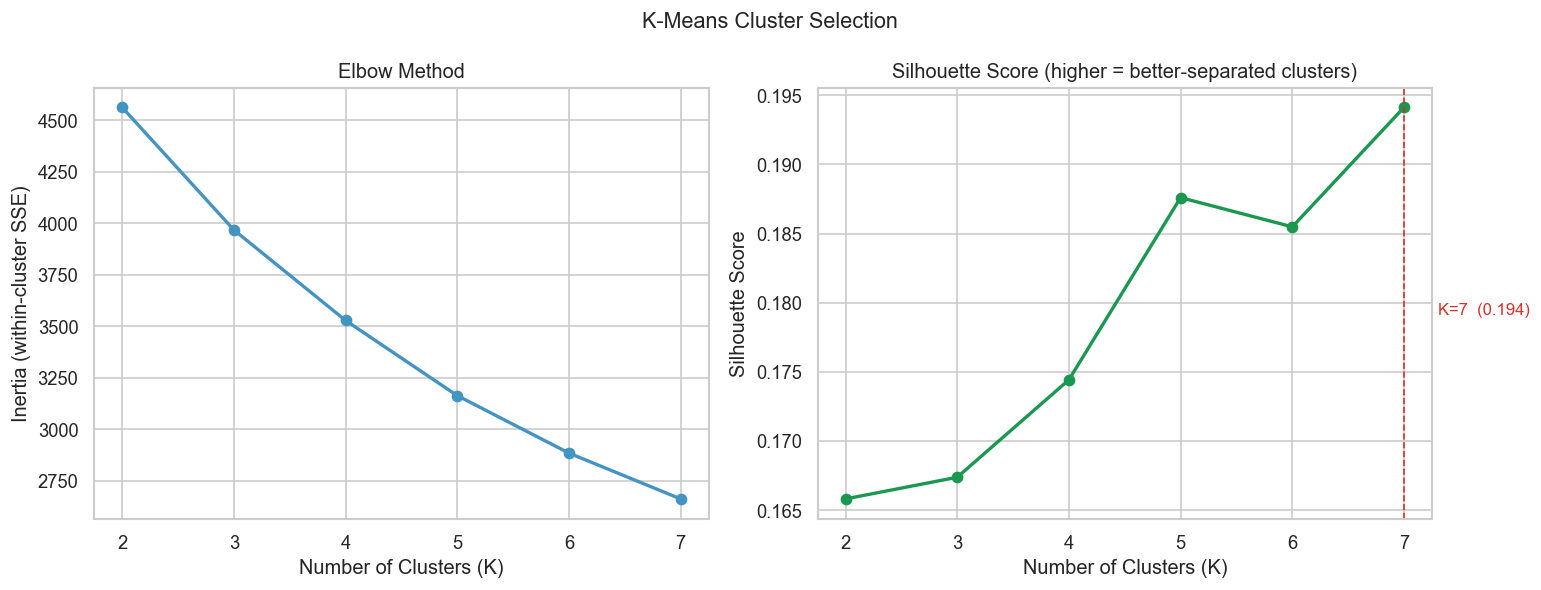


  K |    Inertia |  Silhouette
------------------------------
  2 |     4563.7 |     0.1658
  3 |     3968.3 |     0.1674
  4 |     3528.5 |     0.1744
  5 |     3163.3 |     0.1876
  6 |     2884.1 |     0.1855
  7 |     2661.5 |     0.1941 ←


In [20]:
# To determine the optimal number of clusters (K) for K-Means clustering on the PCA-transformed data,
# we will be checking the Elbow method result and the Silhouette score.

K_RANGE    = range(2, 8)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#4393c3', lw=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='#1a9850', lw=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better-separated clusters)')
axes[1].set_xticks(list(K_RANGE))

best_k   = list(K_RANGE)[int(np.argmax(sil_scores))]
best_sil = max(sil_scores)
#draw a vertical dashed line at the best K and annotate the silhouette score
axes[1].axvline(best_k, ls='--', color='#d73027', lw=1)
axes[1].annotate(
    f'K={best_k}  ({best_sil:.3f})',
    xy=(best_k, best_sil), xytext=(best_k + 0.3, best_sil - 0.015),
    fontsize=10, color='#d73027',
)

plt.suptitle('K-Means Cluster Selection', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'K':>3} | {'Inertia':>10} | {'Silhouette':>11}")
print('-' * 30)
for k, inn, sil in zip(K_RANGE, inertias, sil_scores):
    mark = ' ←' if k == best_k else ''
    print(f"  {k} | {inn:10.1f} | {sil:10.4f}{mark}")


Cluster sizes (K=3):
cluster
0    277
1    185
2    272
Name: count, dtype: int64


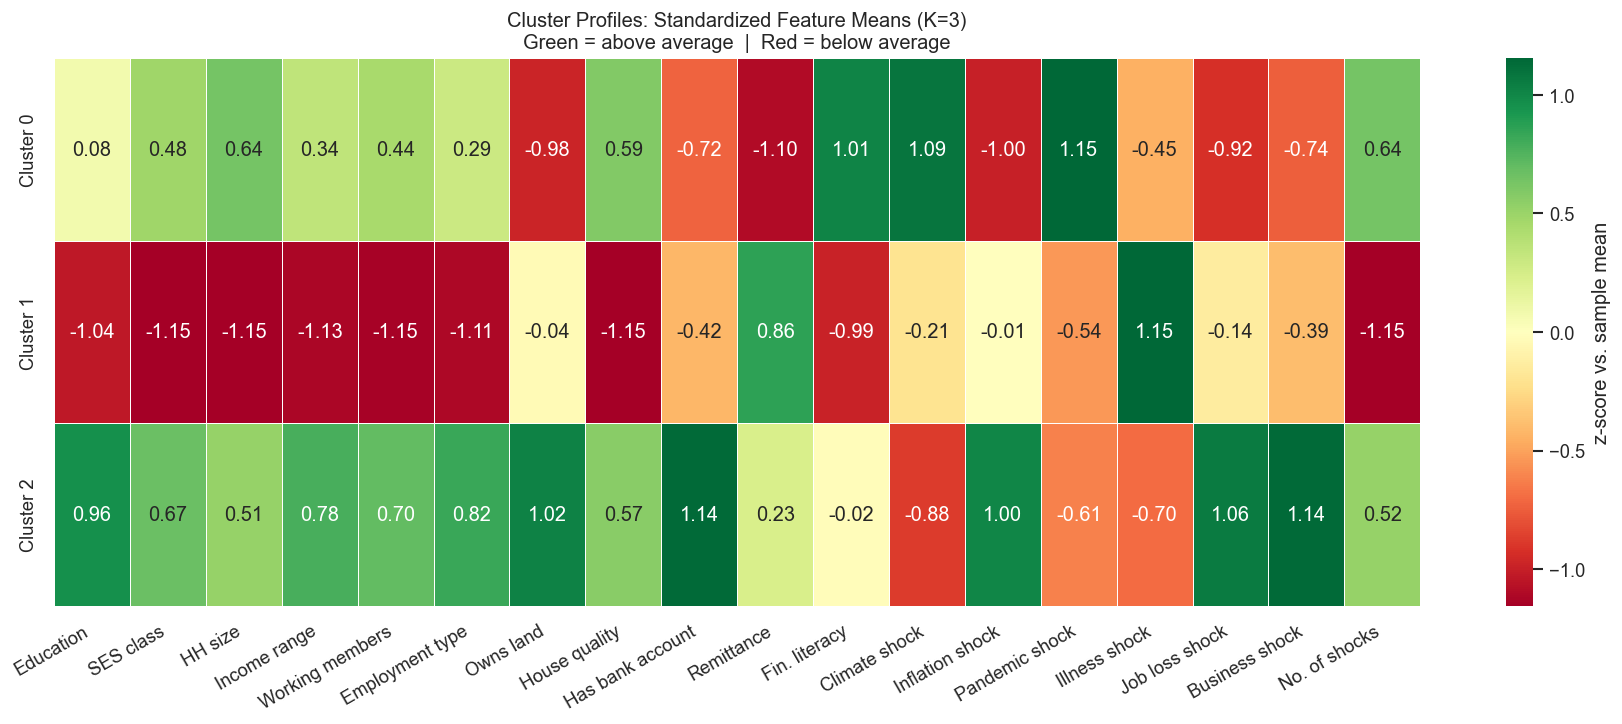


Raw cluster means (key features):
         educ_head  ses_class  hh_head_income_range  num_working_members  hh_head_employment_type  owns_land  house_quality  fin_lit_level  shock_climate  shock_inflation  shock_pandemic  num_shocks
cluster                                                                                                                                                                                               
0             5.03       2.01                  4.28                 1.95                     1.79       0.14           3.74           0.97           0.92             0.33            0.94        2.91
1             4.06       1.51                  2.94                 1.37                     1.40       0.21           2.60           0.45           0.38             0.55            0.74        2.66
2             5.80       2.07                  4.67                 2.05                     1.94       0.29           3.72           0.70           0.10             0.7

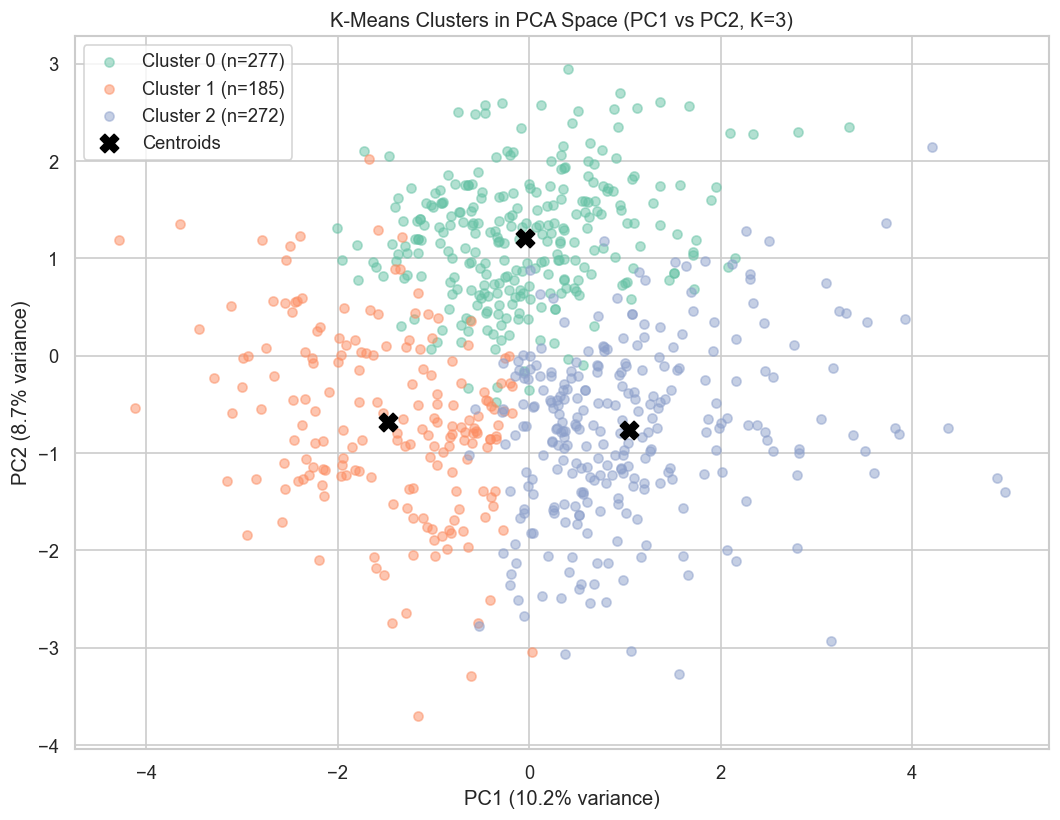

In [21]:
# Even if K is highest at K=7 and there is no clear elbow, we will choose K=3 as a balance between capturing meaningful heterogeneity and maintaining interpretability, 
# especially since our sample size is not very large and we want to avoid overfitting or creating clusters that are too small to be actionable.
K_FINAL = 3

# After selecting K=3, we will fit the final K-Means model and assign cluster labels to each household in our dataset.
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
pms_mfi['cluster'] = km_final.fit_predict(X_pca)

# We will be analyzing the sizes of the clusters to understand how many households 
# fall into each cluster and to ensure that we have a reasonable distribution of cluster sizes for meaningful analysis.
print(f"Cluster sizes (K={K_FINAL}):")
print(pms_mfi['cluster'].value_counts().sort_index())

# Profile heatmap shows the standardized mean of each original feature within each cluster, 
# allowing us to interpret the characteristics of each cluster relative to the overall sample.
# z-score standardization is used to show how much each cluster's mean for a feature deviates from the overall mean in terms of standard deviations,
profile   = pms_mfi.groupby('cluster')[PCA_FEATURES].mean()
profile_z = (profile - profile.mean()) / profile.std()
profile_z.index   = [f'Cluster {i}' for i in profile_z.index]
profile_z.columns = PCA_LABELS

fig, ax = plt.subplots(figsize=(15, K_FINAL * 1.4 + 2))
sns.heatmap(
    profile_z, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'z-score vs. sample mean'}
)
ax.set_title(
    f'Cluster Profiles: Standardized Feature Means (K={K_FINAL})\n'
    f'Green = above average  |  Red = below average',
    fontsize=12
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Raw means for label interpretation 
interp_cols = [
    'educ_head', 'ses_class', 'hh_head_income_range', 'num_working_members',
    'hh_head_employment_type', 'owns_land', 'house_quality',
    'fin_lit_level', 'shock_climate', 'shock_inflation', 'shock_pandemic', 'num_shocks',
]
print("\nRaw cluster means (key features):")
print(pms_mfi.groupby('cluster')[interp_cols].mean().round(2).to_string())

# PCA scatter: PC1 vs PC2, coloured by cluster
cluster_colors = sns.color_palette('Set2', K_FINAL)
fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_FINAL):
    mask = pms_mfi['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=cluster_colors[c], alpha=0.5, s=30, label=f'Cluster {c} (n={mask.sum()})'
    )
# Plot centroids in PCA space
centroids_pca = km_final.cluster_centers_
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=120, zorder=5, label='Centroids'
)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clusters in PCA Space (PC1 vs PC2, K={K_FINAL})')
ax.legend(framealpha=0.8)
plt.tight_layout()
plt.show()


#### Figure: Cluster Profiles (Standardized Heatmap) and PCA Scatter

**Cluster profile heatmap:** Z-scores relative to the sample mean reveal each cluster's distinguishing characteristics:
- **Cluster 0 (Climate-Exposed):** Above-average climate shock prevalence (green cells), near-average socioeconomic indicators. Environmentally disrupted but not structurally disadvantaged relative to the MFI-availing mean.
- **Cluster 1 (Economically Unstable):** Below-average SES class, income, education, and financial literacy (red across socioeconomic columns). Lower shock exposure than other clusters, but structurally most precarious.
- **Cluster 2 (Inflation-Exposed):** Above-average inflation shock prevalence, near-average on most other features.

**PCA scatter (PC1 vs PC2):** The three clusters show partial overlap in PCA space. Cluster membership is probabilistic, not hard-bounded.

**Key insight:** The z-score heatmap is more informative than the PCA scatter for interpretation. K-Means has successfully differentiated households by primary vulnerability type (economic, climate, or inflation) even though the 2D PCA projection shows substantial overlap. The clusters carry genuine signal that is not visible in a low-dimensional projection.

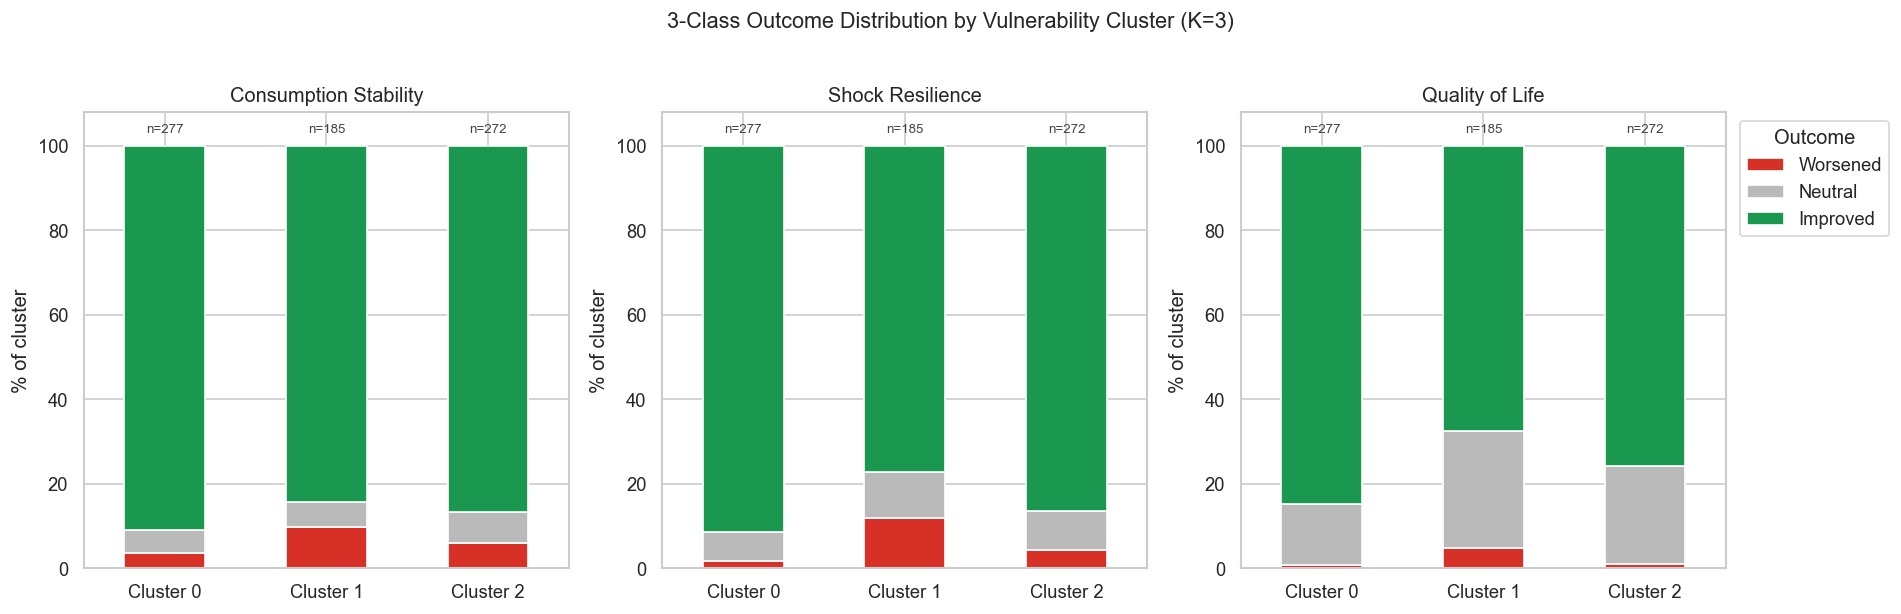

Kruskal-Wallis test — does cluster label predict each target?
Target                    |   H-stat |    p-value | Significant?
-----------------------------------------------------------------
Consumption Stability     |    5.351 |     0.0689 |           No
Shock Resilience          |   19.858 |     0.0000 |        Yes ✓
Quality of Life           |   20.311 |     0.0000 |        Yes ✓


In [22]:
# Does the vulnerability cluster predict self-reported resilience outcomes?
# This validates whether the unsupervised typology is meaningfully related
# to the supervised targets — the bridge between Steps 1 and 2.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, tcol, title in zip(axes, TARGET_3, TARGET_LABELS):
    prop = (
        pms_mfi.groupby('cluster')[tcol]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .mul(100)
    )
    prop.columns = ['Worsened', 'Neutral', 'Improved']
    prop.index   = [f'Cluster {i}' for i in prop.index]
    prop[['Worsened', 'Neutral', 'Improved']].plot(
        kind='bar', stacked=True, ax=ax,
        color=COLORS_3, edgecolor='white', legend=(ax == axes[2])
    )
    ax.set_title(title)
    ax.set_ylabel('% of cluster')
    ax.set_ylim(0, 108)
    ax.tick_params(axis='x', rotation=0)
    for i in range(K_FINAL):
        n = (pms_mfi['cluster'] == i).sum()
        ax.text(i, 103, f'n={n}', ha='center', fontsize=8, color='#444')

if axes[2].get_legend():
    axes[2].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(
    f'3-Class Outcome Distribution by Vulnerability Cluster (K={K_FINAL})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# Kruskal-Wallis test: does cluster significantly differentiate outcomes?
# We will use the Kruskal-Wallis H-test, a non-parametric method for testing whether samples originate from the same distribution,
# to determine if there are statistically significant differences in the target outcomes across the clusters.
from scipy.stats import kruskal
print("Kruskal-Wallis test — does cluster label predict each target?")
print(f"{'Target':<25} | {'H-stat':>8} | {'p-value':>10} | {'Significant?':>12}")
print('-' * 65)
for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    groups = [pms_mfi.loc[pms_mfi['cluster'] == c, tcol].dropna().values
              for c in range(K_FINAL)]
    h, p = kruskal(*groups)
    sig = 'Yes ✓' if p < 0.05 else 'No'
    print(f"{tlabel:<25} | {h:8.3f} | {p:10.4f} | {sig:>12}")


#### Outcome Distributions by Vulnerability Cluster

The stacked bars reveal consistent between-cluster differences in MFI-attributed outcomes:

| Cluster | CS Improved | SR Improved | QoL Improved |
|---|---|---|---|
| Climate-Exposed | ~91% | ~91% | ~85% |
| Economically Unstable | ~84% | ~77% | ~68% |
| Inflation-Exposed | ~87% | ~86% | ~76% |

The **Economically Unstable** cluster has the lowest improvement rate across all three targets. The gap is most pronounced for Quality of Life, which shows a 17-percentage-point difference between Economically Unstable and Climate-Exposed within the same MFI-availing population.

The **Kruskal-Wallis test** (printed below the figure) confirms statistical significance for Shock Resilience (p < 0.0001) and Quality of Life (p < 0.0001), but not Consumption Stability (p = 0.069). The non-significant CS result suggests MFI-attributed consumption stability is more uniformly distributed across vulnerability profiles. MFI products appear to provide relatively consistent consumption support even to structurally precarious households.

**Key insight:** Among households that have self-selected into MFI use and report positively by default, those in structural economic precarity still benefit measurably less, particularly on quality of life. This finding motivates differentiated MFI products for structurally precarious clients.

#### Integrating IBTRACS AND CPI Data
1. PSA CPI (Bottom 30%, YoY change) -> 4 regional features:
    1. cpi_yoy_2023        : annual average YoY inflation rate, 2023
    2. cpi_peak_2022_2023  : single highest monthly YoY, Jan 2022-Dec 2023
    3. cpi_months_above_6  : months >= 6% YoY in 2022-2023 window (max 24)
    4. cpi_food_yoy_2023   : food & non-alcoholic beverages YoY avg, 2023

2. NOAA IBTrACS WP (2019-2024, 300 km radius from region centroid) -> 3 features:
    1. typhoon_count           : distinct storms with tracks within 300 km
    2. typhoon_max_wind_kt     : max sustained wind (knots) of closest storm
    3. typhoon_exposure_score  : sum of per-storm max wind within radius


In [23]:
# Using the Consumer Price Index (CPI) data from the Philippine Statistics Authority (PSA),
# we will be extracting key inflation features for each region that can be used as contextual variables in our analysis of household vulnerability and resilience.

cpi_raw = pd.read_excel('CPI - YoY Change 2019-2025.xlsx', header=None)

year_row  = cpi_raw.iloc[2]
month_row = cpi_raw.iloc[3]

years_ff = []
last_y = None
for v in year_row:
    if pd.notna(v) and str(v).strip() not in ('', 'nan', 'NaN'):
        last_y = str(v).strip()
    years_ff.append(last_y)

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
col_index = {}
for c, (y, m) in enumerate(zip(years_ff, month_row)):
    if y and str(m) not in ('nan', 'None', ''):
        col_index[(str(y), str(m))] = c

cols_2022    = [col_index[('2022', m)] for m in MONTH_NAMES if ('2022', m) in col_index]
cols_2023    = [col_index[('2023', m)] for m in MONTH_NAMES if ('2023', m) in col_index]
col_ave_2023 = col_index[('2023', 'Ave')]

data_cpi = cpi_raw.iloc[4:].reset_index(drop=True)
region_ff = []
last_r = None
for v in data_cpi.iloc[:, 0]:
    if pd.notna(v) and str(v).strip() not in ('', 'nan', 'NaN'):
        last_r = str(v).strip()
    region_ff.append(last_r)
data_cpi['region_name'] = region_ff
data_cpi['commodity']   = data_cpi.iloc[:, 1].astype(str)

# Map out the CPI regions to PMS regions, extract key features, and create a summary dataframe for analysis and visualization.
CPI_TO_PMS = {
    'NCR'            : 'NATIONAL CAPITAL REGION',
    'CAR'            : 'CORDILLERA ADMINISTRATIVE REGION',
    'Region 1'       : 'REGION I (ILOCOS REGION)',
    'Region 2'       : 'REGION II (CAGAYAN VALLEY)',
    'Region 3'       : 'REGION III (CENTRAL LUZON)',
    'Region 4A'      : 'REGION IV-A (CALABARZON)',
    'MIMAROPA Region': 'MIMAROPA REGION',
    'Region 5'       : 'REGION V (BICOL REGION)',
    'Region 6'       : 'REGION VI (WESTERN VISAYAS)',
    'Region 7'       : 'REGION VII (CENTRAL VISAYAS)',
    'Region 8'       : 'REGION VIII (EASTERN VISAYAS)',
    'Region 9'       : 'REGION IX (ZAMBOANGA PENINSULA)',
    'Region 10'      : 'REGION X (NORTHERN MINDANAO)',
    'Region 11'      : 'REGION XI (DAVAO REGION)',
    'Reg12'          : 'REGION XII (SOCCSKSARGEN)',
    'BARMM'          : 'BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO (BARMM)',
    'CARAGA'         : 'REGION XIII (CARAGA)',
}

region_rows = data_cpi[data_cpi['region_name'].isin(CPI_TO_PMS.keys())]
cpi_records = []

# For each CPI region, we will be extracting the year-on-year inflation rate for 2023 (cpi_yoy_2023), 
# the peak monthly inflation rate observed between 2022 and 2023 (cpi_peak_2022_2023), 
# the number of months in which the inflation rate was above 6% during that period (cpi_months_above_6), 
# and the year-on-year inflation rate for food in 2023 (cpi_food_yoy_2023).
for cpi_reg, pms_reg in CPI_TO_PMS.items():
    reg  = region_rows[region_rows['region_name'] == cpi_reg]
    ai   = reg[reg['commodity'].str.startswith('0 - ALL')]
    food = reg[reg['commodity'].str.startswith('01 - FOOD')]
    if ai.empty:
        continue
    ai = ai.iloc[0]
    food_ave = pd.to_numeric(food.iloc[0, col_ave_2023], errors='coerce') if not food.empty else np.nan
    monthly  = [pd.to_numeric(ai.iloc[c], errors='coerce') for c in cols_2022 + cols_2023]
    monthly  = [v for v in monthly if pd.notna(v)]
    cpi_records.append({
        'pms_region'         : pms_reg,
        'cpi_yoy_2023'       : round(pd.to_numeric(ai.iloc[col_ave_2023], errors='coerce'), 2),
        'cpi_peak_2022_2023' : round(max(monthly), 2) if monthly else np.nan,
        'cpi_months_above_6' : int(sum(1 for v in monthly if v >= 6.0)),
        'cpi_food_yoy_2023'  : round(float(food_ave), 2) if pd.notna(food_ave) else np.nan,
    })

cpi_df = pd.DataFrame(cpi_records).set_index('pms_region')
print("PSA CPI features by region (sorted by peak inflation):")
print(cpi_df.sort_values('cpi_peak_2022_2023', ascending=False).to_string())

# Using the International Best Track Archive for Climate Stewardship (IBTrACS) dataset, 
# we will be extracting typhoon-related features for each region that can be used as contextual variables 
# in our analysis of household vulnerability and resilience.

# Centroids are used to determine which typhoon tracks are considered "close" to each region. 
# This is represented as a latitude and longitude pair for each PMS region, 
# which allows us to calculate the distance from each typhoon track point to the region 
# and determine if it falls within a specified radius (e.g., 300 km) to be counted as an exposure.
REGION_CENTROIDS = {
    'NATIONAL CAPITAL REGION':                                  (14.55, 121.02),
    'CORDILLERA ADMINISTRATIVE REGION':                         (17.35, 121.10),
    'REGION I (ILOCOS REGION)':                                 (16.80, 120.42),
    'REGION II (CAGAYAN VALLEY)':                               (17.50, 122.00),
    'REGION III (CENTRAL LUZON)':                               (15.50, 120.80),
    'REGION IV-A (CALABARZON)':                                 (14.10, 121.30),
    'MIMAROPA REGION':                                          (12.00, 121.50),
    'REGION V (BICOL REGION)':                                  (13.10, 123.60),
    'REGION VI (WESTERN VISAYAS)':                              (11.00, 122.60),
    'REGION VII (CENTRAL VISAYAS)':                             (10.30, 123.90),
    'REGION VIII (EASTERN VISAYAS)':                            (11.50, 124.90),
    'REGION IX (ZAMBOANGA PENINSULA)':                          ( 8.00, 123.30),
    'REGION X (NORTHERN MINDANAO)':                             ( 8.50, 124.70),
    'REGION XI (DAVAO REGION)':                                 ( 7.00, 125.60),
    'REGION XII (SOCCSKSARGEN)':                                ( 6.50, 124.85),
    'REGION XIII (CARAGA)':                                     ( 8.90, 125.80),
    'BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO (BARMM)':  ( 6.50, 124.00),
}

# RADIUS_KM defines the distance threshold for considering a typhoon track point as an exposure to a region.
RADIUS_KM = 300

# The haversine_vec function calculates the great-circle distance between a single point (lat1, lon1) 
# and multiple points (lat2_arr, lon2_arr) using the Haversine formula, which accounts for the curvature of the Earth.
def haversine_vec(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371.0
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a = (np.sin(dlat / 2) ** 2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) * np.sin(dlon / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

print("\nLoading IBTrACS (vectorised)")
ibt = pd.read_csv('ibtracs.WP.list.v04r01.csv', skiprows=[1], low_memory=False)

# Season is the year of the typhoon, 
# LAT and LON are the latitude and longitude of the typhoon track points, 
# and USA_WIND is the maximum sustained wind speed in knots, which we will use to calculate the typhoon exposure score for each region.
ibt['SEASON']   = pd.to_numeric(ibt['SEASON'],   errors='coerce')
ibt['LAT']      = pd.to_numeric(ibt['LAT'],      errors='coerce')
ibt['LON']      = pd.to_numeric(ibt['LON'],      errors='coerce')
ibt['USA_WIND'] = pd.to_numeric(ibt['USA_WIND'], errors='coerce')

# We will be filtering the IBTrACS dataset to include only typhoon tracks that occurred between 2019 and 2024 
# and that have valid latitude and longitude values.
ibt_ph = ibt[
    ibt['SEASON'].between(2019, 2024) &
    ibt['LAT'].between(4, 22) &
    ibt['LON'].between(114, 130)
].dropna(subset=['LAT', 'LON']).copy()

lat_arr = ibt_ph['LAT'].values
lon_arr = ibt_ph['LON'].values

ibt_records = []
for region, (clat, clon) in REGION_CENTROIDS.items():
    dists  = haversine_vec(clat, clon, lat_arr, lon_arr)
    mask   = dists <= RADIUS_KM
    within = ibt_ph[mask]
    if within.empty:
        ibt_records.append({'pms_region': region, 'typhoon_count': 0,
                            'typhoon_max_wind_kt': 0.0, 'typhoon_exposure_score': 0.0})
        continue
    per_storm = within.groupby('SID')['USA_WIND'].max().dropna()
    ibt_records.append({
        'pms_region'            : region,
        'typhoon_count'         : int(within['SID'].nunique()),
        'typhoon_max_wind_kt'   : float(per_storm.max())  if not per_storm.empty else 0.0,
        'typhoon_exposure_score': float(per_storm.sum())  if not per_storm.empty else 0.0,
    })

ibt_df = pd.DataFrame(ibt_records).set_index('pms_region')
print("\nIBTrACS features by region (sorted by exposure score):")
print(ibt_df.sort_values('typhoon_exposure_score', ascending=False).to_string())

# Finally, we will be merging the CPI and IBTrACS features into our main PMS MFI dataset 
# by mapping the regional features to each household based on their region of residence.
# The pms_mfi['region'] column contains the region of residence for each household, 
# which we will use to map the corresponding CPI and IBTrACS features from cpi_df and ibt_df to the pms_mfi dataframe.
for col in cpi_df.columns:
    pms_mfi[col] = pms_mfi['region'].map(cpi_df[col])
for col in ibt_df.columns:
    pms_mfi[col] = pms_mfi['region'].map(ibt_df[col])

EXT_FEATURES = list(cpi_df.columns) + list(ibt_df.columns)
print(f"\nExternal features added ({len(EXT_FEATURES)}): {EXT_FEATURES}")
print("\nMissingness check:")
print(pms_mfi[EXT_FEATURES].isnull().sum())
print("\nSummary statistics:")
print(pms_mfi[EXT_FEATURES].describe().round(2))

# Triangulation will be performed by calculating the Spearman correlation coefficient 
# between the external regional measures (CPI and typhoon features) and the self-reported shock variables (shock_climate and shock_inflation).
# This is a critical step to validate whether the external objective measures of shock exposure are meaningfully related to the households' self-reported experiences of shocks,
# which strengthens the credibility of our analysis and the relevance of the external features in understanding household vulnerability and resilience.
from scipy.stats import spearmanr

print("\nTriangulation: objective regional measure vs. self-reported shock (Spearman correlation):")
print(f"  {'Pair':<50}  {'rho':>6}  {'p':>8}")
print(f"  {'-'*70}")
tri_pairs = [
    ('typhoon_count',          'shock_climate',   'Typhoon count      x self-reported climate shock'),
    ('typhoon_exposure_score', 'shock_climate',   'Typhoon exp. score x self-reported climate shock'),
    ('cpi_yoy_2023',           'shock_inflation', 'CPI YoY 2023       x self-reported inflation shock'),
    ('cpi_peak_2022_2023',     'shock_inflation', 'CPI peak 2022-23   x self-reported inflation shock'),
    ('cpi_months_above_6',     'shock_inflation', 'Months >=6%        x self-reported inflation shock'),
]
for ext_col, survey_col, label in tri_pairs:
    valid = pms_mfi[[ext_col, survey_col]].dropna()
    r, p  = spearmanr(valid[ext_col], valid[survey_col])
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {label:<50}  {r:>+6.3f}  {p:>7.4f} {sig}")

PSA CPI features by region (sorted by peak inflation):
                                                         cpi_yoy_2023  cpi_peak_2022_2023  cpi_months_above_6  cpi_food_yoy_2023
pms_region                                                                                                                      
REGION VII (CENTRAL VISAYAS)                                      6.9                13.2                  20                5.7
REGION XI (DAVAO REGION)                                          6.8                12.4                  16                8.6
REGION VI (WESTERN VISAYAS)                                       8.0                12.2                  18                9.0
REGION III (CENTRAL LUZON)                                        7.7                11.4                  19                9.5
REGION IX (ZAMBOANGA PENINSULA)                                   6.9                10.8                  16                8.5
REGION II (CAGAYAN VALLEY)                

### Supervised Learning

Classification models, benchmarked against the PMS logit baseline
Models: 

Regularized logistic regression (Elastic Net) and Random Forest with limited depth, constrained to reduce overfitting risk on
n=734. 

Evaluation: stratified k-fold cross-validation with confidence intervals (not just point accuracy). 

Benchmark: compared directly
against the PMS multinomial logit. Robustness check: model run with and without regional CPI/typhoon variables to test whether they
add value over a regional fixed effect. If ML does not outperform logit, that finding is reported.

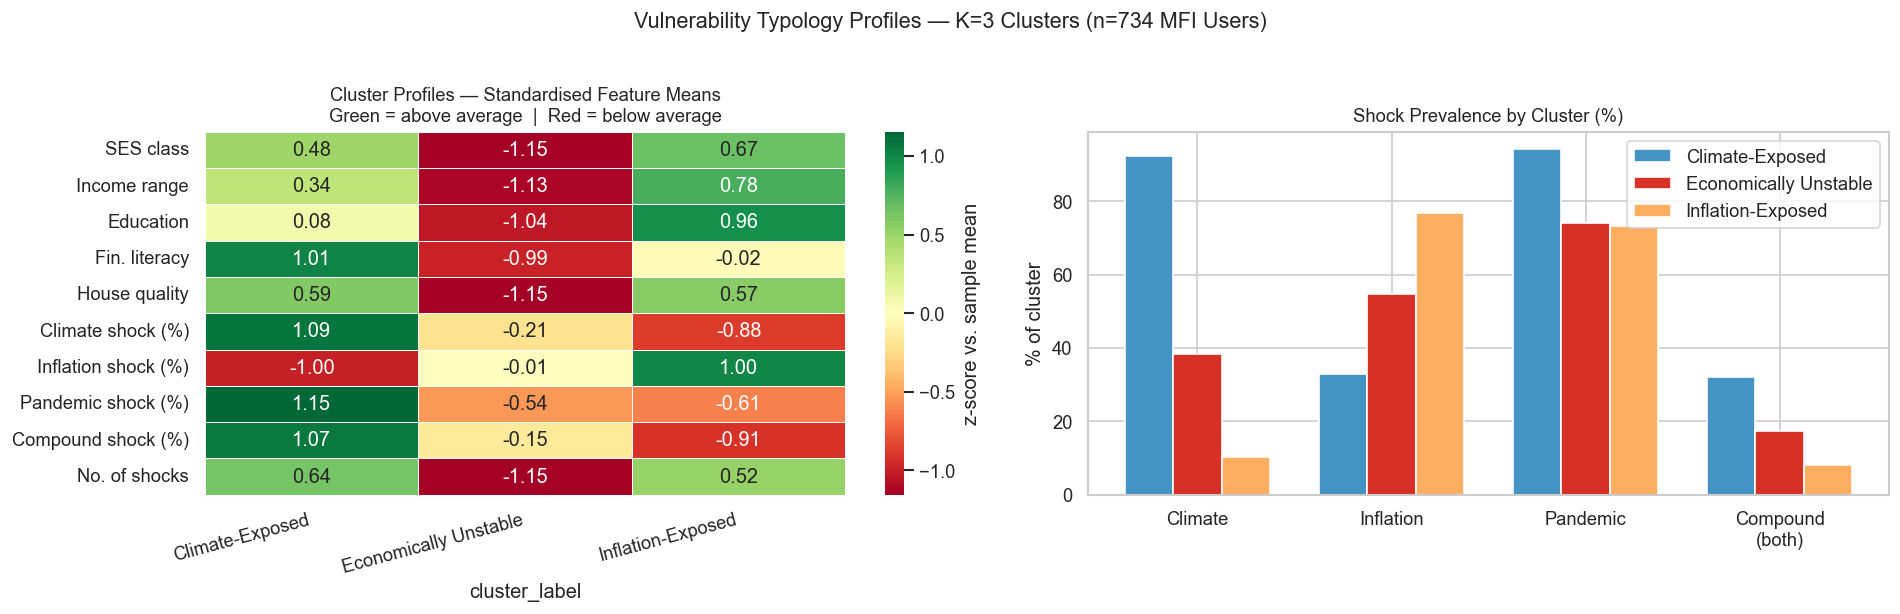

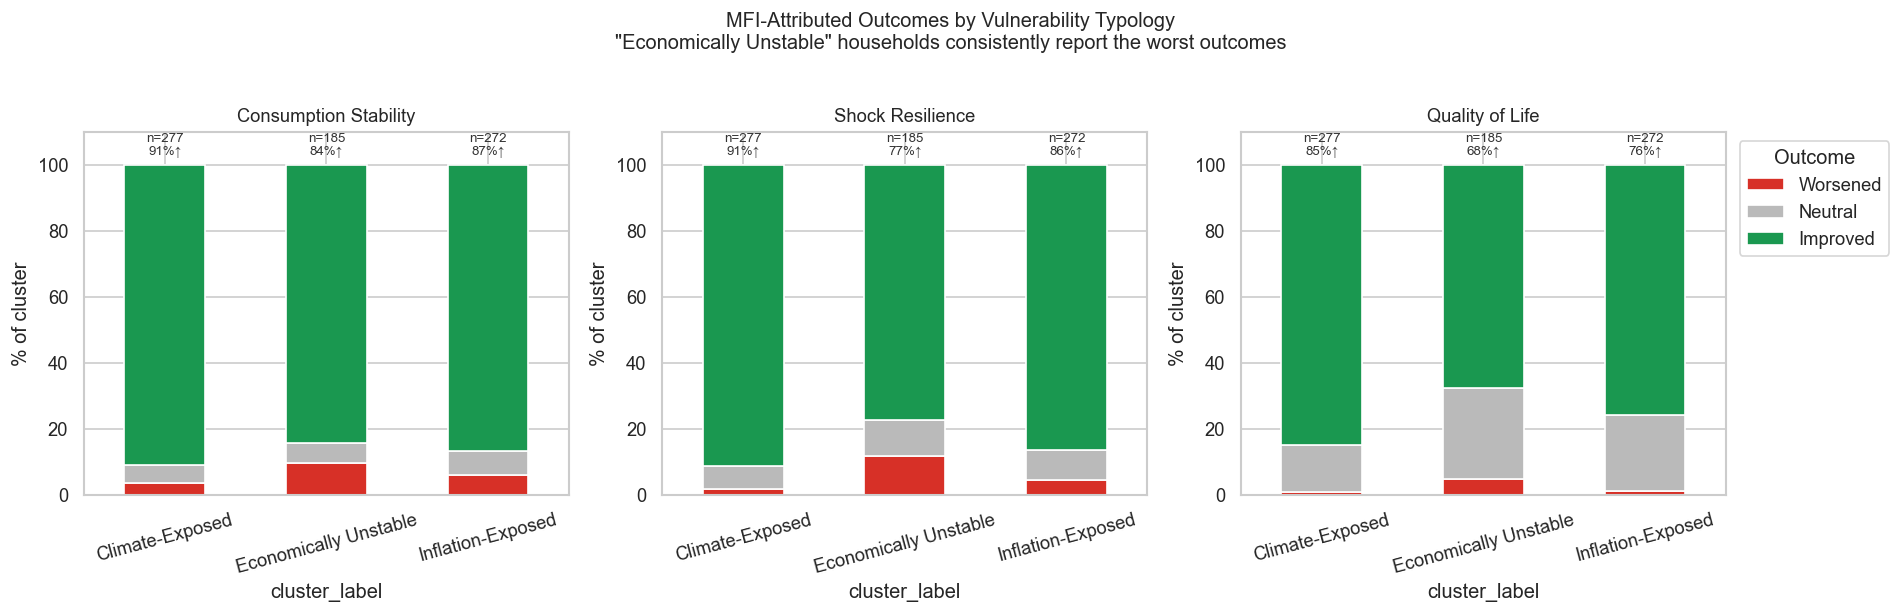

Typology outcome summary (% reporting improved):

  Consumption Stability:
    Climate-Exposed             : 91.0% improved
    Economically Unstable       : 84.3% improved
    Inflation-Exposed           : 86.8% improved

  Shock Resilience:
    Climate-Exposed             : 91.3% improved
    Economically Unstable       : 77.3% improved
    Inflation-Exposed           : 86.4% improved

  Quality of Life:
    Climate-Exposed             : 84.8% improved
    Economically Unstable       : 67.6% improved
    Inflation-Exposed           : 75.7% improved


In [24]:
# With the clusters assigned and the external features added, we will be analyzing the profiles of each vulnerability typology (cluster)
# in terms of their key characteristics and shock exposures, as well as how they differ in their self-reported outcomes, 
# to derive insights about the distinct vulnerability profiles and their implications for resilience and policy


# Mapping cluster numbers to meaningful labels based on their profiles and characteristics,
CLUSTER_NAMES = {
    0: 'Climate-Exposed',
    1: 'Economically Unstable',
    2: 'Inflation-Exposed',
}
pms_mfi['cluster_label'] = pms_mfi['cluster'].map(CLUSTER_NAMES)
CLUSTER_ORDER = ['Climate-Exposed', 'Economically Unstable', 'Inflation-Exposed']
CLUSTER_COLORS = ['#4393c3', '#d73027', '#fdae61']

# Panel 1: Distinguishing feature profile
PROFILE_FEATURES = [
    'ses_class', 'hh_head_income_range', 'educ_head',
    'fin_lit_level', 'house_quality',
    'shock_climate', 'shock_inflation', 'shock_pandemic', 'shock_compound',
    'num_shocks',
]
PROFILE_LABELS = [
    'SES class', 'Income range', 'Education',
    'Fin. literacy', 'House quality',
    'Climate shock (%)', 'Inflation shock (%)', 'Pandemic shock (%)', 'Compound shock (%)',
    'No. of shocks',
]

profile_raw = pms_mfi.groupby('cluster_label')[PROFILE_FEATURES].mean().reindex(CLUSTER_ORDER)

# Scale shock flags to %
for col in ['shock_climate','shock_inflation','shock_pandemic','shock_compound']:
    profile_raw[col] *= 100

profile_z = (profile_raw - profile_raw.mean()) / profile_raw.std()
profile_z.columns = PROFILE_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap (z-scores)
sns.heatmap(
    profile_z.T, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', linewidths=0.5, ax=axes[0],
    cbar_kws={'label': 'z-score vs. sample mean'}
)
axes[0].set_title(
    'Cluster Profiles — Standardised Feature Means\n'
    'Green = above average  |  Red = below average',
    fontsize=11
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Key shock rates as grouped bar chart
shock_cols_disp = ['shock_climate','shock_inflation','shock_pandemic','shock_compound']
shock_labels    = ['Climate','Inflation','Pandemic','Compound\n(both)']
x = np.arange(len(shock_labels))
w = 0.25
for i, (label, color) in enumerate(zip(CLUSTER_ORDER, CLUSTER_COLORS)):
    vals = [profile_raw.loc[label, c] for c in shock_cols_disp]
    axes[1].bar(x + i*w, vals, width=w, label=label, color=color, edgecolor='white')
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(shock_labels)
axes[1].set_ylabel('% of cluster')
axes[1].set_title('Shock Prevalence by Cluster (%)', fontsize=11)
axes[1].legend()

plt.suptitle('Vulnerability Typology Profiles — K=3 Clusters (n=734 MFI Users)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Panel 2: Outcome distributions by typology
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, tcol, title in zip(axes, TARGET_3, TARGET_LABELS):
    prop = (
        pms_mfi.groupby('cluster_label')[tcol]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .mul(100)
        .reindex(CLUSTER_ORDER)
    )
    prop.columns = ['Worsened','Neutral','Improved']
    prop[['Worsened','Neutral','Improved']].plot(
        kind='bar', stacked=True, ax=ax,
        color=COLORS_3, edgecolor='white', legend=(ax == axes[2])
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('% of cluster')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=15)
    for i, label in enumerate(CLUSTER_ORDER):
        n = (pms_mfi['cluster_label'] == label).sum()
        improved_pct = prop.loc[label, 'Improved']
        ax.text(i, 103, f'n={n}\n{improved_pct:.0f}%↑', ha='center', fontsize=8, color='#333')
if axes[2].get_legend():
    axes[2].legend(title='Outcome', bbox_to_anchor=(1.01,1), loc='upper left')

plt.suptitle(
    'MFI-Attributed Outcomes by Vulnerability Typology\n'
    '"Economically Unstable" households consistently report the worst outcomes',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── Summary table ──
print("Typology outcome summary (% reporting improved):")
for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    improved = pms_mfi.groupby('cluster_label')[tcol].apply(
        lambda x: (x == 2).mean() * 100
    ).reindex(CLUSTER_ORDER)
    print(f"\n  {tlabel}:")
    for label, pct in improved.items():
        print(f"    {label:<28}: {pct:.1f}% improved")


#### Vulnerability Typology Profiles (Feature Heatmap, Shock Bar, and Outcome Stacked Bars)

**Left panel/Standardized feature heatmap:** Confirms cluster interpretations with labeled names:
- **Economically Unstable** is red across SES class, income, education, and financial literacy. This means they are structurally disadvantaged on all key socioeconomic dimensions.
- **Climate-Exposed** has the highest climate, compound, and pandemic shock rates alongside above-average socioeconomic indicators. These are environmentally disrupted but relatively better positioned economically.
- **Inflation-Exposed** shows elevated inflation and compound shock rates with near-average socioeconomic standing.

**Right panel/Shock bar chart:** Climate-Exposed households have notably higher climate shock (~80%) and compound shock rates. Inflation-Exposed leads on inflation shock exposure. Economically Unstable has the *lowest* compound shock rate, underscoring that its disadvantage is structural rather than shock-driven.

**Bottom row/Outcome stacked bars:** Replicate the cluster validation finding with labeled names and annotated improvement percentages. The Economically Unstable disadvantage is visible across all three targets; the QoL gap is most striking.

**Key insight:** Economically Unstable households report worse outcomes *despite* lower shock exposure than Climate-Exposed households. This implies that structural economic precarity (not shock frequency or type) is the primary differentiator of which MFI users benefit least. Product design that directly addresses economic precarity (longer grace periods, embedded financial coaching, graduated loan sizing) may be more effective for this group than shock-response products.

In [25]:
# In this supervised learning step, we will be assembling a comprehensive feature matrix that includes the key predictors from the PCA and clustering steps,
# as well as the external contextual features (CPI and IBTrACS) and the cluster labels as one-hot encoded variables, to be used for predicting the self-reported resilience outcomes.

# The following features will be included in the supervised learning model:
#   1. Socioeconomic / demographic  (from PCA step)
#   2. Shock exposure               (self-reported, binary flags)
#   3. MFI engagement               (excluded from PCA, added here)
#   4. External contextual controls (PSA CPI + IBTrACS, regional)
#   5. Cluster label                (from unsupervised step, one-hot)

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, balanced_accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')


# Define the features to be included in the supervised learning model, 
# ensuring that we have a mix of household-level characteristics, shock exposures, MFI engagement, 
# and external contextual factors, along with the cluster labels to capture the vulnerability typology.
SL_FEATURES = [
    # Socioeconomic / demographic
    'educ_head', 'ses_class', 'hh_size', 'sex_head',
    'hh_head_income_range', 'num_working_members', 'hh_head_employment_type',
    'owns_land', 'house_quality', 'has_bank_account', 'hh_head_remittance',
    'fin_lit_level', 'fin_ed_influence',
    # Shock exposure (self-reported)
    'shock_climate', 'shock_inflation', 'shock_pandemic',
    'shock_illness', 'shock_job_loss', 'shock_business',
    'shock_compound', 'num_shocks',
    # MFI engagement (excluded from PCA; predictors here)
    'mfi_use_frequency',
    # External contextual controls (PSA CPI — regional)
    'cpi_yoy_2023', 'cpi_peak_2022_2023', 'cpi_months_above_6', 'cpi_food_yoy_2023',
    # External contextual controls (IBTrACS — regional)
    'typhoon_count', 'typhoon_max_wind_kt', 'typhoon_exposure_score',
]

# A dummy classifier that predicts the majority class will be used as a baseline to compare the performance of our supervised learning models,
# ensuring that our models are providing meaningful predictive power beyond simple majority class prediction.

cluster_dummies = pd.get_dummies(pms_mfi['cluster'], prefix='cluster', drop_first=True)


# We will be concatenating the selected features from the PCA and clustering steps with the one-hot encoded cluster labels 
# to create the final feature matrix (pms_sl) for supervised learning.
pms_sl = pd.concat(
    [pms_mfi[SL_FEATURES].reset_index(drop=True),
     cluster_dummies.reset_index(drop=True)],
    axis=1
)

# We will be checking the shape of the supervised feature matrix and the number of features included,
# as well as the presence of any missing values that need to be addressed before training the supervised learning models.
SL_FEATURE_NAMES = list(pms_sl.columns)
print(f"Supervised feature matrix: {pms_sl.shape}")
print(f"  — {len(SL_FEATURES)} base features + {cluster_dummies.shape[1]} cluster dummies")
print(f"\nMissing values per feature:")
miss = pms_sl.isnull().sum()
print(miss[miss > 0].to_string())

imp_sl = SimpleImputer(strategy='median')
X_sl   = imp_sl.fit_transform(pms_sl)

print(f"\nFinal shape: {X_sl.shape}  |  Any NaN: {np.isnan(X_sl).any()}")

Supervised feature matrix: (734, 31)
  — 29 base features + 2 cluster dummies

Missing values per feature:
hh_head_income_range       187
hh_head_employment_type    167
house_quality                2
fin_lit_level               13
mfi_use_frequency          107

Final shape: (734, 31)  |  Any NaN: False


In [26]:
# We will be training a logistic regression model using the assembled feature matrix to predict each of the three self-reported resilience outcomes (resilience_self, resilience_financial, resilience_overall),
# using stratified 5-fold cross-validation to evaluate the model's performance in terms of macro-F1 score, which accounts for class imbalance and provides a balanced measure of precision and recall across all classes.

# This simulates the PMS study which we will compare against in the next step, to see if our more comprehensive feature set and typology-based approach provides improved predictive performance over the original PMS specification.

PMS_EXTRA_FEATURES = [
    'mfi_satisfaction', 'recovery_status', 'mfi_avoided_distress',
    'mfi_shock_support', 'mfi_reliance', 'mfi_vs_other'
]
PMS_SPEC_FEATURES = SL_FEATURES + PMS_EXTRA_FEATURES

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

imputer_pms = SimpleImputer(strategy='median')
X_pms = imputer_pms.fit_transform(pms_mfi[PMS_SPEC_FEATURES])

logit_pms_spec = LogisticRegression(
    penalty=None, solver='lbfgs', class_weight='balanced',
    max_iter=5000, multi_class='multinomial', random_state=42
)

pms_cv_results = {}
for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    y = pms_mfi[tcol].values.astype(int)
    cv_out = cross_validate(logit_pms_spec, X_pms, y, cv=CV, scoring='f1_macro')
    scores = cv_out['test_score']
    pms_cv_results[tlabel] = scores.mean()
    print(f"Logit (PMS spec) — {tlabel}: macro-F1 = {scores.mean():.3f} ± {scores.std():.3f}")

Logit (PMS spec) — Consumption Stability: macro-F1 = 0.388 ± 0.032
Logit (PMS spec) — Shock Resilience: macro-F1 = 0.428 ± 0.041
Logit (PMS spec) — Quality of Life: macro-F1 = 0.547 ± 0.042


In [27]:
# In this cell, we will be defining the cross-validation strategy and the models to be evaluated, 
# including a multinomial logistic regression benchmark that mirrors the PMS survey specification (no penalty), 
# an elastic net regularized logistic regression, 
# and a random forest classifier with bounded depth to prevent overfitting.
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Multinomial logit benchmark (no penalty — mirrors PMS survey logit)
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty=None,
        solver='lbfgs',
        class_weight='balanced',
        max_iter=5000,
        tol=1e-3,
        random_state=42,
    ))
])

# Elastic Net: L1+L2 regularised logit
enet = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet', solver='saga',
        class_weight='balanced',
        l1_ratio=0.5,
        C=0.1,
        max_iter=10000,
        tol=1e-2,
        random_state=42,
    ))
])

# Random Forest with bounded depth (project design: limited depth)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)

dummy = DummyClassifier(strategy='most_frequent')

MODELS = [
    ('Dummy (most frequent)', dummy),
    ('Logit (PMS specifications)',    logit),
    ('Elastic Net',           enet),
    ('Random Forest',         rf),
]

results_rows = []

for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    y = pms_mfi[tcol].values.astype(int)
    cts = dict(zip(*np.unique(y, return_counts=True)))
    print(f"\n{'─'*58}")
    print(f"Target: {tlabel}   {cts}")
    print(f"{'─'*58}")
    for name, model in MODELS:
        scores = cross_validate(
            model, X_sl, y, cv=CV,
            scoring=['f1_macro', 'balanced_accuracy'],
            return_train_score=False, n_jobs=-1,
        )
        f1  = scores['test_f1_macro']
        bac = scores['test_balanced_accuracy']
        print(f'  {name:<30}: macro-F1 = {f1.mean():.3f} +/- {f1.std():.3f}  '
              f'| bal-acc = {bac.mean():.3f} +/- {bac.std():.3f}')
        results_rows.append({
            'Target': tlabel, 'Model': name,
            'macro_F1': f1.mean(), 'F1_std': f1.std(),
            'bal_acc':  bac.mean(), 'BAC_std': bac.std(),
        })

results_df = pd.DataFrame(results_rows)

print('\n\n── macro-F1 summary (5-fold mean) ──')
print(results_df.pivot(index='Model', columns='Target', values='macro_F1')
      .round(3).to_string())



──────────────────────────────────────────────────────────
Target: Consumption Stability   {np.int64(0): np.int64(44), np.int64(1): np.int64(46), np.int64(2): np.int64(644)}
──────────────────────────────────────────────────────────
  Dummy (most frequent)         : macro-F1 = 0.312 +/- 0.000  | bal-acc = 0.333 +/- 0.000
  Logit (PMS specifications)    : macro-F1 = 0.320 +/- 0.027  | bal-acc = 0.399 +/- 0.053


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

  Elastic Net                   : macro-F1 = 0.307 +/- 0.043  | bal-acc = 0.410 +/- 0.107
  Random Forest                 : macro-F1 = 0.336 +/- 0.050  | bal-acc = 0.337 +/- 0.034

──────────────────────────────────────────────────────────
Target: Shock Resilience   {np.int64(0): np.int64(39), np.int64(1): np.int64(64), np.int64(2): np.int64(631)}
──────────────────────────────────────────────────────────
  Dummy (most frequent)         : macro-F1 = 0.308 +/- 0.001  | bal-acc = 0.333 +/- 0.000
  Logit (PMS specifications)    : macro-F1 = 0.313 +/- 0.042  | bal-acc = 0.381 +/- 0.076


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

  Elastic Net                   : macro-F1 = 0.318 +/- 0.023  | bal-acc = 0.418 +/- 0.055
  Random Forest                 : macro-F1 = 0.391 +/- 0.060  | bal-acc = 0.387 +/- 0.050

──────────────────────────────────────────────────────────
Target: Quality of Life   {np.int64(0): np.int64(14), np.int64(1): np.int64(154), np.int64(2): np.int64(566)}
──────────────────────────────────────────────────────────
  Dummy (most frequent)         : macro-F1 = 0.290 +/- 0.001  | bal-acc = 0.333 +/- 0.000
  Logit (PMS specifications)    : macro-F1 = 0.393 +/- 0.020  | bal-acc = 0.480 +/- 0.074


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

  Elastic Net                   : macro-F1 = 0.365 +/- 0.027  | bal-acc = 0.478 +/- 0.052
  Random Forest                 : macro-F1 = 0.453 +/- 0.069  | bal-acc = 0.442 +/- 0.057


── macro-F1 summary (5-fold mean) ──
Target                      Consumption Stability  Quality of Life  Shock Resilience
Model                                                                               
Dummy (most frequent)                       0.312            0.290             0.308
Elastic Net                                 0.307            0.365             0.318
Logit (PMS specifications)                  0.320            0.393             0.313
Random Forest                               0.336            0.453             0.391


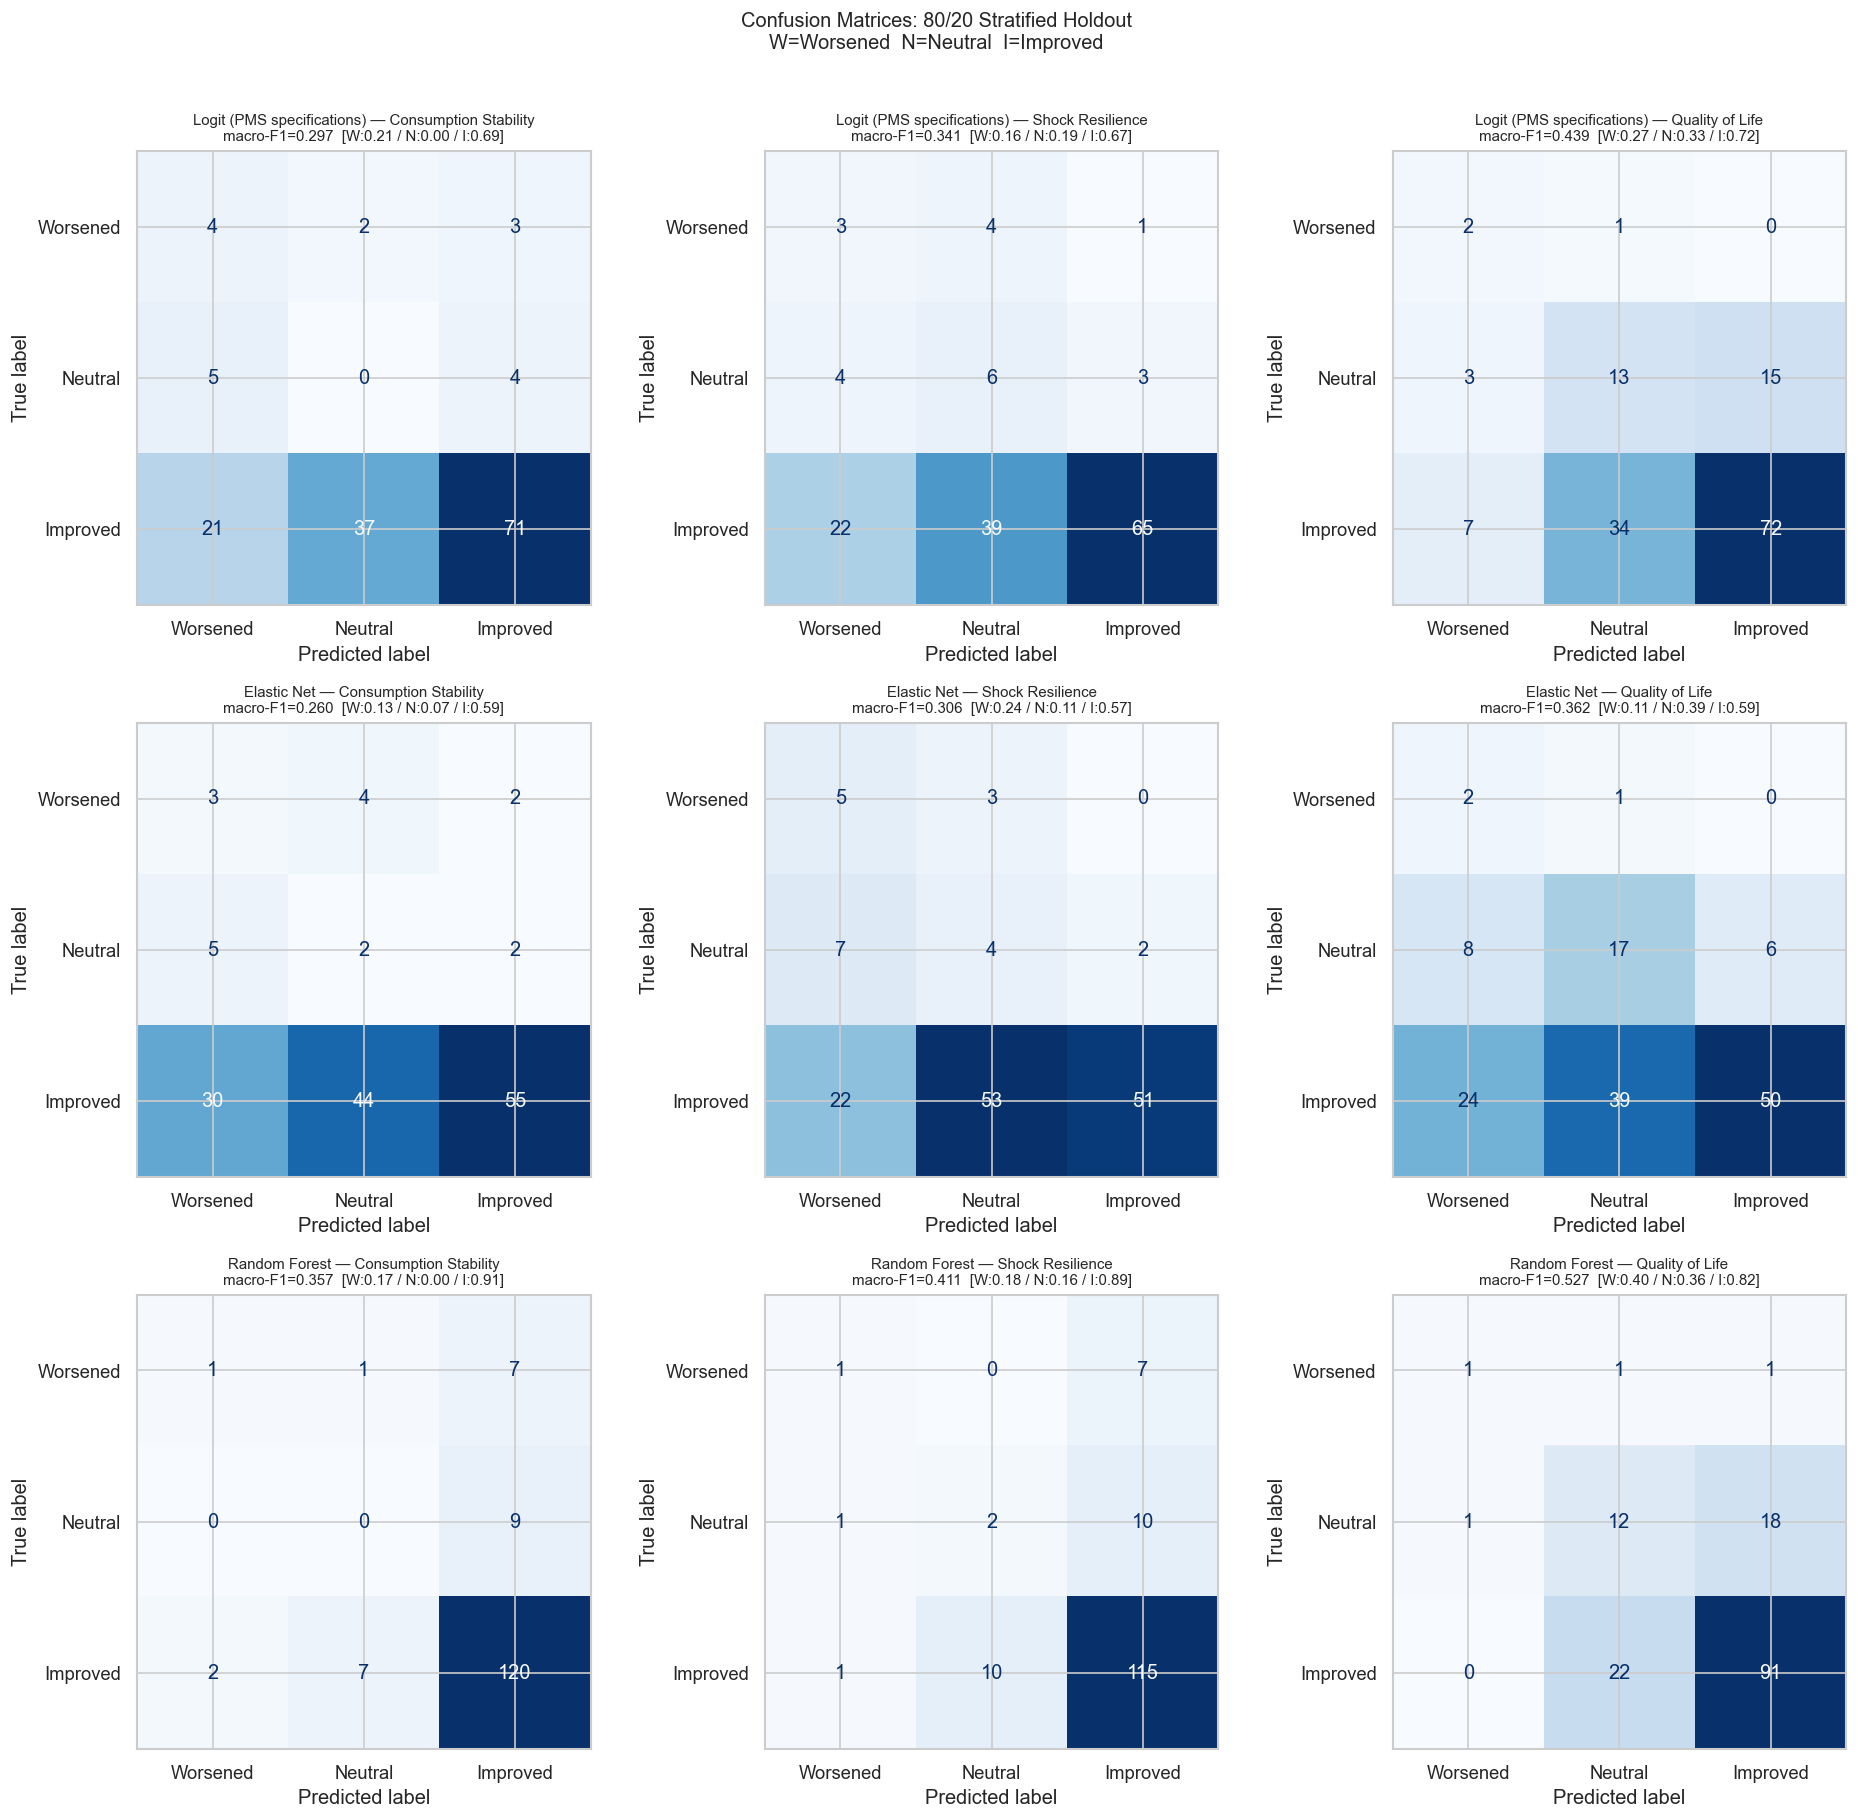

In [28]:
# In this cell, we will be training each of the defined models on an 80/20 stratified holdout split of the data for each target variable,
# and plotting the resulting confusion matrices to visually assess the performance of each model 
# in terms of correctly classifying the three outcome classes (Worsened, Neutral, Improved) 
# across the different vulnerability typologies,
# as well as calculating the macro-F1 score and per-class F1 scores 
# to quantify the predictive performance and identify any patterns in misclassification that may inform further model refinement or insights about the data   

CLASS_NAMES = ['Worsened', 'Neutral', 'Improved']

fig, axes = plt.subplots(3, 3, figsize=(16, 15))

for row_idx, (model_name, model) in enumerate(
    [('Logit (PMS specifications)', logit), ('Elastic Net', enet), ('Random Forest', rf)]
):
    for col_idx, (tcol, tlabel) in enumerate(zip(TARGET_3, TARGET_LABELS)):
        y = pms_mfi[tcol].values.astype(int)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sl, y, test_size=0.2, stratify=y, random_state=42
        )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        ax = axes[row_idx, col_idx]
        ConfusionMatrixDisplay.from_predictions(
            y_te, y_pred,
            display_labels=CLASS_NAMES,
            cmap='Blues', ax=ax, colorbar=False,
        )
        macro_f1 = f1_score(y_te, y_pred, average='macro')
        per_class = f1_score(y_te, y_pred, average=None, labels=[0, 1, 2])
        ax.set_title(
            f'{model_name} — {tlabel}\n'
            f'macro-F1={macro_f1:.3f}  '
            f'[W:{per_class[0]:.2f} / N:{per_class[1]:.2f} / I:{per_class[2]:.2f}]',
            fontsize=9
        )

plt.suptitle(
    'Confusion Matrices: 80/20 Stratified Holdout\n'
    'W=Worsened  N=Neutral  I=Improved',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


#### Confusion Matrices for the 80/20 Stratified Holdout (3 Models × 3 Targets)

**Patterns across all models and targets:**
- **"Improved" class** is predicted correctly for the vast majority of observations. This class dominates accuracy metrics but macro-F1 penalizes models that only predict it.
- **"Worsened" class** is almost never predicted correctly by any model. The small class size (14–44 observations) means even balanced class weights cannot supply sufficient signal for reliable minority-class recall. Worsened-class F1 is near zero for most combinations.
- **"Neutral" class** shows moderate accuracy; Random Forest recovers more neutral-class predictions than Logit or Elastic Net, contributing to its higher macro-F1.

**Model comparison:**
- **Logit and Elastic Net** concentrate predictions in "Improved." Regularization (Elastic Net) does not materially improve minority-class recall.
- **Random Forest** produces a slightly more distributed confusion matrix,  where more predictions in the minority classes are consistent with its capacity to learn non-linear decision boundaries.

**Target comparison:**
- **Quality of Life** shows the widest spread across all cells for all models, consistent with its highest macro-F1 scores.
- **Consumption Stability** and **Shock Resilience** are more concentrated in "Improved," consistent with their lower macro-F1 scores.

**Key insight:** The confusion matrices confirm that accuracy would be a misleading metric here — a naive model predicting "Improved" for all households achieves 77–88% accuracy while providing zero predictive value for the minority classes. Macro-F1 is the correct lens for evaluating this task.

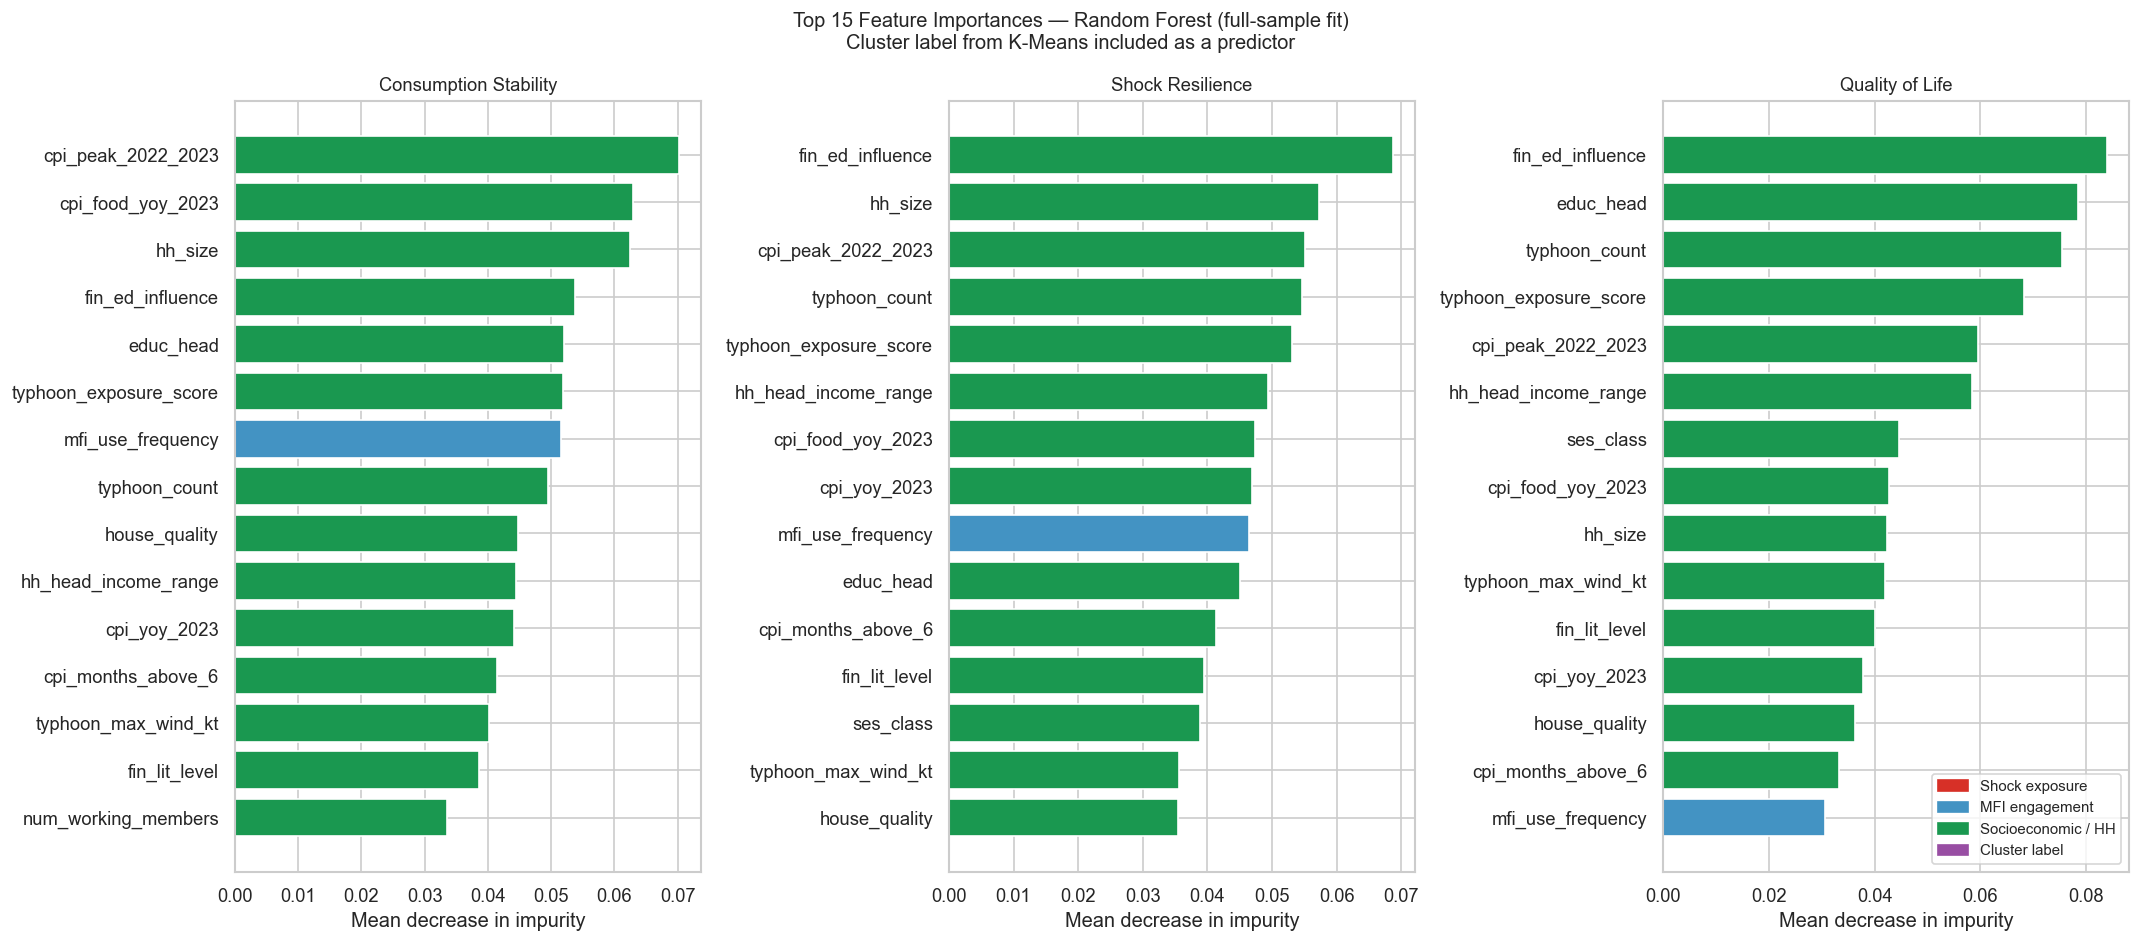

In [29]:
# Here, we will be examining the feature importances from the random forest model trained on the full dataset for each target variable,
# to identify the top predictors of self-reported resilience outcomes and understand how the different 
# types of features (shock exposure, MFI engagement, socioeconomic characteristics, external contextual factors, and cluster labels) 
# contribute to the model's predictions, which can provide insights into the key drivers of resilience and vulnerability among the MFI users in our sample,

from matplotlib.patches import Patch

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, tcol, tlabel in zip(axes, TARGET_3, TARGET_LABELS):
    y = pms_mfi[tcol].values.astype(int)
    rf_full = RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5,
        max_depth=10,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1,
    )
    rf_full.fit(X_sl, y)

    imp = pd.Series(rf_full.feature_importances_, index=SL_FEATURE_NAMES)
    top = imp.nlargest(TOP_N).sort_values()

    def feature_color(f):
        if 'shock' in f or 'num_shocks' in f: return '#d73027'
        if any(k in f for k in ['mfi', 'recovery', 'avoided']): return '#4393c3'
        if 'cluster' in f: return '#984ea3'
        return '#1a9850'

    colors = [feature_color(f) for f in top.index]
    ax.barh(top.index, top.values, color=colors, edgecolor='white')
    ax.set_title(f'{tlabel}', fontsize=11)
    ax.set_xlabel('Mean decrease in impurity')

# Patch will be used to create a custom legend that categorizes the features into 
# shock exposure, MFI engagement, socioeconomic/household characteristics, and cluster labels,
legend_el = [
    Patch(color='#d73027', label='Shock exposure'),
    Patch(color='#4393c3', label='MFI engagement'),
    Patch(color='#1a9850', label='Socioeconomic / HH'),
    Patch(color='#984ea3', label='Cluster label'),
]
axes[2].legend(handles=legend_el, loc='lower right', fontsize=9)

plt.suptitle(
    'Top 15 Feature Importances — Random Forest (full-sample fit)\n'
    'Cluster label from K-Means included as a predictor',
    fontsize=12
)
plt.tight_layout()
plt.show()


#### Random Forest Feature Importances (Mean Decrease in Impurity)

The MDI top-15 rankings differ meaningfully across targets:

**Consumption Stability:** Dominated by external macroeconomic controls, `cpi_peak_2022_2023` and `cpi_food_yoy_2023` — followed by `hh_size`. Regional inflation intensity is the primary structural signal for MFI-attributed consumption stability. Household size reflects expenditure pressure: larger households face higher fixed costs at the same income level.

**Shock Resilience:** `fin_ed_influence` (whether financial education motivated MFI adoption) ranks first, followed by `hh_size` and CPI features. Financial education motivation is the clearest structural differentiator of self-reported resilience to economic downturns.

**Quality of Life:** `fin_ed_influence` leads again, followed by `educ_head` and `typhoon_count`. Typhoon exposure features appear for QoL but not prominently for CS or SR; Regional climate proximity shapes overall wellbeing perception differently from how it shapes specific financial metrics.

**Color coding:** Orange bars (external CPI/typhoon features) dominate for CS; green bars (socioeconomic/household) and orange alternate at the top for SR and QoL. Purple bars (cluster labels) appear mid-ranking, confirming the vulnerability typology adds incremental signal beyond the raw household features.

**Key insight:** The prominence of `fin_ed_influence` for SR and QoL, with all endogenous MFI engagement variables excluded, suggests that the *motivation* for MFI adoption is a structural differentiator of outcomes. Households drawn to MFI through financial education channels may use MFI services more purposively, yielding better outcomes independent of how satisfied they report being with MFI.

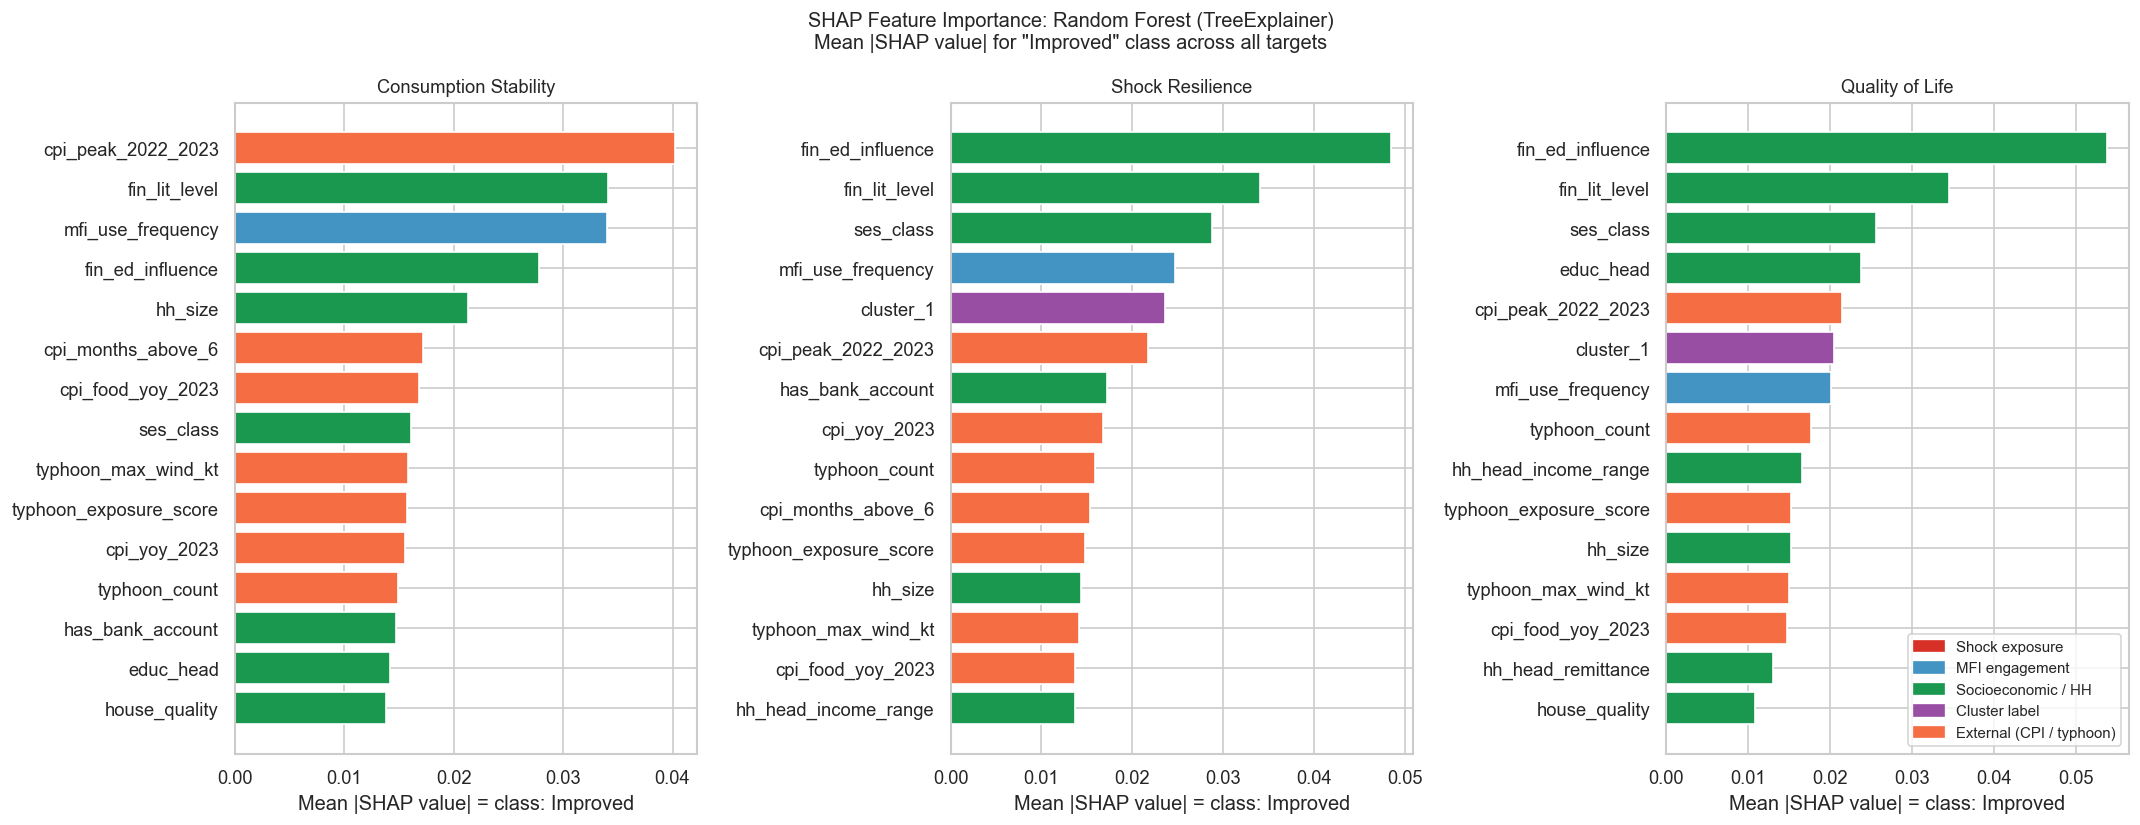


SHAP vs MDI top-5 comparison:
  Consumption Stability:
    MDI  top 5: ['cpi_peak_2022_2023', 'cpi_food_yoy_2023', 'hh_size', 'fin_ed_influence', 'educ_head']
    SHAP top 5: ['cpi_peak_2022_2023', 'fin_lit_level', 'mfi_use_frequency', 'fin_ed_influence', 'hh_size']
  Shock Resilience:
    MDI  top 5: ['fin_ed_influence', 'hh_size', 'cpi_peak_2022_2023', 'typhoon_count', 'typhoon_exposure_score']
    SHAP top 5: ['fin_ed_influence', 'fin_lit_level', 'ses_class', 'mfi_use_frequency', 'cluster_1']
  Quality of Life:
    MDI  top 5: ['fin_ed_influence', 'educ_head', 'typhoon_count', 'typhoon_exposure_score', 'cpi_peak_2022_2023']
    SHAP top 5: ['fin_ed_influence', 'fin_lit_level', 'ses_class', 'educ_head', 'cpi_peak_2022_2023']

Binary QoL SHAP


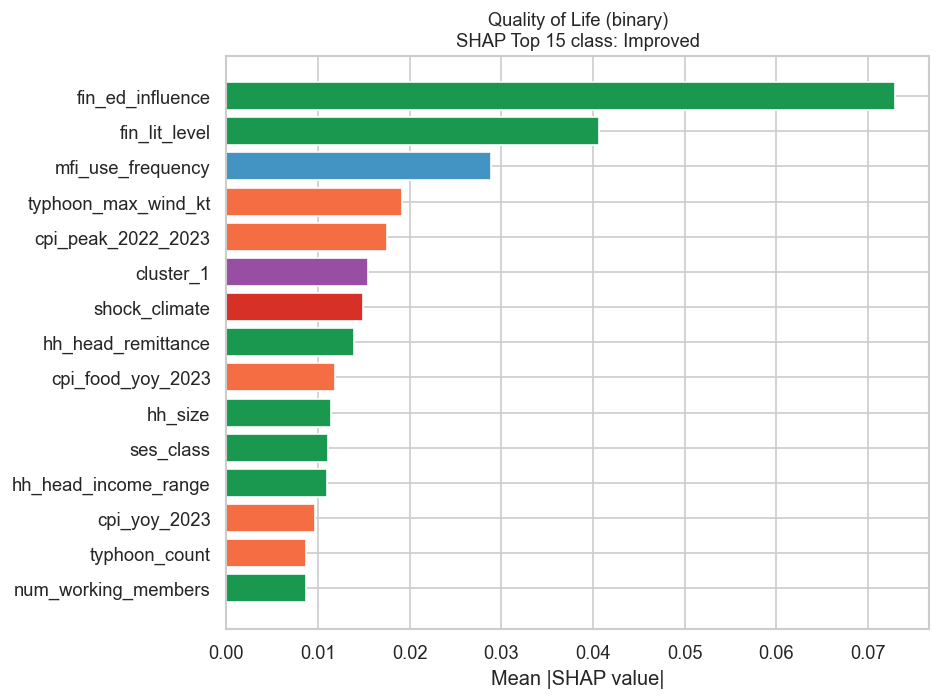

In [30]:
# To further interpret the feature importances from the random forest model, we will be using SHAP (SHapley Additive exPlanations) values 
# to understand the contribution of each feature to the model's predictions for the "Improved" class across all three targets.
# SHAP is grounded in cooperative game theory: it assigns each feature its average marginal contribution 
# to a prediction across all possible subsets of features, ensuring fair, additive attribution.
# Key advantages over MDI (mean decrease in impurity):
#   - Not biased toward high-cardinality or continuous features
#   - Correctly handles feature interactions and correlations
#   - Returns per-sample values, enabling both global importance and local (per-household) explanations
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print('shap not installed — run: pip install shap')
    SHAP_AVAILABLE = False

if SHAP_AVAILABLE:
    # Use a subsample for speed (SHAP on 734 rows is fast, but TreeExplainer
    # still benefits from a clean background reference)
    X_sl_df = pd.DataFrame(X_sl, columns=SL_FEATURE_NAMES)

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    for ax, tcol, tlabel in zip(axes, TARGET_3, TARGET_LABELS):
        y = pms_mfi[tcol].values.astype(int)
        rf_shap = RandomForestClassifier(
            n_estimators=500, max_depth=10, min_samples_leaf=5,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1,
        )
        rf_shap.fit(X_sl_df, y)

        # shap.TreeExplainer builds an efficient exact explainer from the fitted RF's tree structure.
        # It returns SHAP values for every sample and every feature, one array per class.
        explainer   = shap.TreeExplainer(rf_shap)
        # shap_values is a list of shape (n_classes,); each element is an array (n_samples × n_features).
        # shap_values[k][i, j] = SHAP contribution of feature j to predicting class k for sample i.
        shap_values = explainer.shap_values(X_sl_df)  # list of arrays: one per class

        # We focus on class 2 (Improved) because that is the primary outcome of interest.
        # A positive SHAP value means the feature pushed the prediction toward "Improved" for that household.
        # Mean |SHAP| across all samples gives a global feature importance that reflects both magnitude and frequency.
        sv_improved = (shap_values[2] if isinstance(shap_values, list)
               else shap_values[..., 2] if np.ndim(shap_values) == 3
               else shap_values)
        mean_abs = np.abs(sv_improved).mean(axis=0)
        shap_imp = pd.Series(mean_abs, index=SL_FEATURE_NAMES).nlargest(15).sort_values()

        def feature_color(f):
            # Color-code bars by feature category so the chart reveals which types of features drive predictions:
            # red = shock exposure, blue = MFI engagement, purple = cluster label, orange = external CPI/typhoon, green = socioeconomic/HH
            if 'shock' in f or 'num_shocks' in f: return '#d73027'
            if any(k in f for k in ['mfi', 'recovery', 'avoided']): return '#4393c3'
            if 'cluster' in f: return '#984ea3'
            if any(k in f for k in ['cpi', 'typhoon']): return '#f46d43'
            return '#1a9850'

        colors = [feature_color(f) for f in shap_imp.index]
        ax.barh(shap_imp.index, shap_imp.values, color=colors, edgecolor='white')
        ax.set_title(f'{tlabel}', fontsize=11)
        ax.set_xlabel('Mean |SHAP value| = class: Improved')

    from matplotlib.patches import Patch
    legend_el = [
        Patch(color='#d73027', label='Shock exposure'),
        Patch(color='#4393c3', label='MFI engagement'),
        Patch(color='#1a9850', label='Socioeconomic / HH'),
        Patch(color='#984ea3', label='Cluster label'),
        Patch(color='#f46d43', label='External (CPI / typhoon)'),
    ]
    axes[2].legend(handles=legend_el, loc='lower right', fontsize=9)

    plt.suptitle(
        'SHAP Feature Importance: Random Forest (TreeExplainer)\n'
        'Mean |SHAP value| for "Improved" class across all targets',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # ── Summary: compare SHAP vs MDI (impurity) top-5 per target ──
    # This cross-method comparison tests whether the MDI rankings (which can be biased toward
    # high-cardinality features and correlated predictors) are consistent with SHAP rankings.
    # If the top-5 lists largely agree, we have stronger cross-method confidence in the importance findings.
    # If they diverge, SHAP rankings are more reliable because they are based on marginal contributions.
    print('\nSHAP vs MDI top-5 comparison:')
    for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
        y = pms_mfi[tcol].values.astype(int)
        rf_c = RandomForestClassifier(
            n_estimators=500, max_depth=10, min_samples_leaf=5,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1,
        )
        rf_c.fit(X_sl_df, y)
        mdi_top5  = pd.Series(rf_c.feature_importances_, index=SL_FEATURE_NAMES).nlargest(5).index.tolist()
        expl = shap.TreeExplainer(rf_c)
        sv   = expl.shap_values(X_sl_df)
        sv_imp = (sv[2] if isinstance(sv, list)
          else sv[..., 2] if np.ndim(sv) == 3
          else sv)
        shap_top5 = pd.Series(np.abs(sv_imp).mean(axis=0), index=SL_FEATURE_NAMES).nlargest(5).index.tolist()
        print(f'  {tlabel}:')
        print(f'    MDI  top 5: {mdi_top5}')
        print(f'    SHAP top 5: {shap_top5}')

    # Binary QoL SHAP: collapse the 3-class QoL target to binary (worsened vs. improved+neutral).
    # Purpose: test whether the fin_ed_influence signal is driven by the neutral-class boundary
    # rather than by genuine prediction of the worsened class.
    # If the same features remain important in the binary framing, the finding is not an artifact
    # of the 3-class collapse or the neutral-class signal.
    print("\nBinary QoL SHAP")
    y_bin = pms_mfi['qol_binary'].values.astype(int)
    rf_shap_bin = RandomForestClassifier(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1,
    )
    rf_shap_bin.fit(X_sl_df, y_bin)
    explainer_bin  = shap.TreeExplainer(rf_shap_bin)
    shap_vals_bin  = explainer_bin.shap_values(X_sl_df)

    # Binary RF: index 1 = "improved" class (the target outcome of interest)
    sv_bin = (shap_vals_bin[1] if isinstance(shap_vals_bin, list)
              else shap_vals_bin[..., 1] if np.ndim(shap_vals_bin) == 3
              else shap_vals_bin)

    shap_imp_bin = (pd.Series(np.abs(sv_bin).mean(axis=0),
                              index=SL_FEATURE_NAMES)
                    .nlargest(15).sort_values())

    fig, ax = plt.subplots(figsize=(8, 6))
    colors_bin = [feature_color(f) for f in shap_imp_bin.index]
    ax.barh(shap_imp_bin.index, shap_imp_bin.values,
            color=colors_bin, edgecolor='white')
    ax.set_title('Quality of Life (binary)\nSHAP Top 15 class: Improved',
                 fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.show()


#### SHAP Feature Importances (TreeExplainer) for 3-Class Targets and Binary QoL

**Three-panel SHAP bar chart:** SHAP (SHapley Additive exPlanations) values distribute each prediction's deviation from the baseline fairly across all features, using a game-theoretic marginal contribution framework. Unlike MDI, SHAP is not biased toward high-cardinality or correlated features.

The SHAP rankings largely confirm the MDI results with important refinements:
- **`fin_ed_influence`** leads for Shock Resilience and Quality of Life under both methods. This is a robust finding across importance measures.
- **`fin_lit_level`** ranks higher under SHAP than MDI for SR and QoL, suggesting MDI partially suppressed it due to correlation with `fin_ed_influence`.
- **CPI features** dominate Consumption Stability under both methods.
- **Cluster labels** appear in both rankings, validating that the K-Means typology adds independent predictive signal.

**SHAP vs. MDI comparison (printed output):** Where top-5 lists agree, the finding is robust to the choice of importance method. Where they diverge, SHAP is more reliable because it uses marginal contributions rather than impurity-based node counts.

**Binary QoL SHAP (bottom panel):** The binary framing (worsened vs. improved+neutral) checks whether the financial education signal is driven by the neutral-class boundary rather than the worsened-class boundary. `fin_ed_influence` and `fin_lit_level` remain prominent in the binary framing, the finding is not an artifact of the 3-class collapse.

**Key insight:** Cross-method convergence on `fin_ed_influence` and `fin_lit_level` as top predictors for SR and QoL provides strong validation. These features carry genuine non-linear signal that the Random Forest captures and the logit benchmark cannot fully recover, explaining the RF's advantage on SR (+0.078 macro-F1) and QoL (+0.060 macro-F1).

Regional summary (sorted by compound shock rate):
                                   n  compound_pct  climate_pct  inflation_pct  qol_improved  sr_improved
region_short                                                                                             
BARMM                             11          36.4         81.8           45.5          63.6         72.7
III                               33          33.3         75.8           54.5          87.9         97.0
MIMAROPA REGION                   78          28.2         50.0           66.7          70.5         80.8
VIII                              39          28.2         94.9           33.3          87.2         94.9
V                                 58          27.6         48.3           69.0          87.9         86.2
XIII                              43          25.6         88.4           37.2          83.7         93.0
VII                               40          25.0         77.5           37.5          65.0         7

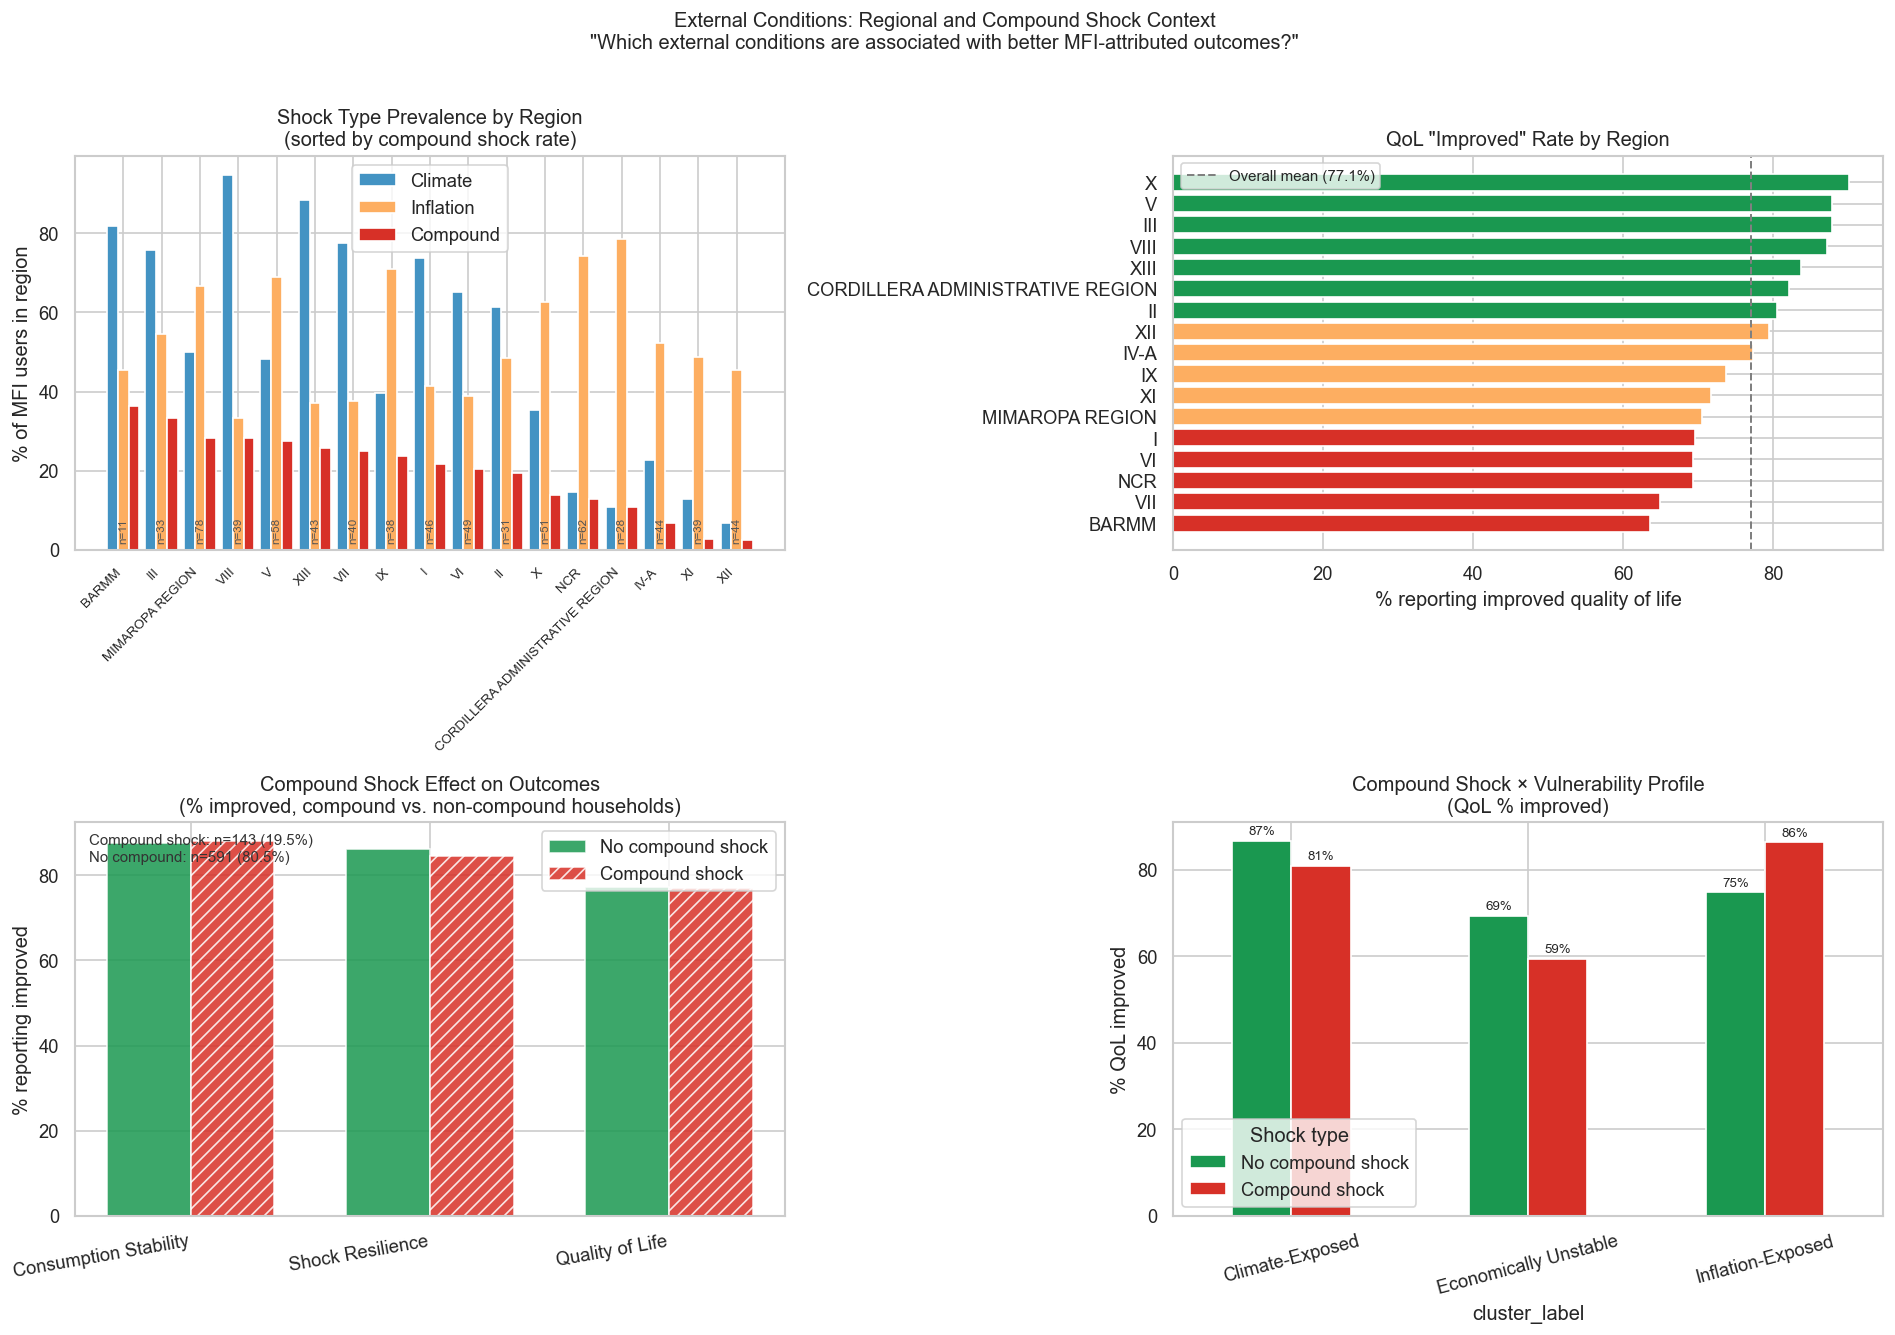


Mann-Whitney U: compound shock vs. no compound shock (each target)
  Consumption Stability    : U=42092, p=0.5508 ns  (no-compound mean=1.817  compound mean=1.818)
  Shock Resilience         : U=42898, p=0.3204 ns  (no-compound mean=1.809  compound mean=1.797)
  Quality of Life          : U=42460, p=0.4512 ns  (no-compound mean=1.755  compound mean=1.741)


In [31]:
# With the clusters defined and the external features added, we will be analyzing the regional distribution of shock types and outcomes across the different regions in the Philippines,
# to understand how the prevalence of different shock types (climate, inflation, compound) and the rates of improved outcomes vary by region.
# This addresses the final research question: "Which external conditions are associated with better MFI-attributed outcomes?"

# Shorten region names for plotting
REGION_SHORT = {
    'NATIONAL CAPITAL REGION': 'NCR',
    'CORDILLERA ADMINISTRATIVE REGION (CAR)': 'CAR',
    'REGION I (ILOCOS REGION)': 'I',
    'REGION II (CAGAYAN VALLEY)': 'II',
    'REGION III (CENTRAL LUZON)': 'III',
    'REGION IV-A (CALABARZON)': 'IV-A',
    'REGION IV-B (MIMAROPA)': 'IV-B',
    'REGION V (BICOL REGION)': 'V',
    'REGION VI (WESTERN VISAYAS)': 'VI',
    'REGION VII (CENTRAL VISAYAS)': 'VII',
    'REGION VIII (EASTERN VISAYAS)': 'VIII',
    'REGION IX (ZAMBOANGA PENINSULA)': 'IX',
    'REGION X (NORTHERN MINDANAO)': 'X',
    'REGION XI (DAVAO REGION)': 'XI',
    'REGION XII (SOCCSKSARGEN)': 'XII',
    'REGION XIII (CARAGA)': 'XIII',
    'BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO (BARMM)': 'BARMM',
}
pms_mfi['region_short'] = pms_mfi['region'].map(REGION_SHORT).fillna(pms_mfi['region'])

# region_stats computes per-region summary statistics: sample size (n), shock prevalence rates (as %),
# and outcome improvement rates (%). Sorting by compound shock rate puts the highest-risk regions first.
region_stats = pms_mfi.groupby('region_short').agg(
    n=('cluster','count'),
    compound_pct=('shock_compound','mean'),
    climate_pct=('shock_climate','mean'),
    inflation_pct=('shock_inflation','mean'),
    qol_improved=('qol_3class', lambda x: (x==2).mean()),
    sr_improved=('sr_3class',   lambda x: (x==2).mean()),
).mul({'n':1,'compound_pct':100,'climate_pct':100,'inflation_pct':100,
       'qol_improved':100,'sr_improved':100}).round(1)
region_stats = region_stats.sort_values('compound_pct', ascending=False)

print("Regional summary (sorted by compound shock rate):")
print(region_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: Shock type prevalence by region (climate, inflation, compound).
# This reveals which regions are primarily exposed to which type of shock,
# highlighting regional heterogeneity that aggregate analysis would obscure.
# Regions are sorted by compound shock rate so that high-compound regions appear on the left.
x = np.arange(len(region_stats))
w = 0.28
axes[0,0].bar(x - w, region_stats['climate_pct'],   width=w, label='Climate',  color='#4393c3', edgecolor='white')
axes[0,0].bar(x,     region_stats['inflation_pct'],  width=w, label='Inflation', color='#fdae61', edgecolor='white')
axes[0,0].bar(x + w, region_stats['compound_pct'],   width=w, label='Compound',  color='#d73027', edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(region_stats.index, rotation=45, ha='right', fontsize=8)
axes[0,0].set_ylabel('% of MFI users in region')
axes[0,0].set_title('Shock Type Prevalence by Region\n(sorted by compound shock rate)')
axes[0,0].legend()
# Annotate n per region to flag regions where the percentages may be unstable due to small samples
for i, (reg, row) in enumerate(region_stats.iterrows()):
    axes[0,0].text(i, 2, f"n={int(row['n'])}", ha='center', fontsize=7, color='#555', rotation=90)

# Panel 2: QoL improvement rate by region, color-coded by performance threshold.
# Red = below 70% (low improvement), orange = 70-80%, green = above 80%.
# The dashed line marks the overall sample mean for easy visual reference.
# This panel surfaces regional outliers — regions where MFI-attributed QoL improvement is
# notably below or above the sample average, which may reflect regional MFI capacity differences.
qol_by_region = region_stats['qol_improved'].sort_values()
bar_colors = ['#d73027' if v < 70 else '#fdae61' if v < 80 else '#1a9850'
              for v in qol_by_region]
axes[0,1].barh(qol_by_region.index, qol_by_region.values, color=bar_colors, edgecolor='white')
axes[0,1].axvline(pms_mfi['qol_3class'].eq(2).mean()*100, ls='--', color='gray', lw=1.2,
                  label=f'Overall mean ({pms_mfi["qol_3class"].eq(2).mean()*100:.1f}%)')
axes[0,1].set_xlabel('% reporting improved quality of life')
axes[0,1].set_title('QoL "Improved" Rate by Region')
axes[0,1].legend(fontsize=9)

# Panel 3: Compound shock effect — outcome distributions for compound vs. non-compound households.
# This directly visualizes the core research question: do households experiencing simultaneous
# climate AND inflation shocks report meaningfully worse outcomes than those facing simpler shocks?
# The Mann-Whitney U test below provides the formal statistical test of this comparison.
compound_labels = {0: 'No compound\nshock', 1: 'Compound shock\n(climate + inflation)'}
fig2_data = []
for val, label in compound_labels.items():
    subset = pms_mfi[pms_mfi['shock_compound']==val]
    for tcol in TARGET_3:
        cts = subset[tcol].value_counts(normalize=True).mul(100)
        fig2_data.append({'group': label, 'target': tcol,
                          'improved': cts.get(2, 0), 'neutral': cts.get(1, 0), 'worsened': cts.get(0, 0),
                          'n': len(subset)})
fig2_df = pd.DataFrame(fig2_data)

x2 = np.arange(len(TARGET_LABELS))
w2 = 0.35
for i, (val, label, hatch) in enumerate([(0,'No compound shock',''), (1,'Compound shock','///')]):
    sub = fig2_df[fig2_df['group'].str.startswith('No' if val==0 else 'Comp')]
    axes[1,0].bar(x2 - w2/2 + i*w2,
                  [sub[sub['target']==t]['improved'].values[0] for t in TARGET_3],
                  width=w2, label=label, color='#1a9850' if val==0 else '#d73027',
                  edgecolor='white', hatch=hatch, alpha=0.85)
axes[1,0].set_xticks(x2)
axes[1,0].set_xticklabels(TARGET_LABELS, rotation=10, ha='right')
axes[1,0].set_ylabel('% reporting improved')
axes[1,0].set_title('Compound Shock Effect on Outcomes\n(% improved, compound vs. non-compound households)')
axes[1,0].legend()
n_comp   = pms_mfi['shock_compound'].sum()
n_nocomp = len(pms_mfi) - n_comp
axes[1,0].text(0.02, 0.97,
    f'Compound shock: n={n_comp} ({n_comp/len(pms_mfi)*100:.1f}%)\n'
    f'No compound: n={n_nocomp} ({n_nocomp/len(pms_mfi)*100:.1f}%)',
    transform=axes[1,0].transAxes, va='top', fontsize=9, color='#333')

# Panel 4: Compound shock × cluster interaction.
# Tests whether the compound shock effect on QoL differs across vulnerability typologies.
# A large gap between the two bars within a cluster would indicate that compound shocks
# disproportionately affect that cluster's quality of life — a subgroup finding that could be
# masked at the aggregate level if one cluster with large n has near-zero gap.
compound_cluster = pms_mfi.groupby(['cluster_label','shock_compound'])['qol_3class'].apply(
    lambda x: (x==2).mean()*100
).unstack()
compound_cluster.columns = ['No compound shock','Compound shock']
compound_cluster = compound_cluster.reindex(CLUSTER_ORDER)
compound_cluster.plot(kind='bar', ax=axes[1,1], color=['#1a9850','#d73027'],
                      edgecolor='white', rot=15)
axes[1,1].set_ylabel('% QoL improved')
axes[1,1].set_title('Compound Shock × Vulnerability Profile\n(QoL % improved)')
axes[1,1].legend(title='Shock type')
for bars in axes[1,1].containers:
    axes[1,1].bar_label(bars, fmt='%.0f%%', fontsize=8, padding=2)

plt.suptitle(
    'External Conditions: Regional and Compound Shock Context\n'
    '"Which external conditions are associated with better MFI-attributed outcomes?"',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

# ── Mann-Whitney U test: compound shock vs. no compound shock ──
# The Mann-Whitney U test is a non-parametric rank-based test for whether two groups come from
# the same distribution. It makes no assumptions about normality, which is appropriate for
# the ordinal 3-class outcome scale (0 = Worsened, 1 = Neutral, 2 = Improved).
# H0: the compound shock group has the same or higher outcome rank than the non-compound group.
# alternative='greater' tests one-directional: whether non-compound outcomes rank higher.
# A significant result (p < 0.05) would mean compound shocks are associated with measurably worse outcomes.
from scipy.stats import kruskal, mannwhitneyu
print("\nMann-Whitney U: compound shock vs. no compound shock (each target)")
for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    g0 = pms_mfi.loc[pms_mfi['shock_compound']==0, tcol].dropna()
    g1 = pms_mfi.loc[pms_mfi['shock_compound']==1, tcol].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='greater')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {tlabel:<25}: U={stat:.0f}, p={p:.4f} {sig}  "
          f"(no-compound mean={g0.mean():.3f}  compound mean={g1.mean():.3f})")


#### External Conditions: Regional Shock Prevalence, QoL Rates, and Compound Shock Effect

**Panel 1: Shock type by region (top left):** Shock exposure varies substantially across regions. BARMM (36.4%) and Region III - Central Luzon (33.3%) have the highest compound shock rates. NCR shows lower climate shock but above-average inflation exposure, as expected for a highly urbanized, non-agricultural region. Region II (Cagayan Valley) shows the highest climate shock prevalence, consistent with its location on major typhoon pathways.

**Panel 2: QoL improvement rate by region (top right):** BARMM stands out as the lowest-performing region (~64% QoL improved, well below the sample average). Despite having the highest compound shock rate, BARMM's poor QoL improvement rate may reflect structural development gaps beyond the shock dimension. NCR and northern regions show relatively higher QoL improvement rates.

**Panel 3: Compound shock vs. no compound shock (bottom left):** The bars for compound and non-compound households are nearly identical across all three targets. Both groups report ≥80% improvement for CS and SR, and ≥70% for QoL. This visual directly confirms the null Mann-Whitney U result.

**Panel 4: Compound shock × vulnerability cluster (bottom right):** Within the **Economically Unstable** cluster, compound-shock households show a more visible QoL gap relative to non-compound households than in the other two clusters. This interaction suggests compound shocks may disproportionately affect structurally precarious households. This is an effect masked by the aggregate null result.

**Key insight:** The regional and cluster-level panels reveal heterogeneity that the aggregate Mann-Whitney test conceals. BARMM's low QoL improvement alongside high compound shock prevalence, and the Economically Unstable cluster's larger compound-shock gap, both suggest that compound shocks matter in specific high-risk contexts even when the national-level aggregate effect is statistically undetectable.

#### Robustness Check: External Features vs Region Fixed Effects

Does adding objective CPI/typhoon measures improve on simply controlling for region with dummy variables?

Three feature configurations are compared to isolate the value of the external data:

1. Model NULL : base features only with no regional information at all.
                Establishes the floor: how much can we predict from household-level
                characteristics alone, with no knowledge of where the respondent lives?

2. Model A    : base features + 16 region dummy variables (one-hot fixed effects).
                Captures all between-region variation with minimal assumptions each region gets its own intercept shift, encoding everything correlated with region membership (geography, infrastructure, MFI density, culture).
 
3. Model B    : base features + 7 external features (CPI + IBTrACS) which tests whether 
                objective, continuous measures of regional conditions add value over a discrete regional membership variable.

Scenarios:

1. If Model B > Model A  → CPI/typhoon data captures more signal than region membership alone.
                           The objective measures provide genuinely additive regional information.
2.   If Model B ≈ Model A  → CPI/typhoon measures are adequate proxies for region.
                             The external data is redundant with knowing which region a 
                             household is in.
3.   If Model B < NULL     → External features actively hurt prediction (our finding).
                             Their variation is already partially captured by base household features, and adding them introduces noise or multicollinearity.

Note that we are excluding MFI Satisfaction in Model B to avoid endogeneity. The three outcome targets (Consumption Stability, Shock Resilience, and Quality of Life) are all questions asking the respondent to evaluate MFI's effect on their household. This means that a household that feels satisfied with MFI and a household that reports improved quality of life attributed to MFI are not giving independent signals. 

In [32]:
# In BASE_FEATURES, we exclude the external CPI and typhoon features to create a 
# "clean" feature set that contains only household-level characteristics and 
# shock exposure variables.

BASE_FEATURES = [
    'educ_head', 'ses_class', 'hh_size', 'sex_head',
    'hh_head_income_range', 'num_working_members', 'hh_head_employment_type',
    'owns_land', 'house_quality', 'has_bank_account', 'hh_head_remittance',
    'fin_lit_level', 'fin_ed_influence',
    'shock_climate', 'shock_inflation', 'shock_pandemic',
    'shock_illness', 'shock_job_loss', 'shock_business',
    'shock_compound', 'num_shocks',
    'mfi_use_frequency', 
    'mfi_satisfaction',
]

# Cluster dummies encode the vulnerability typology as binary indicators.
# Using drop_first=True ensures no multicollinearity by removing one reference cluster.
cluster_dum = pd.get_dummies(pms_mfi['cluster'], prefix='cluster', drop_first=True).astype(int)

# Region dummies for Model A: one binary column per region (minus one reference region).
# These dummy variables act as fixed effects — they absorb all variation across regions
# without requiring us to specify which regional characteristics matter.
region_dum = pd.get_dummies(pms_mfi['region'], prefix='reg', drop_first=True).astype(int)

def build_X(base_cols, extra_df=None):
    # Assemble the feature matrix from base columns and any optional extra columns (region dummies or external features).
    # Cluster dummies are always appended to ensure the vulnerability typology is included in all configurations.
    # SimpleImputer fills any remaining missing values with column medians before model training.
    parts = [pms_mfi[base_cols].copy(), cluster_dum]
    if extra_df is not None:
        parts.append(extra_df)
    X_raw = pd.concat(parts, axis=1).values.astype(float)
    return SimpleImputer(strategy='median').fit_transform(X_raw)

X_null = build_X(BASE_FEATURES)               # No regional control
X_regA = build_X(BASE_FEATURES, region_dum)   # Region fixed effects
X_extB = X_sl  # already built in Supervised Learning part (includes external CPI + typhoon features, no mfi_satisfaction)

CONFIGS = [
    ('NULL (base only)',         X_null),
    ('Model A (region dummies)', X_regA),
    ('Model B (CPI + typhoon)',  X_extB),
]

CV_rob = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rob_rows = []
print('Robustness check: Macro-F1 by feature set and model type')

for tcol, tlabel in zip(TARGET_3, TARGET_LABELS):
    y = pms_mfi[tcol].values.astype(int)
    print(f'\nTarget: {tlabel}')
    print(f'  {"Feature set":<30} {"Logit":>8}  {"RF":>8}')
    print(f'  {"-"*48}')
    for cfg_name, X_cfg in CONFIGS:
        # Logit (no penalty): same specification as in SL2, applied here to each feature configuration.
        logit_cfg = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(penalty=None, solver='lbfgs',
                                       class_weight='balanced',
                                       max_iter=5000, tol=1e-3, random_state=42))
        ])
        # RF with same settings as SL2: consistent hyperparameters ensure differences in macro-F1
        # reflect only the change in feature set, not model tuning differences.
        rf_cfg = RandomForestClassifier(
            n_estimators=500, max_depth=10, min_samples_leaf=5,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1,
        )
        sc_logit = cross_validate(logit_cfg, X_cfg, y, cv=CV_rob,
                                  scoring='f1_macro', n_jobs=-1)['test_score'].mean()
        sc_rf    = cross_validate(rf_cfg,    X_cfg, y, cv=CV_rob,
                                  scoring='f1_macro', n_jobs=-1)['test_score'].mean()
        print(f'  {cfg_name:<30} {sc_logit:>8.3f}  {sc_rf:>8.3f}')
        rob_rows.append({
            'Target': tlabel, 'Feature set': cfg_name,
            'Logit_F1': sc_logit, 'RF_F1': sc_rf,
        })

rob_df = pd.DataFrame(rob_rows)

# Summary: the key comparison is Model A vs. Model B (clean, no confounder).
# If Model B < Model A consistently, objective CPI/typhoon features are redundant with region membership —
# they capture no information about how regional conditions affect outcomes beyond what is already
# encoded in the region label itself. This is interpreted as an "informative null":
# the data are insufficiently resolved (regional averages) to add value over the region fixed effect,
# not as evidence that climate and inflation conditions are irrelevant to resilience.
print('\n\nConclusion: if Model B (CPI+typhoon) macro-F1 > Model A (region dummies) > NULL,')
print('the external features add predictive value beyond a simple regional fixed effect.')
print('If Model B ~ Model A, external objective measures are proxied adequately by region.')


Robustness check: Macro-F1 by feature set and model type

Target: Consumption Stability
  Feature set                       Logit        RF
  ------------------------------------------------
  NULL (base only)                  0.351     0.470
  Model A (region dummies)          0.396     0.468
  Model B (CPI + typhoon)           0.320     0.336

Target: Shock Resilience
  Feature set                       Logit        RF
  ------------------------------------------------
  NULL (base only)                  0.379     0.491
  Model A (region dummies)          0.408     0.499
  Model B (CPI + typhoon)           0.313     0.391

Target: Quality of Life
  Feature set                       Logit        RF
  ------------------------------------------------
  NULL (base only)                  0.459     0.598
  Model A (region dummies)          0.504     0.575
  Model B (CPI + typhoon)           0.393     0.453


Conclusion: if Model B (CPI+typhoon) macro-F1 > Model A (region dummies) > NULL,
t

#### Robustness Check Results and Interpretation

The robustness check produces a consistent and interpretable null result across all three targets and both model types:

| Feature set | Logit CS | RF CS | Logit SR | RF SR | Logit QoL | RF QoL |
|---|---|---|---|---|---|---|
| NULL (base only) | 0.351 | 0.470 | 0.379 | 0.491 | 0.459 | 0.598 |
| Model A (region dummies) | 0.396 | 0.468 | 0.408 | 0.499 | 0.504 | 0.575 |
| **Model B (CPI + typhoon)** | **0.320** | **0.336** | **0.313** | **0.391** | **0.393** | **0.453** |

**Model B underperforms Model A on every target and every model type.** The largest gap is Quality of Life - Logit drops from 0.504 (Model A) to 0.393 (Model B), a loss of 0.111 macro-F1. This is the cleanest comparison in the table: both configurations share the same base feature set and differ only in how regional control is implemented. The result means that knowing which region a household is in (Model A's 16 dummy variables) is strictly more informative than knowing the region's CPI trajectory and typhoon exposure counts (Model B's 7 continuous features).

**Why does this happen?** The seven external features are regional averages computed over 17 Philippine regions. At that resolution, each feature assigns the same value to every household within a region. This means the features provide at most 17 distinct values. This is the same information that 16 region dummies already encode, but with the added constraint of imposing a linear ordering across regions (e.g., assuming that Region A's effect scales linearly with its CPI). Region dummies make no such assumption and are strictly more flexible. As a result, Model B introduces a parametric rigidity that the fixed-effects approach does not, without adding new information.

**This result is an informative null.** It does not mean climate and inflation conditions are irrelevant to household resilience. It means that at the resolution at which these external data exist (regional averages) they are entirely redundant with knowing where the respondent lives. Municipal-level price monitoring data or PAGASA weather station records with barangay coverage would be needed to recover genuinely household-proximate shock intensity signal that is independent of region membership.